# Notebook 06: Model Explainability & Interpretation
##### Football Match Prediction 
##### Student Name: Vishal Chaudhary
##### Student Number: X23332794

### 1. SETUP & IMPORTS

In [1]:
pip install shap lime graphviz


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### IMPORT REQUIRED LIBRARIES

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import lime
import shap
import graphviz
import warnings
warnings.filterwarnings('ignore')

import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Model Explainability and Interpretability Analysis")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model Explainability and Interpretability Analysis
Analysis Date: 2025-11-14 13:12:28



### 2. DATA LOADING 

In [3]:
# Define paths
DATA_RAW_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/raw')
PROCESSED_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/processed')
FEATURES_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/features')
RESULTS_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results')
FIGURES_PATH = RESULTS_PATH / 'figures'
TABLES_PATH = RESULTS_PATH / 'tables'
EXPLAIN_PATH = RESULTS_PATH / 'model_explainability'
MODEL_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models')

df = pd.read_csv(FEATURES_PATH/'df_merged_complete_v2.csv')


FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Training data loaded: {df.shape}")


Training data loaded: (18894, 219)


In [4]:

features = [
    'h2h_total_matches', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'h2h_home_win_pct',
    'h2h_draw_pct', 'h2h_away_win_pct', 'h2h_avg_home_goals', 'h2h_avg_away_goals', 'h2h_avg_total_goals',
    'h2h_btts_pct', 'h2h_over_2_5_pct', 'h2h_last_5_home_wins', 'h2h_last_5_draws', 'h2h_last_5_away_wins',
    'h2h_days_since_last_meeting', 'avg_team_rating', 'total_points', 'total_goals_for', 'total_goals_against',
    'total_clean_sheets', 'away_avg_team_rating', 'away_total_points', 'away_total_goals_for',
    'away_total_goals_against', 'away_total_clean_sheets', 'h2h_rating_diff', 'h2h_points_diff',
    'h2h_injury_diff', 'home_rating_rank_ratio', 'away_rating_rank_ratio', 'home_points_per_game',
    'away_points_per_game', 'h2h_last_5_home_win_pct', 'h2h_last_5_draw_pct', 'h2h_last_5_away_win_pct',
    'h2h_goal_diff', 'home_avg_goals_last_5', 'home_avg_shots_last_5', 'home_avg_points_last_5',
    'away_avg_goals_last_5', 'away_avg_shots_last_5', 'away_avg_points_last_5', 'home_injury_ratio',
    'away_injury_ratio', 'home_team_experience', 'away_team_experience', 'home_formation_defenders',
    'away_formation_defenders', 'home_num_top_players', 'away_num_top_players', 'home_games_played',
    'away_games_played', 'home_draws', 'away_draws', 'home_loses', 'away_loses', 'home_goals_per_game',
    'away_goals_per_game', 'home_goals_conceded_per_game', 'away_goals_conceded_per_game',
    'goal_diff_home', 'goal_diff_away', 'goal_diff_difference', 'home_goals_conceded_L5',
    'away_goals_conceded_L5', 'form_difference', 'home_rolling_shots_on_goal', 'away_rolling_shots_on_goal',
    'shots_on_goal_diff', 'home_rolling_total_shots', 'away_rolling_total_shots', 'total_shots_diff',
    'home_rolling_corners', 'away_rolling_corners', 'corners_diff', 'home_rolling_possession',
    'away_rolling_possession', 'possession_diff', 'home_rolling_passes_accurate', 'away_rolling_passes_accurate',
    'home_rolling_pass_accuracy', 'away_rolling_pass_accuracy', 'pass_accuracy_diff', 'home_shot_efficiency',
    'away_shot_efficiency', 'shot_efficiency_diff', 'home_days_since_last', 'away_days_since_last',
    'days_rest_difference', 'table_proximity', 'is_close_match', 'league_home_advantage', 'league_avg_goals',
    'competitive_balance', 'rank_balance', 'form_balance', 'overall_balance', 'both_defensive',
    'defensive_sum', 'combined_attack', 'low_scoring_likelihood', 'home_draw_tendency', 'away_draw_tendency',
    'combined_draw_tendency', 'dominance_score'
]
target = 'target'

missing = [c for c in features if c not in df.columns]
if missing:
    raise RuntimeError(f"The following features are missing from df: {missing}")

X = df[features].select_dtypes(include=[np.number]).copy()
dropped_from_numeric = set(features) - set(X.columns.tolist())
if dropped_from_numeric:
    print(f"Warning: these provided features were not numeric and will be ignored: {sorted(list(dropped_from_numeric))}")

y = df[target].copy()
if y.isna().any():
    mask = y.notna()
    X = X.loc[mask, :]
    y = y.loc[mask]
    print("Dropped rows with missing target.")

print("X shape:", X.shape, "y distribution:\n", y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/test sizes:", X_train.shape, X_test.shape)

X shape: (18894, 106) y distribution:
 target
0   0.4453
2   0.3135
1   0.2412
Name: proportion, dtype: float64
Train/test sizes: (15115, 106) (3779, 106)


In [5]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [7]:
tuned_models = {}
for model_name in ['LogisticRegression', 'RandomForest', 'MLPClassifier', 'XGBoost', 'LightGBM']:
    model_file = MODEL_PATH / f'{model_name}_tuned.joblib'
    try:
        tuned_models[model_name] = joblib.load(model_file)
        print(f"Tuned {model_name} loaded successfully.")
    except FileNotFoundError:
        print(f"Tuned {model_name} not found at {model_file}.")

Tuned LogisticRegression loaded successfully.
Tuned RandomForest loaded successfully.
Tuned MLPClassifier loaded successfully.
Tuned XGBoost loaded successfully.
Tuned LightGBM loaded successfully.


In [8]:
import pickle

tuned_models = {}

for model_name in ['LogisticRegression', 'RandomForest', 'MLPClassifier', 'XGBoost', 'LightGBM']:
    model_file = MODEL_PATH / f"{model_name}_tuned.pkl"
    try:
        with open(model_file, "rb") as f:
            tuned_models[model_name] = pickle.load(f)
        print(f"Tuned {model_name} loaded successfully.")
    except FileNotFoundError:
        print(f"Tuned {model_name} not found at: {model_file}")


Tuned LogisticRegression loaded successfully.
Tuned RandomForest loaded successfully.
Tuned MLPClassifier loaded successfully.
Tuned XGBoost loaded successfully.
Tuned LightGBM loaded successfully.


In [9]:
non_tuned_models = {}
for model_name in ['LogisticRegression', 'RandomForest', 'MLPClassifier', 'XGBoost', 'LightGBM']:
    model_file = MODEL_PATH / f'{model_name}.joblib'
    try:
        non_tuned_models[model_name] = joblib.load(model_file)
        print(f"Non-tuned {model_name} loaded successfully.")
    except FileNotFoundError:
        print(f"Non-tuned {model_name} not found at {model_file}.")


Non-tuned LogisticRegression loaded successfully.
Non-tuned RandomForest loaded successfully.
Non-tuned MLPClassifier loaded successfully.
Non-tuned XGBoost loaded successfully.
Non-tuned LightGBM loaded successfully.


In [10]:
import pickle

non_tuned_models = {}

for model_name in ['LogisticRegression', 'RandomForest', 'MLPClassifier', 'XGBoost', 'LightGBM']:
    model_file = MODEL_PATH / f"{model_name}.pkl"
    try:
        with open(model_file, "rb") as f:
            non_tuned_models[model_name] = pickle.load(f)
        print(f"Non-tuned {model_name} loaded successfully.")
    except FileNotFoundError:
        print(f"Non-tuned {model_name} not found at: {model_file}.")


Non-tuned LogisticRegression loaded successfully.
Non-tuned RandomForest loaded successfully.
Non-tuned MLPClassifier loaded successfully.
Non-tuned XGBoost loaded successfully.
Non-tuned LightGBM loaded successfully.


In [11]:
# Define best models
best_model = non_tuned_models['XGBoost']   
best_tuned_model = tuned_models['XGBoost']  

print("Best non-tuned model:", best_model)
print("Best tuned model:", best_tuned_model)


Best non-tuned model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=4,
              num_parallel_tree=None, ...)
Best tuned model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stop

### 2. FEATURE IMPORTANCE ANALYSIS

STEP 2: FEATURE IMPORTANCE ANALYSIS

Method 1: Built-in Feature Importance (Gain)

Top 15 Most Important Features:
             Feature  Importance
goal_diff_difference      0.1064
          home_draws      0.0343
          away_draws      0.0338
          home_loses      0.0316
          away_loses      0.0256
     h2h_points_diff      0.0190
      both_defensive      0.0190
   home_games_played      0.0160
     overall_balance      0.0120
 total_goals_against      0.0114
away_shot_efficiency      0.0105
       defensive_sum      0.0104
away_points_per_game      0.0102
   away_games_played      0.0099
     dominance_score      0.0098



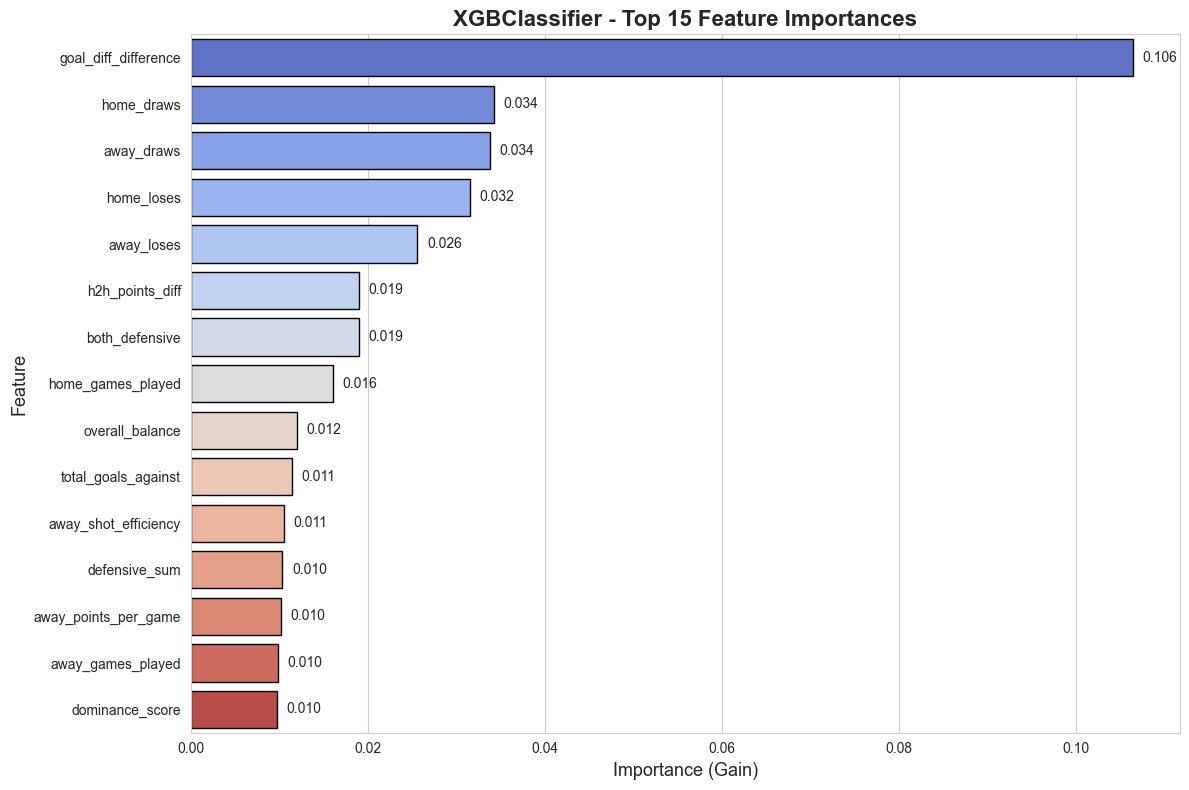

Saved: XGBClassifier_feature_importance.png



In [12]:
print("STEP 2: FEATURE IMPORTANCE ANALYSIS\n")
print("Method 1: Built-in Feature Importance (Gain)\n")

# Feature importance
feature_importance = best_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))
print()

# Plot with Seaborn for better aesthetics
plt.figure(figsize=(12,8))
top_features = importance_df.head(15)
sns.set_style("whitegrid")
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_features, 
    palette='coolwarm',  
    edgecolor='black'
)

plt.title(f'{type(best_model).__name__} - Top 15 Feature Importances', fontsize=16, fontweight='bold')
plt.xlabel('Importance (Gain)', fontsize=13)
plt.ylabel('Feature', fontsize=13)

# Annotate values
for i, v in enumerate(top_features['Importance']):
    plt.text(v + max(top_features['Importance'])*0.01, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_PATH / f'{type(best_model).__name__}_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()
print(f"Saved: {type(best_model).__name__}_feature_importance.png\n")


STEP 2: FEATURE IMPORTANCE ANALYSIS

Method 1: Built-in Feature Importance (Gain)

Top 15 Most Important Features:
             Feature  Importance
goal_diff_difference      0.1724
     combined_attack      0.0328
     h2h_points_diff      0.0298
          home_loses      0.0279
          home_draws      0.0278
          away_draws      0.0270
          away_loses      0.0250
     total_goals_for      0.0235
 total_goals_against      0.0224
     overall_balance      0.0221
     dominance_score      0.0198
away_points_per_game      0.0196
        total_points      0.0180
   home_games_played      0.0159
       defensive_sum      0.0127



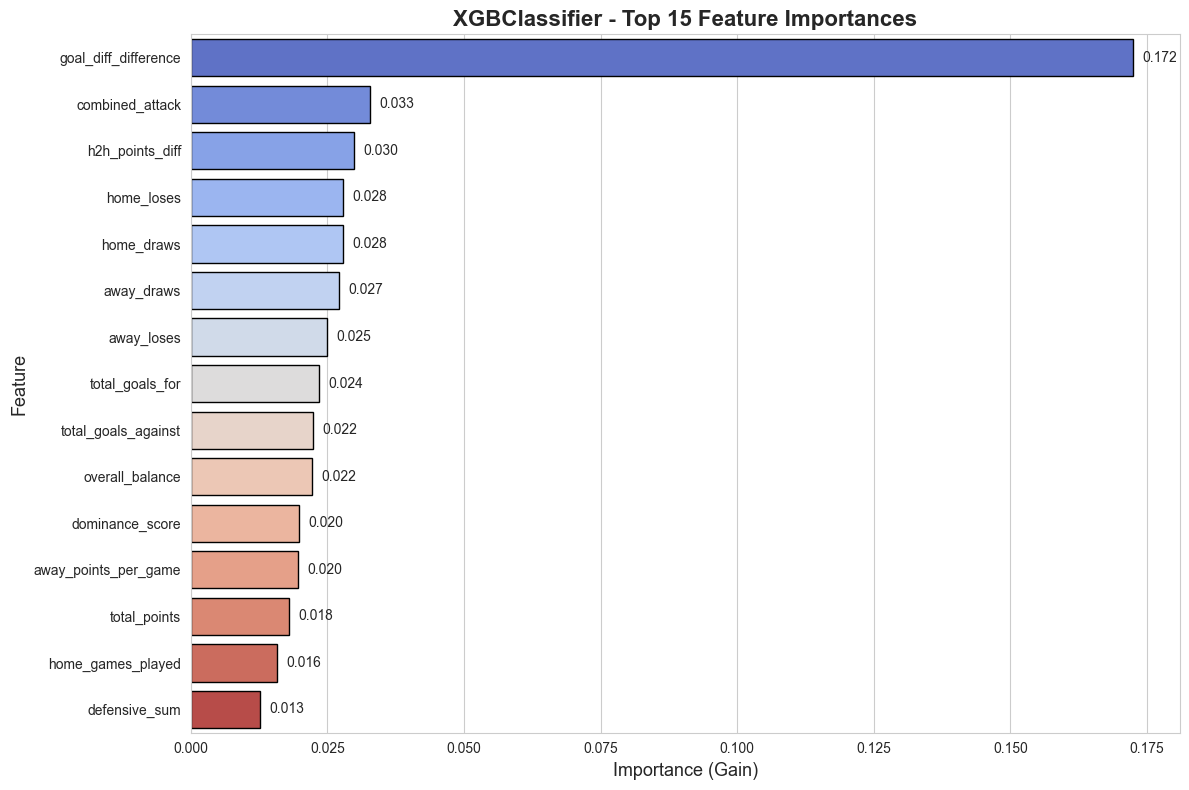

Saved: XGBClassifier_tuned_feature_importance.png



In [13]:
print("STEP 2: FEATURE IMPORTANCE ANALYSIS\n")
print("Method 1: Built-in Feature Importance (Gain)\n")

# Feature importance
feature_importance = best_tuned_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))
print()

# Plot with Seaborn for better aesthetics
plt.figure(figsize=(12,8))
top_features = importance_df.head(15)
sns.set_style("whitegrid")
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_features, 
    palette='coolwarm',  # nice gradient color
    edgecolor='black'
)

plt.title(f'{type(best_tuned_model).__name__} - Top 15 Feature Importances', fontsize=16, fontweight='bold')
plt.xlabel('Importance (Gain)', fontsize=13)
plt.ylabel('Feature', fontsize=13)

# Annotate values
for i, v in enumerate(top_features['Importance']):
    plt.text(v + max(top_features['Importance'])*0.01, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()

# Save figure
plt.savefig(FIGURES_PATH / f'{type(best_tuned_model).__name__}_tuned_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()
print(f"Saved: {type(best_tuned_model).__name__}_tuned_feature_importance.png\n")


##  FEATURE INTERACTIONS ANALYSIS

STEP 5: FEATURE INTERACTIONS ANALYSIS

Analyzing top feature interactions...



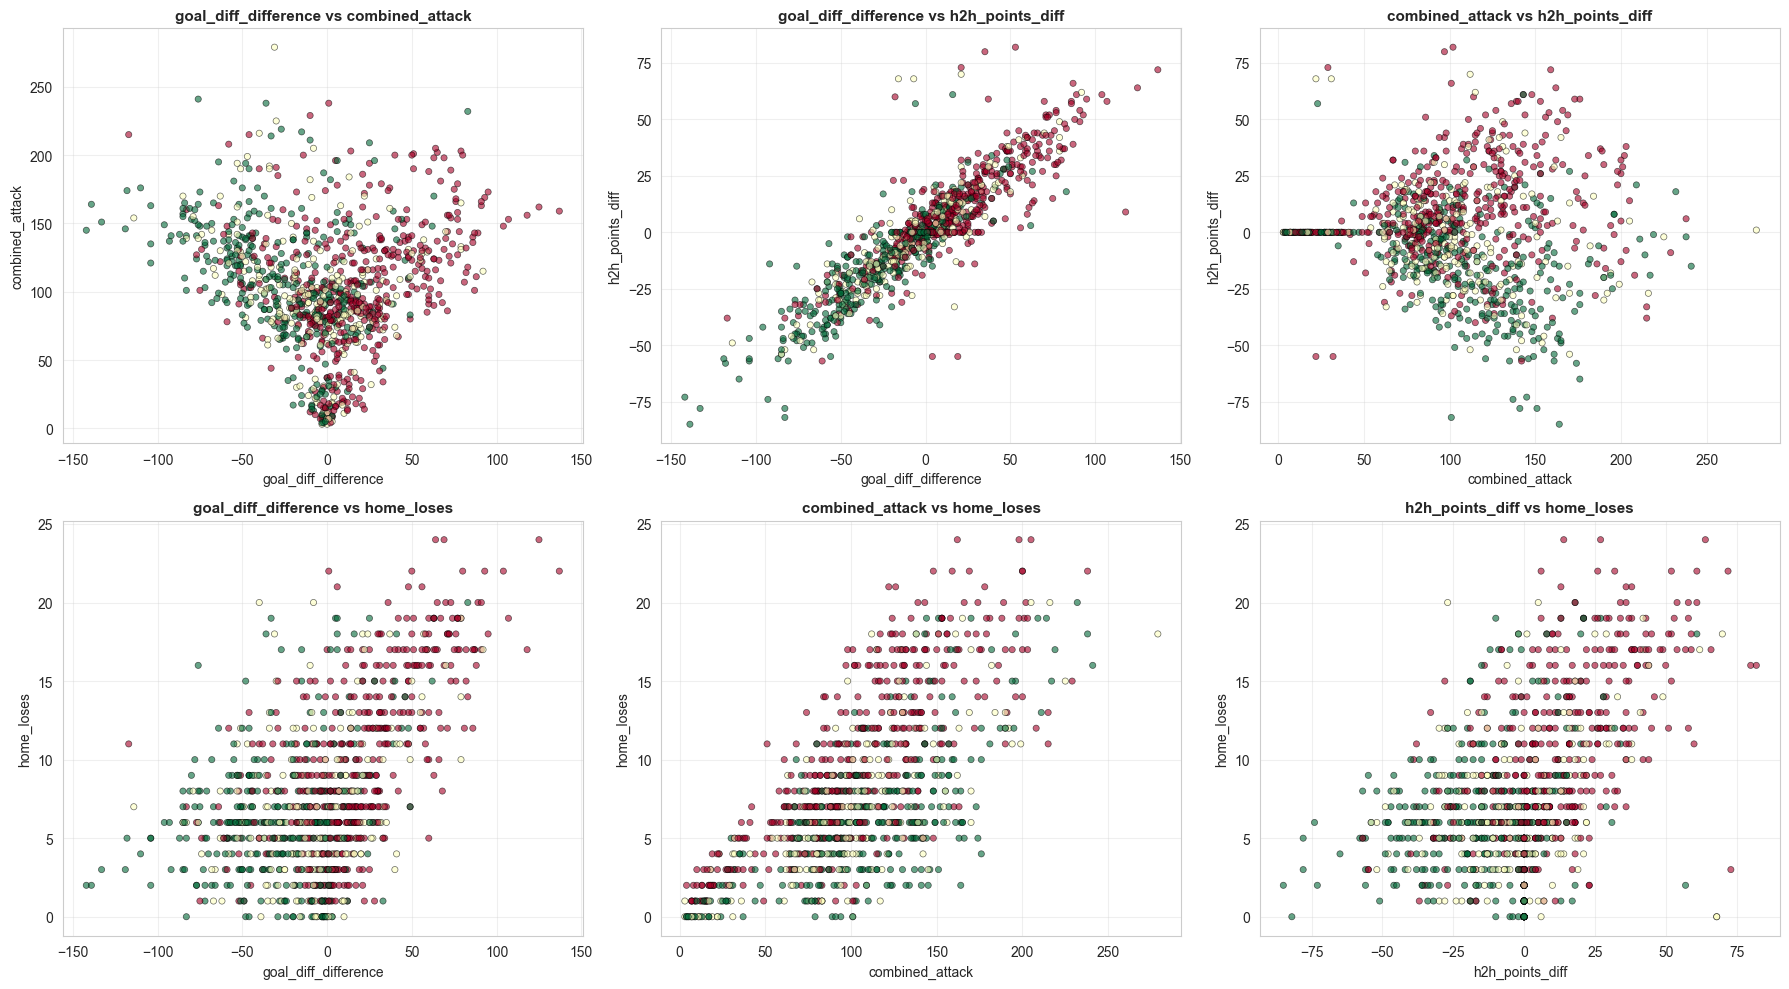

Saved: feature_interactions.png



In [14]:

print("STEP 5: FEATURE INTERACTIONS ANALYSIS\n")

print("Analyzing top feature interactions...\n")

top_5_features = importance_df.head(5)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, (feat1, feat2) in enumerate([
    (top_5_features[0], top_5_features[1]),
    (top_5_features[0], top_5_features[2]),
    (top_5_features[1], top_5_features[2]),
    (top_5_features[0], top_5_features[3]),
    (top_5_features[1], top_5_features[3]),
    (top_5_features[2], top_5_features[3])
]):
    scatter_data = X_train.sample(min(1000, len(X_train)), random_state=42)
    y_sample = y.loc[scatter_data.index]
    
    axes[idx].scatter(scatter_data[feat1], scatter_data[feat2], 
                     c=y_sample, cmap='RdYlGn', alpha=0.6, s=20, edgecolors='black', linewidth=0.5)
    axes[idx].set_xlabel(feat1, fontsize=10)
    axes[idx].set_ylabel(feat2, fontsize=10)
    axes[idx].set_title(f'{feat1} vs {feat2}', fontsize=11, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig(FIGURES_PATH / 'feature_interactions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: feature_interactions.png\n")


# LIGHTGBM VS LIGHTGBM_TUNED

Model Explainability and Interpretation
Analyzing LightGBM Models: Tuned vs Non-Tuned

Results will be saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results/figures/explainability

Loading data and preparing features...
Data shape: (18894, 106)
Train/Test split: 15115/3779
Number of features: 106

Loading models...
LightGBM Tuned model loaded
LightGBM Base model loaded

Model Performance Comparison

LightGBM (Tuned):
  Train Accuracy: 0.6744
  Test Accuracy: 0.6322
  Precision: 0.6239
  Recall: 0.6322
  F1-Score: 0.6222

LightGBM (Base):
  Train Accuracy: 0.8176
  Test Accuracy: 0.6272
  Precision: 0.6177
  Recall: 0.6272
  F1-Score: 0.6187

Performance comparison saved

Detailed Classification Reports

LightGBM (Tuned):
              precision    recall  f1-score   support

    Home Win       0.66      0.76      0.71      1683
        Draw       0.55      0.37      0.44       911
    Away Win       0.62      0.65      0.64      1185

    a

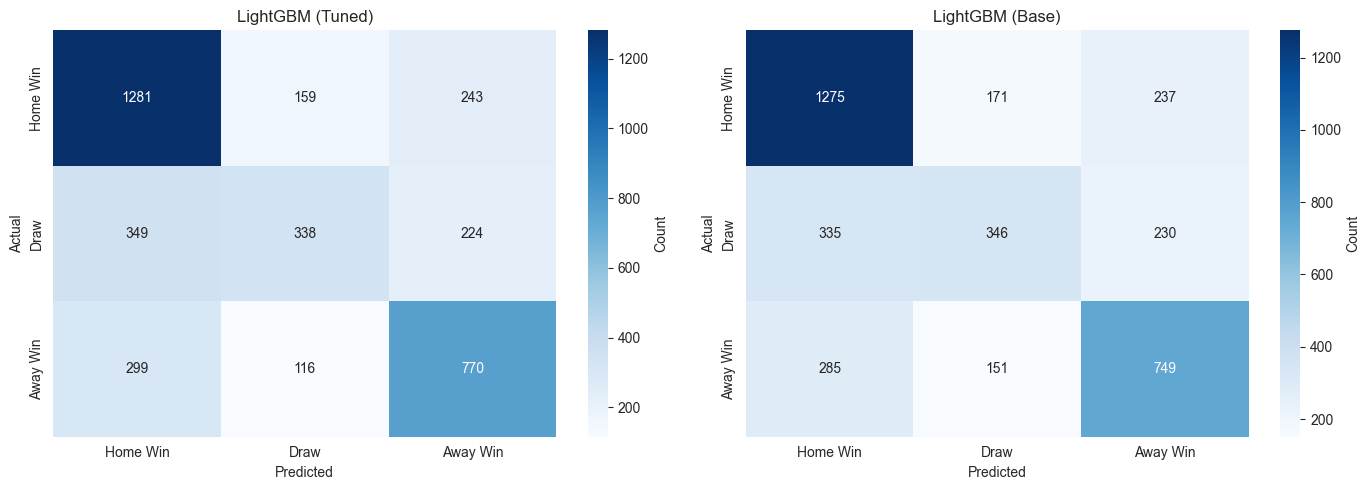

Confusion matrices saved

Feature Importance Analysis

Native LightGBM Feature Importance


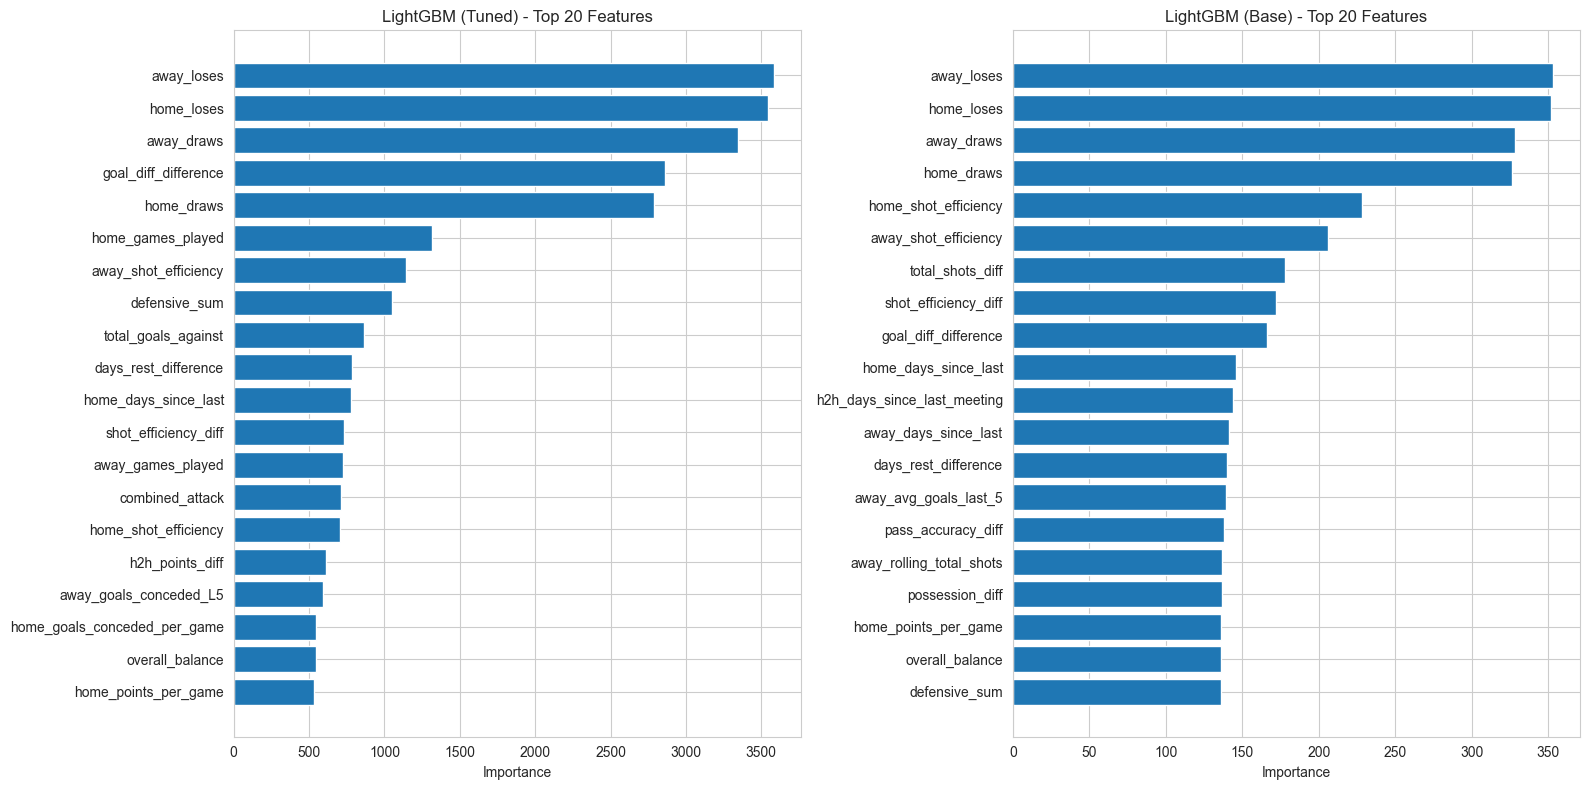

Native feature importance saved

LightGBM (Tuned) - Top 10 Features:
  away_loses: 3584.0000
  home_loses: 3545.0000
  away_draws: 3347.0000
  goal_diff_difference: 2864.0000
  home_draws: 2788.0000
  home_games_played: 1317.0000
  away_shot_efficiency: 1141.0000
  defensive_sum: 1051.0000
  total_goals_against: 866.0000
  days_rest_difference: 785.0000

LightGBM (Base) - Top 10 Features:
  away_loses: 353.0000
  home_loses: 352.0000
  away_draws: 328.0000
  home_draws: 326.0000
  home_shot_efficiency: 228.0000
  away_shot_efficiency: 206.0000
  total_shots_diff: 178.0000
  shot_efficiency_diff: 172.0000
  goal_diff_difference: 166.0000
  home_days_since_last: 146.0000

SHAP Analysis - Global Explainability

Computing SHAP values for tuned model (this may take a few minutes)...
SHAP values computed for tuned model

SHAP values shape: (3779, 106, 3)

Generating SHAP summary plot (global feature importance)...


<Figure size 1200x800 with 0 Axes>

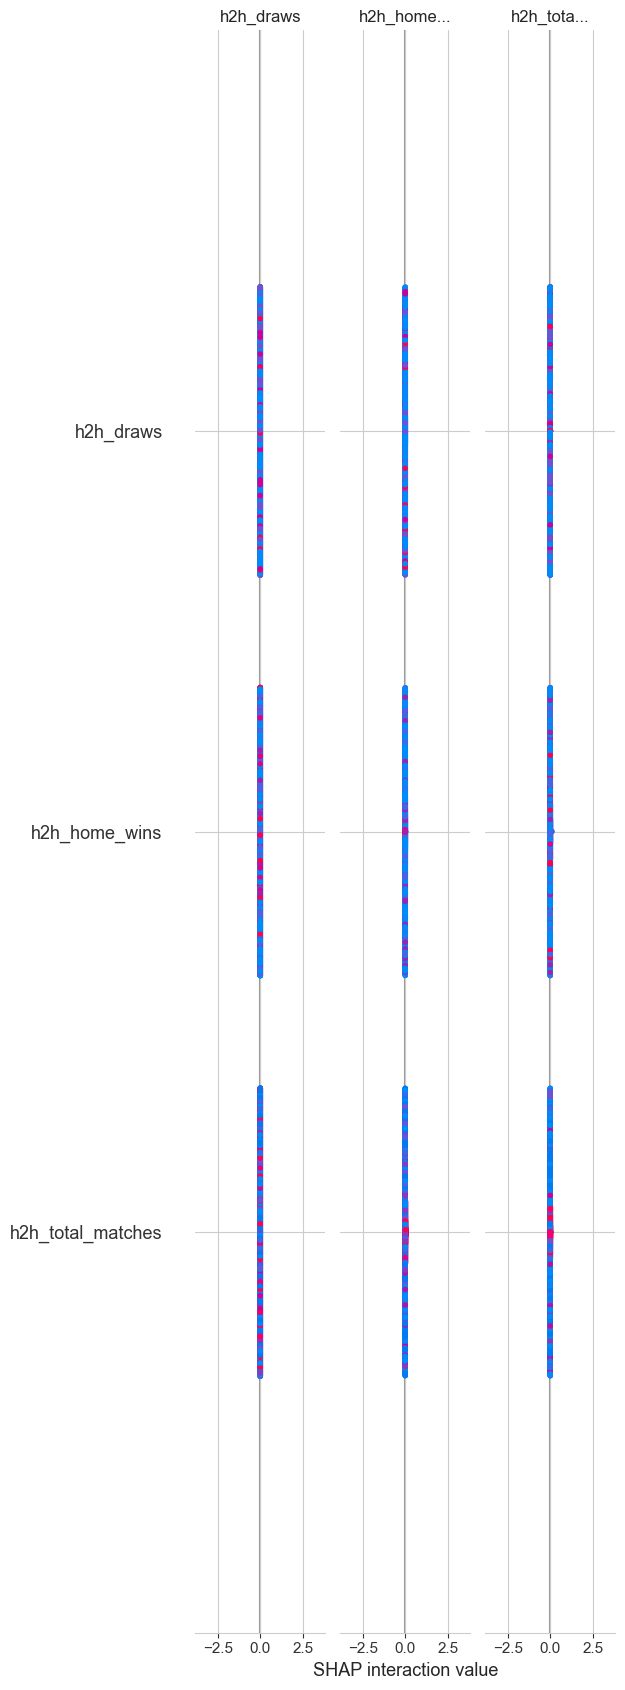

SHAP summary plot saved

Generating SHAP bar plot (mean absolute SHAP values)...
SHAP bar plot saved

Class-specific SHAP Analysis

SHAP analysis for: Home Win
  Top 5 features for Home Win:
    home_loses: 0.3979
    goal_diff_difference: 0.2651
    away_draws: 0.1233
    away_loses: 0.0905
    h2h_points_diff: 0.0565

SHAP analysis for: Draw
  Top 5 features for Draw:
    home_draws: 0.5068
    away_draws: 0.4225
    defensive_sum: 0.0785
    home_loses: 0.0394
    overall_balance: 0.0339

SHAP analysis for: Away Win
  Top 5 features for Away Win:
    away_loses: 0.5670
    goal_diff_difference: 0.2763
    home_loses: 0.1000
    away_shot_efficiency: 0.0838
    home_draws: 0.0746

SHAP Dependence Plots for Top Features

Generating dependence plots for: away_loses, home_draws, away_draws, goal_diff_difference, home_loses, away_shot_efficiency



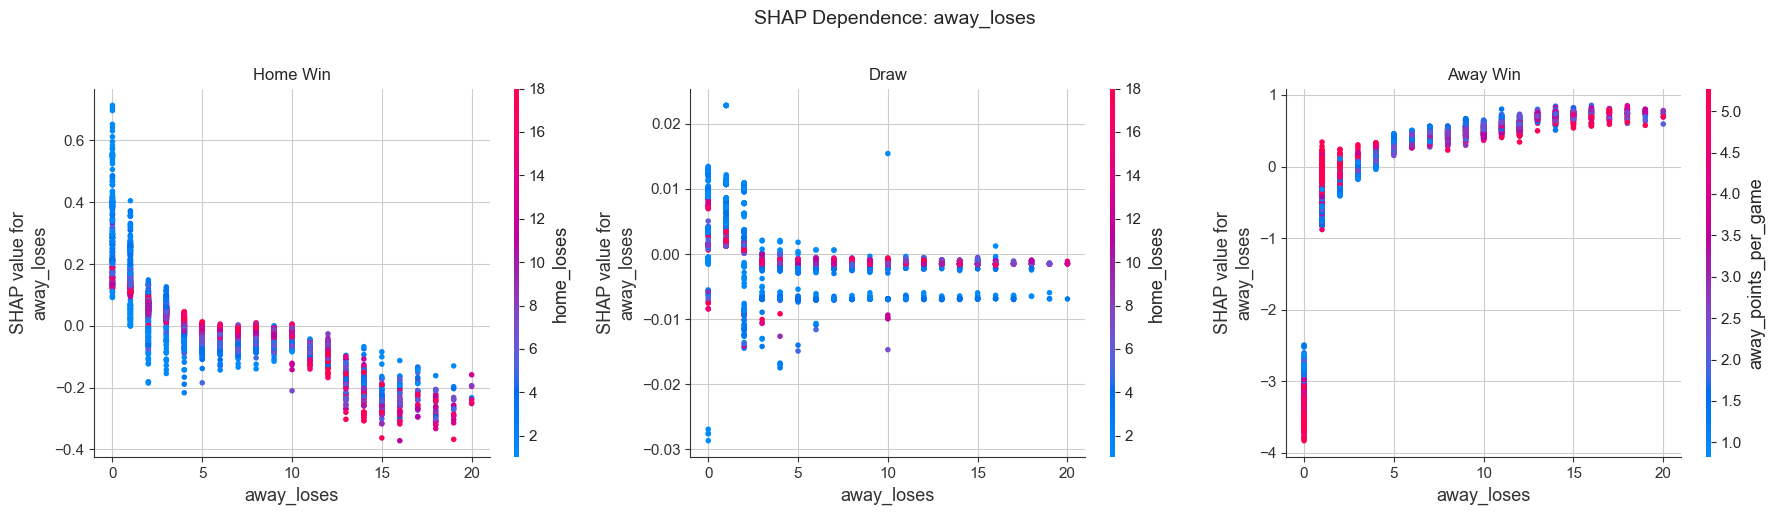

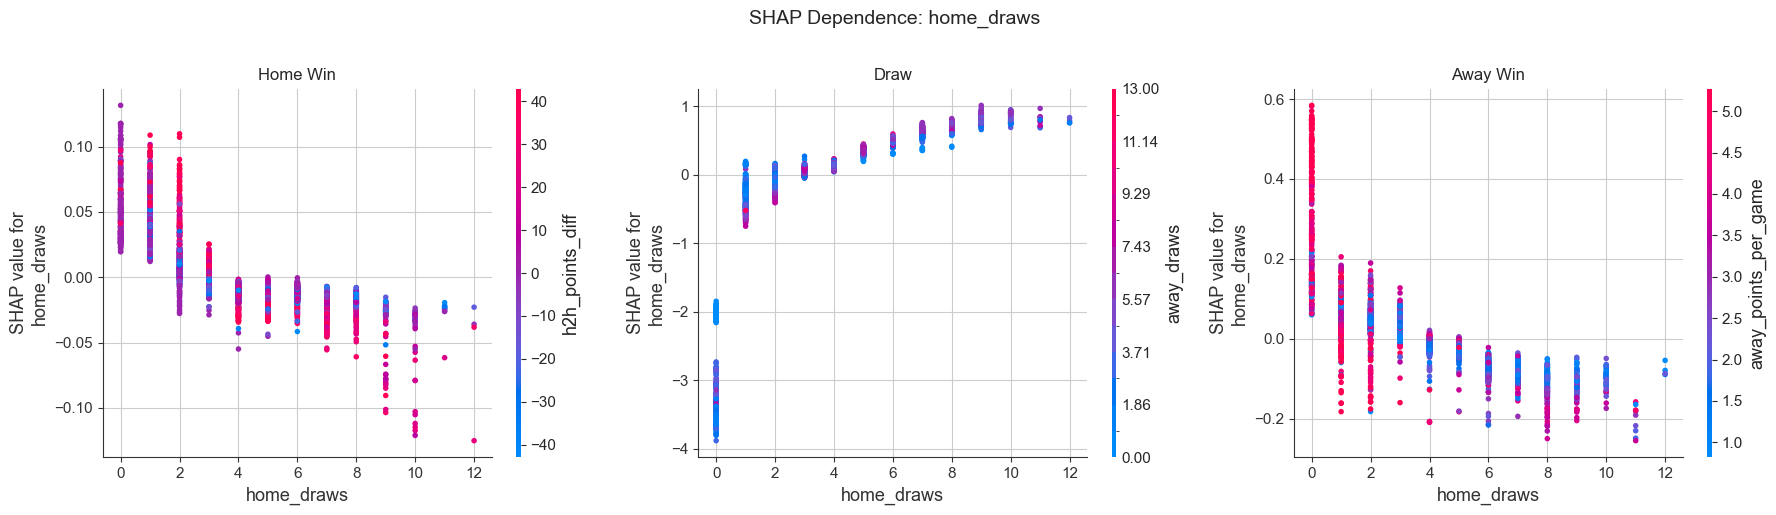

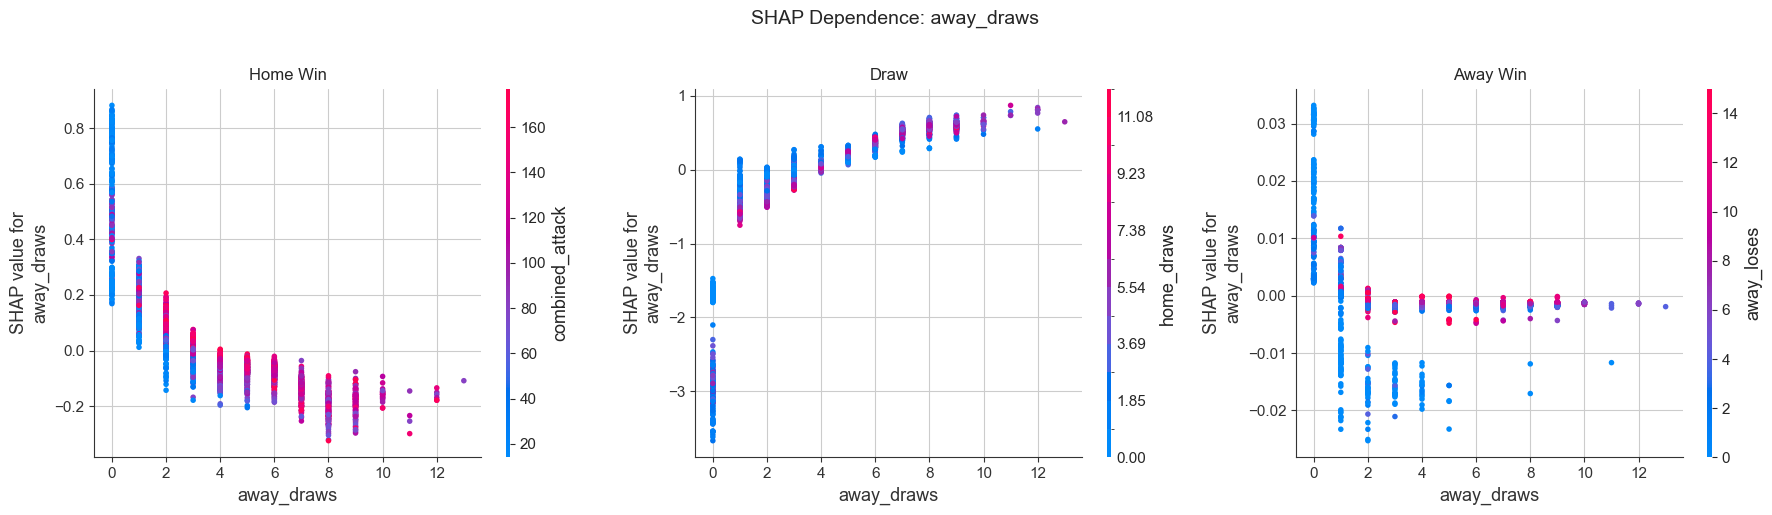

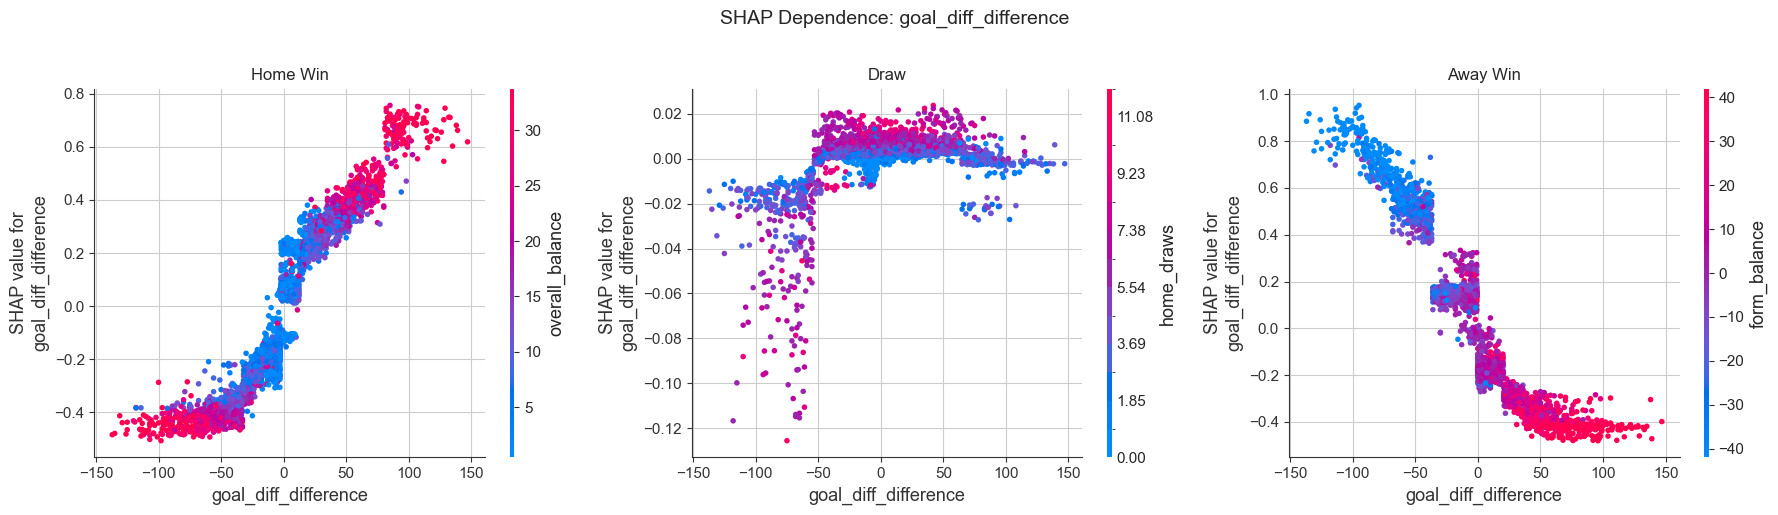

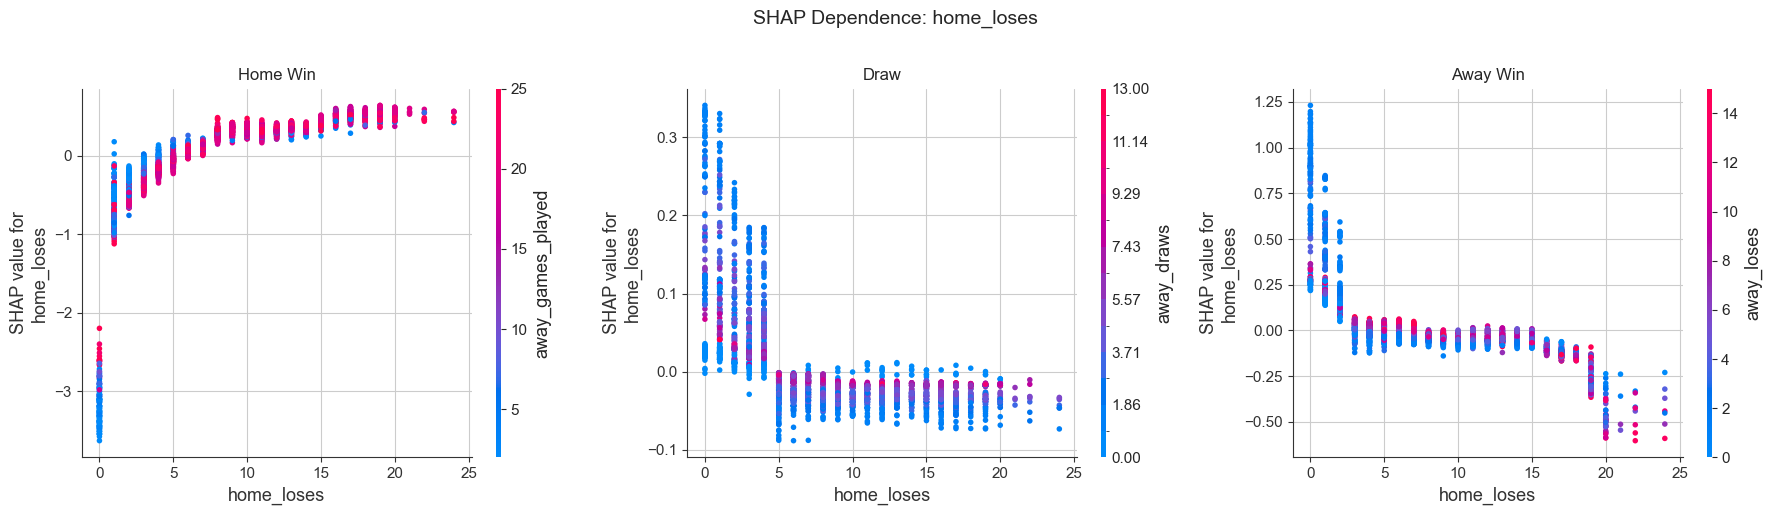

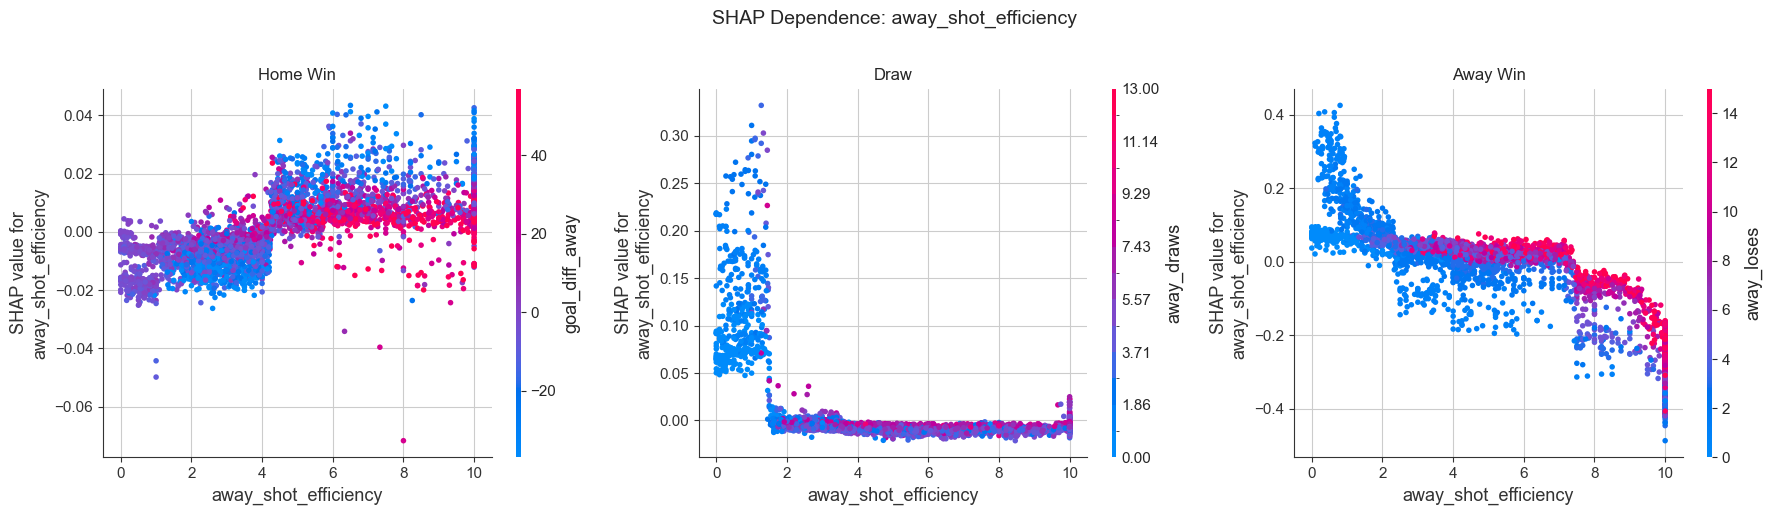

SHAP dependence plots saved

Local Explainability - Individual Predictions

Selecting interesting match scenarios...
Selected 5 interesting cases for local explainability

Generating SHAP Waterfall plots for individual predictions...
Correct High Confidence (Index: 0):
  Actual: Home Win
  Predicted: Home Win
  Probabilities - Home: 0.834, Draw: 0.087, Away: 0.079


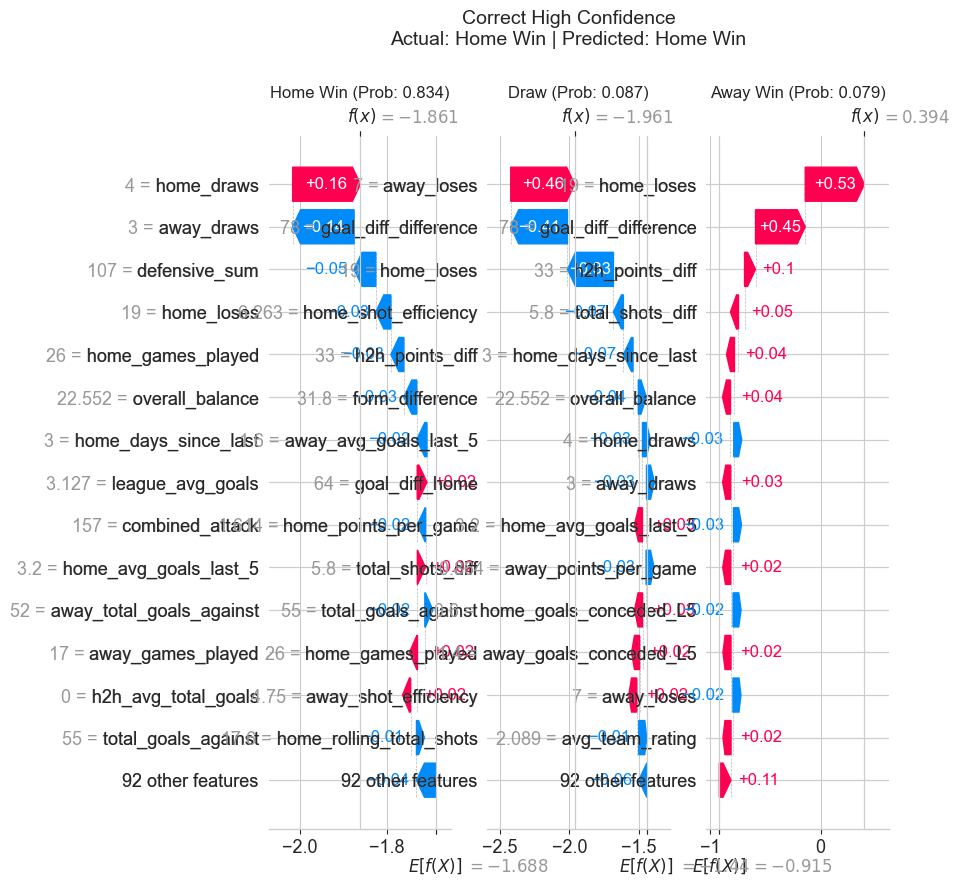


Incorrect High Confidence (Index: 35):
  Actual: Draw
  Predicted: Away Win
  Probabilities - Home: 0.222, Draw: 0.075, Away: 0.703


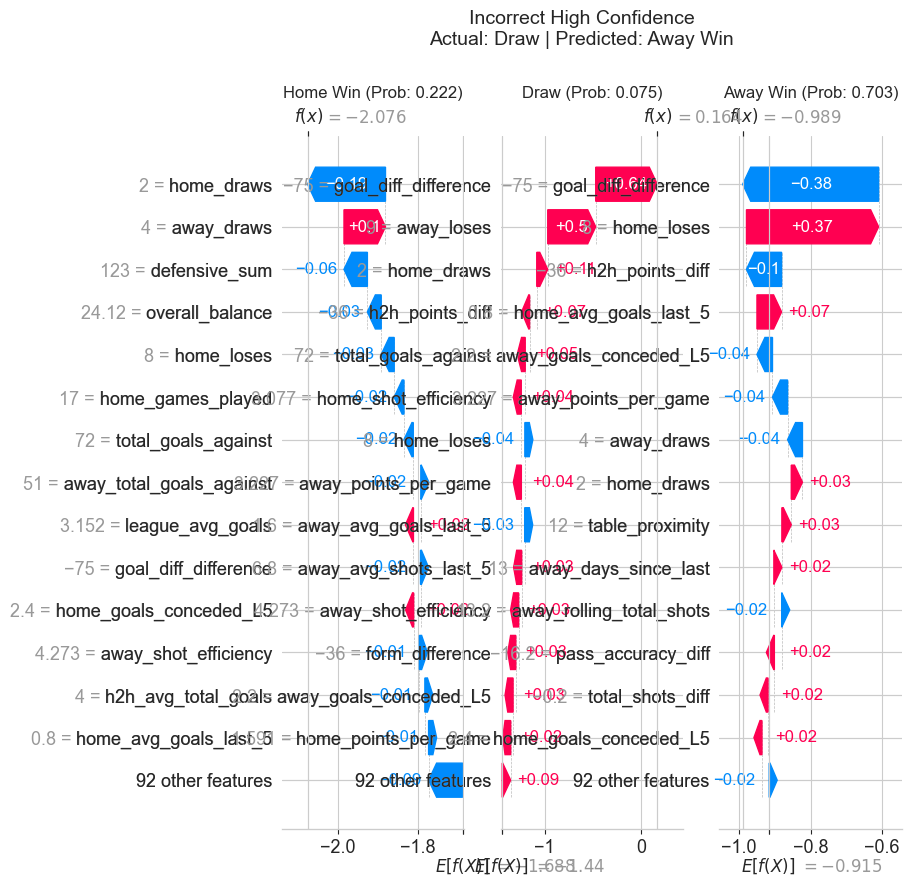


Home Win Prediction (Index: 0):
  Actual: Home Win
  Predicted: Home Win
  Probabilities - Home: 0.834, Draw: 0.087, Away: 0.079


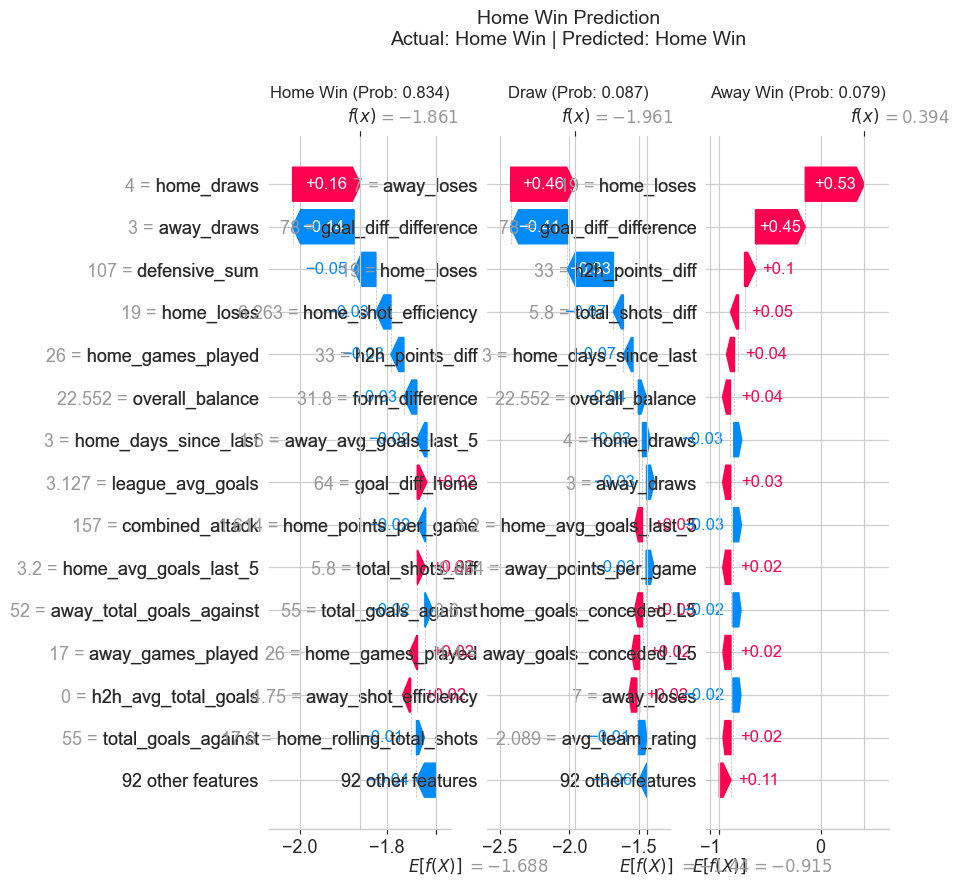


Draw Prediction (Index: 4):
  Actual: Draw
  Predicted: Draw
  Probabilities - Home: 0.236, Draw: 0.433, Away: 0.331


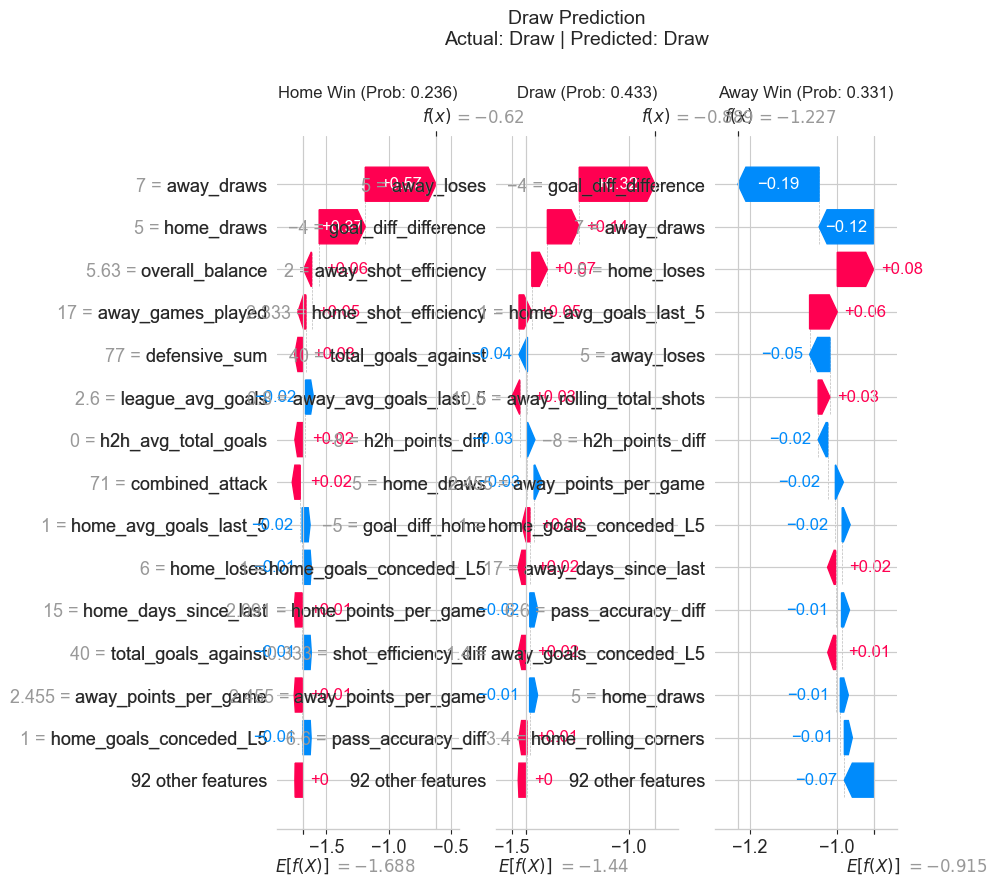


Away Win Prediction (Index: 1):
  Actual: Home Win
  Predicted: Away Win
  Probabilities - Home: 0.245, Draw: 0.321, Away: 0.435


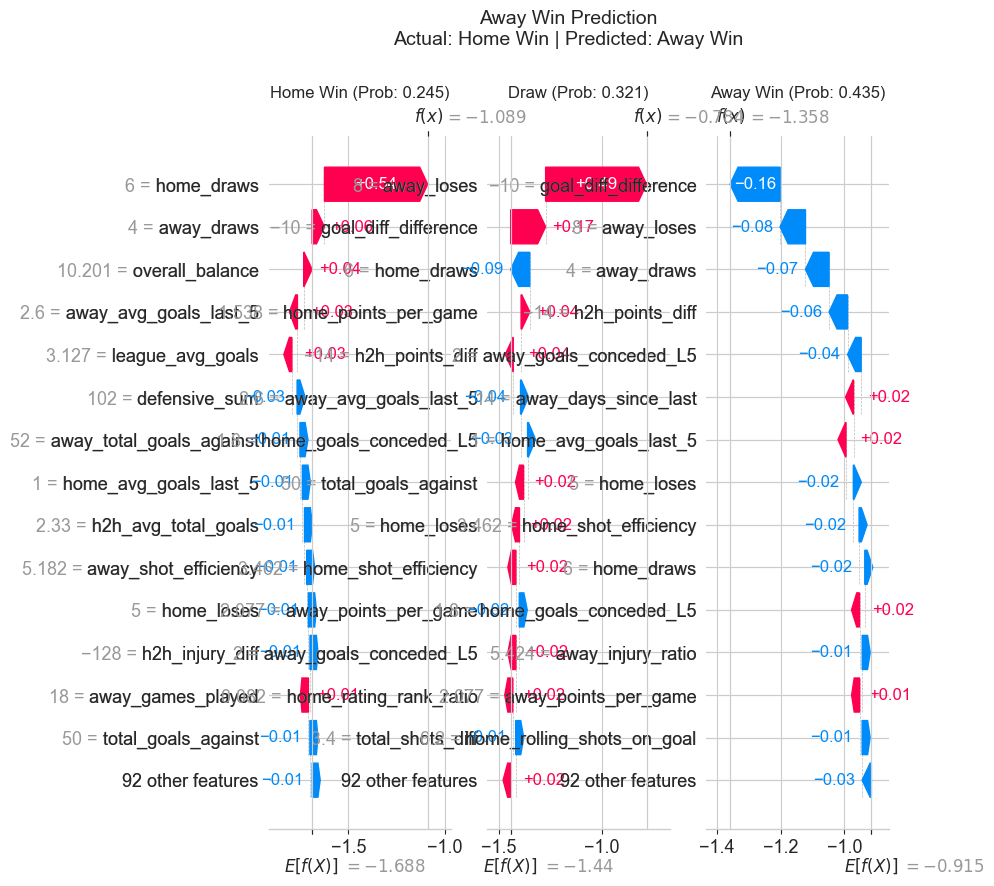


SHAP waterfall plots saved

SHAP Force Plots for Key Predictions

Generating force plot for: Correct High Confidence
Generating force plot for: Incorrect High Confidence
Generating force plot for: Home Win Prediction
SHAP force plots saved

LIME Analysis - Alternative Local Explainability

Initializing LIME explainer...
LIME explainer initialized

Generating LIME explanations for selected cases...
LIME explanation for: Correct High Confidence


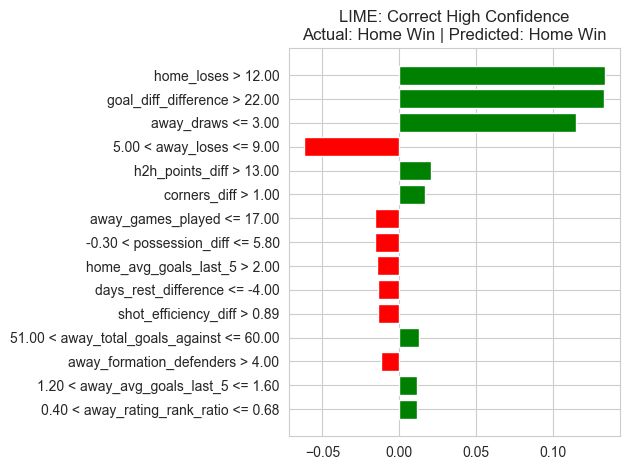

  Saved LIME plot for Correct High Confidence
LIME explanation for: Incorrect High Confidence


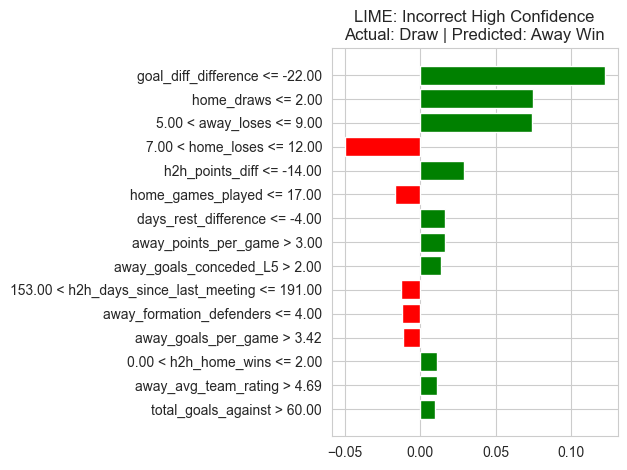

  Saved LIME plot for Incorrect High Confidence
LIME explanation for: Home Win Prediction


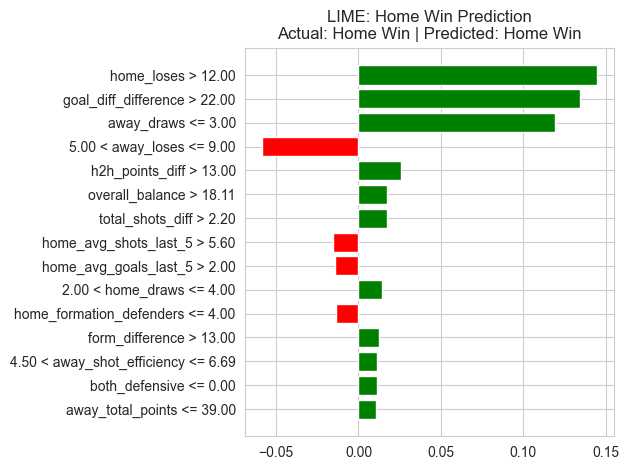

  Saved LIME plot for Home Win Prediction

LIME explanations saved

Feature Interaction Analysis

Computing SHAP interaction values (this may take several minutes)...
SHAP interaction values computed for 500 samples

Analyzing top feature interactions...
Top interactions for: Home Win
  Top 5 feature interactions:
    home_loses <-> goal_diff_difference: 0.0325
    home_loses <-> away_loses: 0.0271
    away_draws <-> home_loses: 0.0253
    home_loses <-> home_shot_efficiency: 0.0251
    away_draws <-> away_loses: 0.0205

Top interactions for: Draw
  Top 5 feature interactions:
    home_draws <-> away_draws: 0.0954
    away_draws <-> defensive_sum: 0.0234
    away_draws <-> home_loses: 0.0193
    home_draws <-> defensive_sum: 0.0165
    home_games_played <-> home_draws: 0.0150

Top interactions for: Away Win
  Top 5 feature interactions:
    home_loses <-> away_loses: 0.0379
    away_loses <-> away_shot_efficiency: 0.0341
    away_loses <-> goal_diff_difference: 0.0305
    home_draws <-

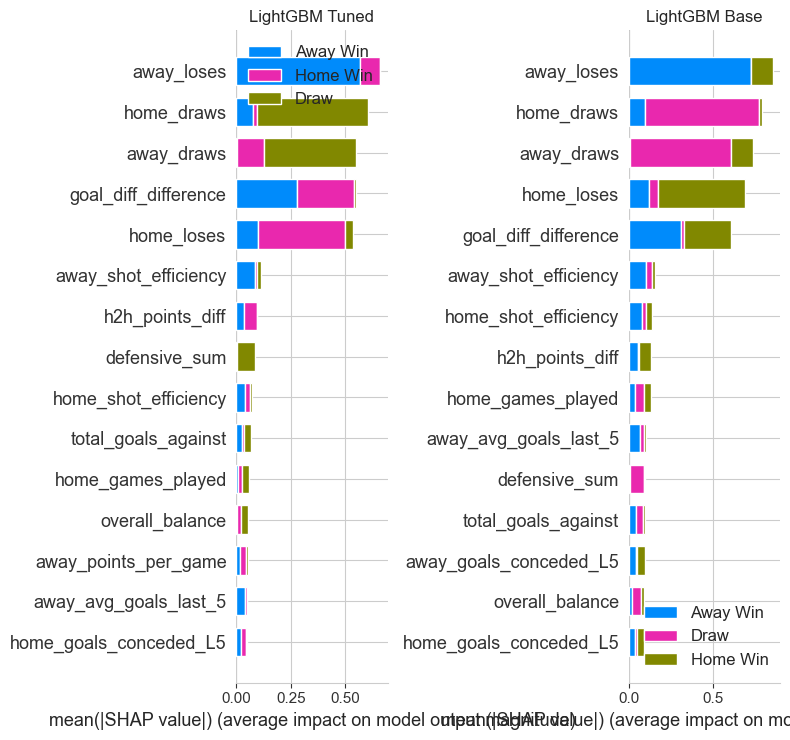

Model comparison plot saved

Key Football Insights Summary

Top 10 Most Important Features (SHAP):
  away_loses: 0.2201
  home_draws: 0.2007
  away_draws: 0.1829
  goal_diff_difference: 0.1828
  home_loses: 0.1791
  away_shot_efficiency: 0.0380
  h2h_points_diff: 0.0315
  defensive_sum: 0.0279
  home_shot_efficiency: 0.0240
  total_goals_against: 0.0228

Feature Category Distribution in Top 10:
  Home team features: 3
  Away team features: 3
  Head-to-head features: 1
  Other features: 3

Insights summary saved

Explainability Analysis Complete

Summary of Generated Outputs:

Figures saved:
  /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results/figures/explainability
  - confusion_matrices.png
  - feature_importance_native.png
  - shap_summary_plot_tuned.png
  - shap_bar_plot_tuned.png
  - shap_summary_[class].png (3 files)
  - shap_dependence_[feature].png (6 files)
  - shap_waterfall_[scenario].png (multiple files)
  - shap_force_[scenario].png (m

In [15]:
"""
Model Explainability and Interpretation
Football Match Outcome Prediction
Notebook 06: Explainability Analysis for Best Models
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

import shap
from lime import lime_tabular


print("Model Explainability and Interpretation")
print("Analyzing LightGBM Models: Tuned vs Non-Tuned")
print()


DATA_RAW_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/raw')
PROCESSED_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/processed')
FEATURES_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/features')
RESULTS_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results')
FIGURES_PATH = RESULTS_PATH / 'figures' / 'explainability'
TABLES_PATH = RESULTS_PATH / 'tables'
MODEL_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models')

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
TABLES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Results will be saved to: {FIGURES_PATH}")
print()


print("Loading data and preparing features...")

df = pd.read_csv(FEATURES_PATH / 'df_merged_complete_v2.csv')

features = [
    'h2h_total_matches', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'h2h_home_win_pct',
    'h2h_draw_pct', 'h2h_away_win_pct', 'h2h_avg_home_goals', 'h2h_avg_away_goals', 'h2h_avg_total_goals',
    'h2h_btts_pct', 'h2h_over_2_5_pct', 'h2h_last_5_home_wins', 'h2h_last_5_draws', 'h2h_last_5_away_wins',
    'h2h_days_since_last_meeting', 'avg_team_rating', 'total_points', 'total_goals_for', 'total_goals_against',
    'total_clean_sheets', 'away_avg_team_rating', 'away_total_points', 'away_total_goals_for',
    'away_total_goals_against', 'away_total_clean_sheets', 'h2h_rating_diff', 'h2h_points_diff',
    'h2h_injury_diff', 'home_rating_rank_ratio', 'away_rating_rank_ratio', 'home_points_per_game',
    'away_points_per_game', 'h2h_last_5_home_win_pct', 'h2h_last_5_draw_pct', 'h2h_last_5_away_win_pct',
    'h2h_goal_diff', 'home_avg_goals_last_5', 'home_avg_shots_last_5', 'home_avg_points_last_5',
    'away_avg_goals_last_5', 'away_avg_shots_last_5', 'away_avg_points_last_5', 'home_injury_ratio',
    'away_injury_ratio', 'home_team_experience', 'away_team_experience', 'home_formation_defenders',
    'away_formation_defenders', 'home_num_top_players', 'away_num_top_players', 'home_games_played',
    'away_games_played', 'home_draws', 'away_draws', 'home_loses', 'away_loses', 'home_goals_per_game',
    'away_goals_per_game', 'home_goals_conceded_per_game', 'away_goals_conceded_per_game',
    'goal_diff_home', 'goal_diff_away', 'goal_diff_difference', 'home_goals_conceded_L5',
    'away_goals_conceded_L5', 'form_difference', 'home_rolling_shots_on_goal', 'away_rolling_shots_on_goal',
    'shots_on_goal_diff', 'home_rolling_total_shots', 'away_rolling_total_shots', 'total_shots_diff',
    'home_rolling_corners', 'away_rolling_corners', 'corners_diff', 'home_rolling_possession',
    'away_rolling_possession', 'possession_diff', 'home_rolling_passes_accurate', 'away_rolling_passes_accurate',
    'home_rolling_pass_accuracy', 'away_rolling_pass_accuracy', 'pass_accuracy_diff', 'home_shot_efficiency',
    'away_shot_efficiency', 'shot_efficiency_diff', 'home_days_since_last', 'away_days_since_last',
    'days_rest_difference', 'table_proximity', 'is_close_match', 'league_home_advantage', 'league_avg_goals',
    'competitive_balance', 'rank_balance', 'form_balance', 'overall_balance', 'both_defensive',
    'defensive_sum', 'combined_attack', 'low_scoring_likelihood', 'home_draw_tendency', 'away_draw_tendency',
    'combined_draw_tendency', 'dominance_score'
]
target = 'target'

X = df[features].select_dtypes(include=[np.number]).copy()
y = df[target].copy()

if y.isna().any():
    mask = y.notna()
    X = X.loc[mask, :]
    y = y.loc[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

feature_names = X.columns.tolist()

print(f"Data shape: {X.shape}")
print(f"Train/Test split: {X_train.shape[0]}/{X_test.shape[0]}")
print(f"Number of features: {len(feature_names)}")
print()


print("Loading models...")

lgbm_tuned = joblib.load(MODEL_PATH / 'LightGBM_tuned.joblib')
lgbm_base = joblib.load(MODEL_PATH / 'LightGBM.joblib')

print("LightGBM Tuned model loaded")
print("LightGBM Base model loaded")
print()


print("Model Performance Comparison")
print()

models = {
    'LightGBM (Tuned)': lgbm_tuned,
    'LightGBM (Base)': lgbm_base
}

performance_results = []

for name, model in models.items():
    y_pred_train = model.predict(X_train_imputed)
    y_pred_test = model.predict(X_test_imputed)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
    
    performance_results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"{name}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print()

performance_df = pd.DataFrame(performance_results)
performance_df.to_csv(TABLES_PATH / 'explainability_model_performance.csv', index=False)

print("Performance comparison saved")
print()


print("Detailed Classification Reports")
print()

class_names = ['Home Win', 'Draw', 'Away Win']

for name, model in models.items():
    y_pred = model.predict(X_test_imputed)
    print(f"{name}:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    print()


print("Confusion Matrices")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_imputed)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved")
print()


print("Feature Importance Analysis")
print()

print("Native LightGBM Feature Importance")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, (name, model) in enumerate(models.items()):
    importance = model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    top_20 = importance_df.head(20)
    
    axes[idx].barh(range(len(top_20)), top_20['Importance'])
    axes[idx].set_yticks(range(len(top_20)))
    axes[idx].set_yticklabels(top_20['Feature'])
    axes[idx].set_xlabel('Importance')
    axes[idx].set_title(f'{name} - Top 20 Features')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'feature_importance_native.png', dpi=300, bbox_inches='tight')
plt.show()

print("Native feature importance saved")
print()

for name, model in models.items():
    importance = model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    csv_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    importance_df.to_csv(TABLES_PATH / f'feature_importance_{csv_name}.csv', index=False)
    
    print(f"{name} - Top 10 Features:")
    for i, row in importance_df.head(10).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
    print()


print("SHAP Analysis - Global Explainability")
print()

print("Computing SHAP values for tuned model (this may take a few minutes)...")

explainer_tuned = shap.TreeExplainer(lgbm_tuned)
shap_values_tuned = explainer_tuned.shap_values(X_test_imputed)

print("SHAP values computed for tuned model")
print()

if isinstance(shap_values_tuned, list):
    shap_values_array = np.array(shap_values_tuned)
else:
    shap_values_array = shap_values_tuned

print(f"SHAP values shape: {shap_values_array.shape}")
print()


print("Generating SHAP summary plot (global feature importance)...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_tuned, X_test_imputed, feature_names=feature_names, 
                  class_names=class_names, show=False, max_display=20)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'shap_summary_plot_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

print("SHAP summary plot saved")
print()


print("Generating SHAP bar plot (mean absolute SHAP values)...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_tuned, X_test_imputed, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=20, class_names=class_names)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'shap_bar_plot_tuned.png', dpi=300, bbox_inches='tight')
plt.close()

print("SHAP bar plot saved")
print()


print("Class-specific SHAP Analysis")
print()

for class_idx, class_name in enumerate(class_names):
    print(f"SHAP analysis for: {class_name}")
    
    if isinstance(shap_values_tuned, list):
        shap_class = shap_values_tuned[class_idx]
    else:
        shap_class = shap_values_tuned[:, :, class_idx]
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_class, X_test_imputed, feature_names=feature_names,
                      show=False, max_display=20)
    plt.title(f'SHAP Summary - {class_name}')
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / f'shap_summary_{class_name.lower().replace(" ", "_")}.png', 
                dpi=300, bbox_inches='tight')
    plt.close()
    
    mean_abs_shap = np.abs(shap_class).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values('Mean_Abs_SHAP', ascending=False)
    
    shap_importance_df.to_csv(TABLES_PATH / f'shap_importance_{class_name.lower().replace(" ", "_")}.csv', 
                              index=False)
    
    print(f"  Top 5 features for {class_name}:")
    for i, row in shap_importance_df.head(5).iterrows():
        print(f"    {row['Feature']}: {row['Mean_Abs_SHAP']:.4f}")
    print()


print("SHAP Dependence Plots for Top Features")
print()

if isinstance(shap_values_tuned, list):
    overall_importance = np.abs(np.array(shap_values_tuned)).mean(axis=(0, 1))
else:
    overall_importance = np.abs(shap_values_tuned).mean(axis=(0, 2))

top_features_idx = overall_importance.argsort()[-6:][::-1]
top_features = [feature_names[i] for i in top_features_idx]

print(f"Generating dependence plots for: {', '.join(top_features)}")
print()

for feat_idx, feat_name in zip(top_features_idx, top_features):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for class_idx, class_name in enumerate(class_names):
        if isinstance(shap_values_tuned, list):
            shap_class = shap_values_tuned[class_idx]
        else:
            shap_class = shap_values_tuned[:, :, class_idx]
        
        shap.dependence_plot(feat_idx, shap_class, X_test_imputed,
                            feature_names=feature_names,
                            ax=axes[class_idx], show=False)
        axes[class_idx].set_title(f'{class_name}')
    
    fig.suptitle(f'SHAP Dependence: {feat_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / f'shap_dependence_{feat_name.lower().replace(" ", "_")}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

print("SHAP dependence plots saved")
print()


print("Local Explainability - Individual Predictions")
print()

print("Selecting interesting match scenarios...")

y_pred_test = lgbm_tuned.predict(X_test_imputed)
y_pred_proba_test = lgbm_tuned.predict_proba(X_test_imputed)

correct_predictions = np.where(y_pred_test == y_test)[0]
incorrect_predictions = np.where(y_pred_test != y_test)[0]

high_confidence_correct = []
for idx in correct_predictions:
    max_prob = y_pred_proba_test[idx].max()
    if max_prob > 0.8:
        high_confidence_correct.append((idx, max_prob))

high_confidence_incorrect = []
for idx in incorrect_predictions:
    max_prob = y_pred_proba_test[idx].max()
    if max_prob > 0.7:
        high_confidence_incorrect.append((idx, max_prob))

selected_indices = []

if high_confidence_correct:
    selected_indices.append(('Correct High Confidence', high_confidence_correct[0][0]))

if high_confidence_incorrect:
    selected_indices.append(('Incorrect High Confidence', high_confidence_incorrect[0][0]))

home_win_pred = np.where(y_pred_test == 0)[0]
if len(home_win_pred) > 0:
    selected_indices.append(('Home Win Prediction', home_win_pred[0]))

draw_pred = np.where(y_pred_test == 1)[0]
if len(draw_pred) > 0:
    selected_indices.append(('Draw Prediction', draw_pred[0]))

away_win_pred = np.where(y_pred_test == 2)[0]
if len(away_win_pred) > 0:
    selected_indices.append(('Away Win Prediction', away_win_pred[0]))

print(f"Selected {len(selected_indices)} interesting cases for local explainability")
print()


print("Generating SHAP Waterfall plots for individual predictions...")

for scenario_name, idx in selected_indices:
    actual = class_names[int(y_test.iloc[idx])]
    predicted = class_names[y_pred_test[idx]]
    probas = y_pred_proba_test[idx]
    
    print(f"{scenario_name} (Index: {idx}):")
    print(f"  Actual: {actual}")
    print(f"  Predicted: {predicted}")
    print(f"  Probabilities - Home: {probas[0]:.3f}, Draw: {probas[1]:.3f}, Away: {probas[2]:.3f}")
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for class_idx, class_name in enumerate(class_names):
        if isinstance(shap_values_tuned, list):
            shap_class = shap_values_tuned[class_idx]
        else:
            shap_class = shap_values_tuned[:, :, class_idx]
        
        explanation = shap.Explanation(
            values=shap_class[idx],
            base_values=explainer_tuned.expected_value[class_idx] if isinstance(explainer_tuned.expected_value, (list, np.ndarray)) else explainer_tuned.expected_value,
            data=X_test_imputed[idx],
            feature_names=feature_names
        )
        
        shap.plots.waterfall(explanation, max_display=15, show=False)
        axes[class_idx].set_title(f'{class_name} (Prob: {probas[class_idx]:.3f})')
        plt.sca(axes[class_idx])
    
    fig.suptitle(f'{scenario_name}\nActual: {actual} | Predicted: {predicted}', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    
    filename = scenario_name.lower().replace(' ', '_')
    plt.savefig(FIGURES_PATH / f'shap_waterfall_{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print()

print("SHAP waterfall plots saved")
print()


print("SHAP Force Plots for Key Predictions")
print()

for scenario_name, idx in selected_indices[:3]:
    actual = class_names[int(y_test.iloc[idx])]
    predicted = class_names[y_pred_test[idx]]
    
    print(f"Generating force plot for: {scenario_name}")
    
    predicted_class_idx = y_pred_test[idx]
    
    if isinstance(shap_values_tuned, list):
        shap_vals = shap_values_tuned[predicted_class_idx][idx]
        base_val = explainer_tuned.expected_value[predicted_class_idx]
    else:
        shap_vals = shap_values_tuned[idx, :, predicted_class_idx]
        base_val = explainer_tuned.expected_value[predicted_class_idx] if isinstance(explainer_tuned.expected_value, (list, np.ndarray)) else explainer_tuned.expected_value
    
    fig = shap.force_plot(
        base_val,
        shap_vals,
        X_test_imputed[idx],
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    
    plt.title(f'{scenario_name} - {predicted}\nActual: {actual} | Predicted: {predicted}')
    plt.tight_layout()
    
    filename = scenario_name.lower().replace(' ', '_')
    plt.savefig(FIGURES_PATH / f'shap_force_{filename}.png', dpi=300, bbox_inches='tight')
    plt.close()

print("SHAP force plots saved")
print()


print("LIME Analysis - Alternative Local Explainability")
print()

print("Initializing LIME explainer...")

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_imputed,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42
)

print("LIME explainer initialized")
print()

print("Generating LIME explanations for selected cases...")

for scenario_name, idx in selected_indices[:3]:
    actual = class_names[int(y_test.iloc[idx])]
    predicted = class_names[y_pred_test[idx]]
    
    print(f"LIME explanation for: {scenario_name}")
    
    lime_exp = lime_explainer.explain_instance(
        data_row=X_test_imputed[idx],
        predict_fn=lgbm_tuned.predict_proba,
        num_features=15,
        top_labels=3
    )
    
    fig = lime_exp.as_pyplot_figure(label=y_pred_test[idx])
    plt.title(f'LIME: {scenario_name}\nActual: {actual} | Predicted: {predicted}')
    plt.tight_layout()
    
    filename = scenario_name.lower().replace(' ', '_')
    plt.savefig(FIGURES_PATH / f'lime_{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  Saved LIME plot for {scenario_name}")

print()
print("LIME explanations saved")
print()


print("Feature Interaction Analysis")
print()

print("Computing SHAP interaction values (this may take several minutes)...")

sample_size = min(500, len(X_test_imputed))
X_sample = X_test_imputed[:sample_size]

shap_interaction_values = explainer_tuned.shap_interaction_values(X_sample)

print(f"SHAP interaction values computed for {sample_size} samples")
print()

print("Analyzing top feature interactions...")

for class_idx, class_name in enumerate(class_names):
    print(f"Top interactions for: {class_name}")
    
    if isinstance(shap_interaction_values, list):
        interaction_matrix = np.abs(shap_interaction_values[class_idx]).mean(axis=0)
    else:
        interaction_matrix = np.abs(shap_interaction_values[:, :, :, class_idx]).mean(axis=0)
    
    np.fill_diagonal(interaction_matrix, 0)
    
    interaction_pairs = []
    for i in range(len(feature_names)):
        for j in range(i+1, len(feature_names)):
            interaction_pairs.append({
                'Feature_1': feature_names[i],
                'Feature_2': feature_names[j],
                'Interaction_Strength': interaction_matrix[i, j]
            })
    
    interaction_df = pd.DataFrame(interaction_pairs).sort_values(
        'Interaction_Strength', ascending=False
    )
    
    interaction_df.to_csv(
        TABLES_PATH / f'feature_interactions_{class_name.lower().replace(" ", "_")}.csv',
        index=False
    )
    
    print(f"  Top 5 feature interactions:")
    for i, row in interaction_df.head(5).iterrows():
        print(f"    {row['Feature_1']} <-> {row['Feature_2']}: {row['Interaction_Strength']:.4f}")
    print()

print("Feature interaction analysis complete")
print()


print("Model Comparison: Tuned vs Base")
print()

print("Computing SHAP values for base model...")

explainer_base = shap.TreeExplainer(lgbm_base)
shap_values_base = explainer_base.shap_values(X_test_imputed[:500])

print("SHAP values computed for base model")
print()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plt.sca(axes[0])
shap.summary_plot(shap_values_tuned, X_test_imputed[:500], feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15, class_names=class_names)
axes[0].set_title('LightGBM Tuned')

plt.sca(axes[1])
shap.summary_plot(shap_values_base, X_test_imputed[:500], feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15, class_names=class_names)
axes[1].set_title('LightGBM Base')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'shap_comparison_tuned_vs_base.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison plot saved")
print()


print("Key Football Insights Summary")
print()

if isinstance(shap_values_tuned, list):
    overall_shap_importance = np.abs(np.array(shap_values_tuned)).mean(axis=(0, 1))
else:
    overall_shap_importance = np.abs(shap_values_tuned).mean(axis=(0, 2))

top_10_idx = overall_shap_importance.argsort()[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_idx]
top_10_importance = overall_shap_importance[top_10_idx]

print("Top 10 Most Important Features (SHAP):")
for feat, imp in zip(top_10_features, top_10_importance):
    print(f"  {feat}: {imp:.4f}")
print()

home_features = [f for f in top_10_features if 'home' in f.lower()]
away_features = [f for f in top_10_features if 'away' in f.lower()]
h2h_features = [f for f in top_10_features if 'h2h' in f.lower()]

print("Feature Category Distribution in Top 10:")
print(f"  Home team features: {len(home_features)}")
print(f"  Away team features: {len(away_features)}")
print(f"  Head-to-head features: {len(h2h_features)}")
print(f"  Other features: {10 - len(home_features) - len(away_features) - len(h2h_features)}")
print()


insights_summary = {
    'total_features': len(feature_names),
    'top_feature': top_10_features[0],
    'top_feature_importance': float(top_10_importance[0]),
    'home_features_in_top10': len(home_features),
    'away_features_in_top10': len(away_features),
    'h2h_features_in_top10': len(h2h_features),
    'tuned_test_accuracy': performance_df[performance_df['Model'] == 'LightGBM (Tuned)']['Test Accuracy'].values[0],
    'base_test_accuracy': performance_df[performance_df['Model'] == 'LightGBM (Base)']['Test Accuracy'].values[0],
    'accuracy_improvement': performance_df[performance_df['Model'] == 'LightGBM (Tuned)']['Test Accuracy'].values[0] - 
                           performance_df[performance_df['Model'] == 'LightGBM (Base)']['Test Accuracy'].values[0]
}

import json
with open(TABLES_PATH / 'explainability_insights_summary.json', 'w') as f:
    json.dump(insights_summary, f, indent=2)

print("Insights summary saved")
print()


print("Explainability Analysis Complete")
print()
print("Summary of Generated Outputs:")
print()
print("Figures saved:")
print(f"  {FIGURES_PATH}")
print("  - confusion_matrices.png")
print("  - feature_importance_native.png")
print("  - shap_summary_plot_tuned.png")
print("  - shap_bar_plot_tuned.png")
print("  - shap_summary_[class].png (3 files)")
print("  - shap_dependence_[feature].png (6 files)")
print("  - shap_waterfall_[scenario].png (multiple files)")
print("  - shap_force_[scenario].png (multiple files)")
print("  - lime_[scenario].png (3 files)")
print("  - shap_comparison_tuned_vs_base.png")
print()
print("Tables saved:")
print(f"  {TABLES_PATH}")
print("  - explainability_model_performance.csv")
print("  - feature_importance_lightgbm_tuned.csv")
print("  - feature_importance_lightgbm_base.csv")
print("  - shap_importance_[class].csv (3 files)")
print("  - feature_interactions_[class].csv (3 files)")
print("  - explainability_insights_summary.json")
print()
print("All explainability analysis complete!")

# XGBOOST VS XGBOOST_TUNED

Model Explainability and Interpretation
Analyzing XGBoost Models: Tuned vs Non-Tuned

Results will be saved to: /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results/figures/explainability

Loading data and preparing features...
Data shape: (18894, 106)
Train/Test split: 15115/3779
Number of features: 106

Loading models...
Non-tuned LogisticRegression loaded successfully.
Non-tuned RandomForest loaded successfully.
Non-tuned MLPClassifier loaded successfully.
Non-tuned XGBoost loaded successfully.
Non-tuned LightGBM loaded successfully.
Tuned LogisticRegression loaded successfully.
Tuned RandomForest loaded successfully.
Tuned MLPClassifier loaded successfully.
Tuned XGBoost loaded successfully.
Tuned LightGBM loaded successfully.
XGBoost Tuned model loaded
XGBoost Base model loaded

Model Performance Comparison

XGBoost (Tuned):
  Train Accuracy: 0.6473
  Test Accuracy: 0.6377
  Precision: 0.6305
  Recall: 0.6377
  F1-Score: 0.6286

XGBoost (Base):

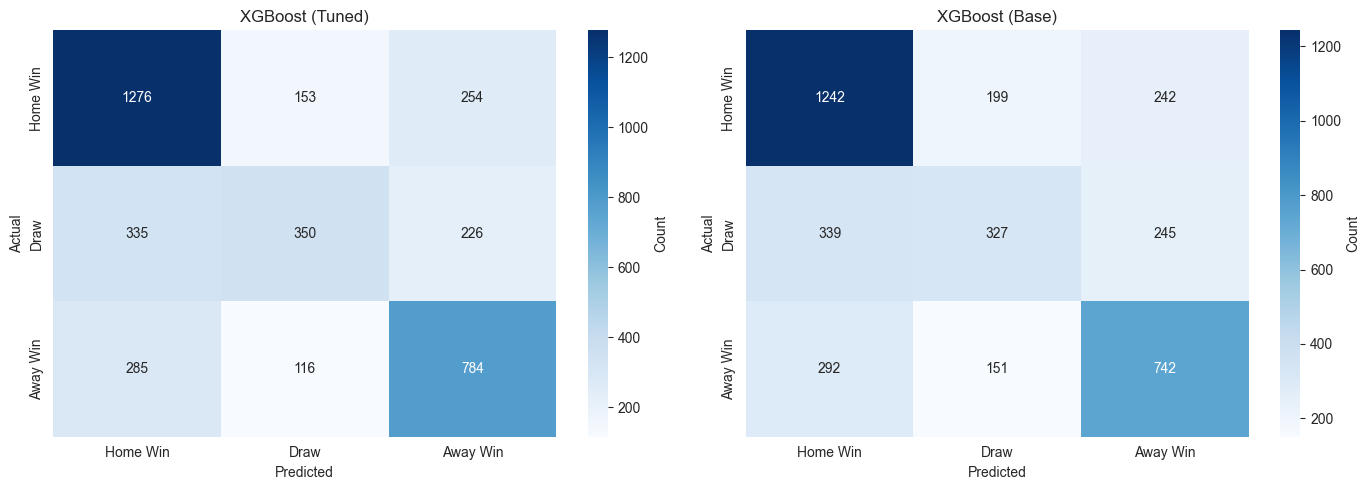

Confusion matrices saved

Feature Importance Analysis

Native XGBoost Feature Importance


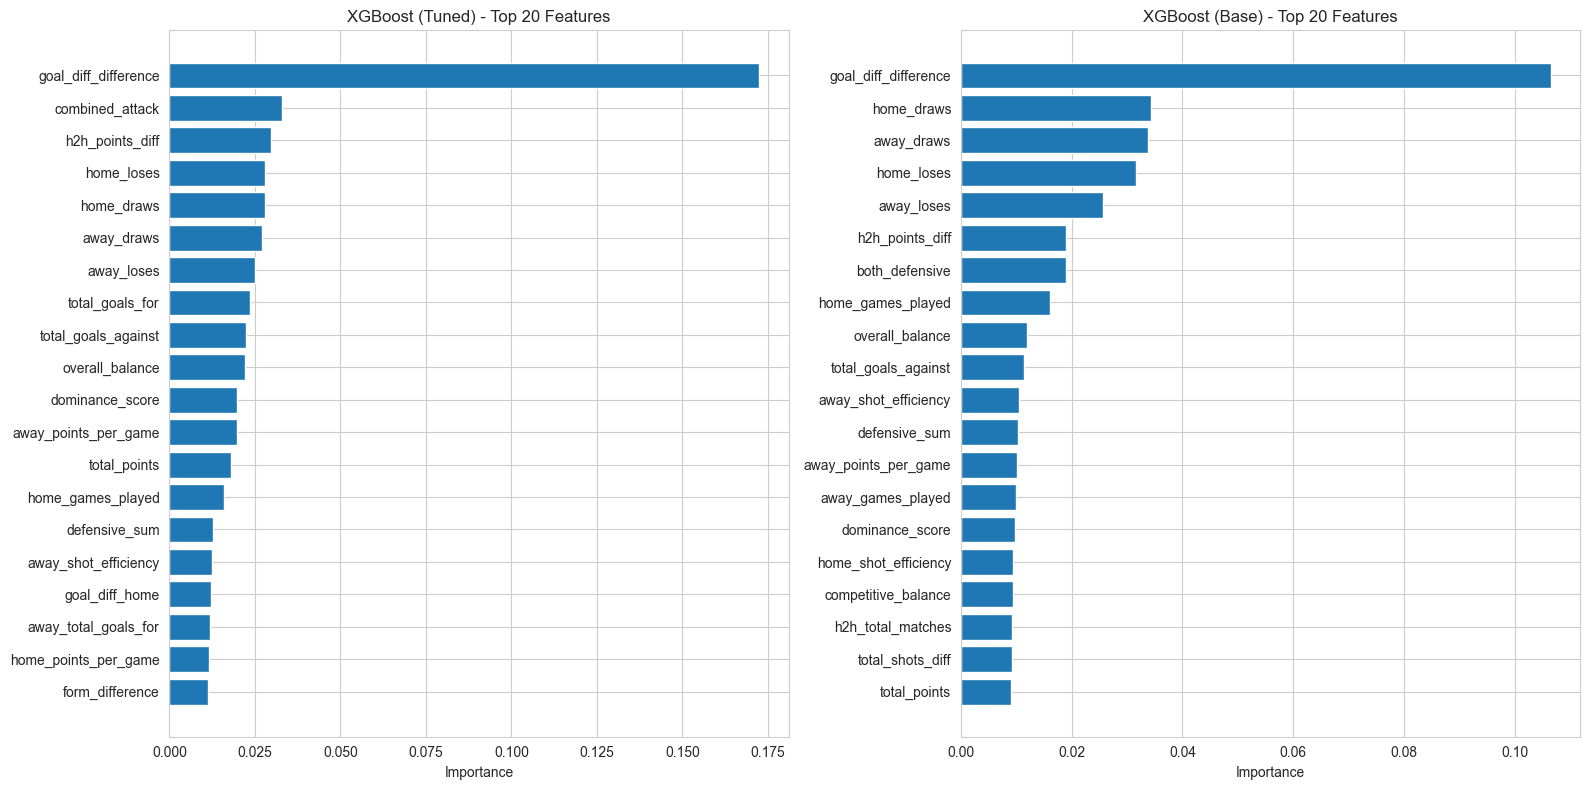

Native feature importance saved

XGBoost (Tuned) - Top 10 Features:
  goal_diff_difference: 0.1724
  combined_attack: 0.0328
  h2h_points_diff: 0.0298
  home_loses: 0.0279
  home_draws: 0.0278
  away_draws: 0.0270
  away_loses: 0.0250
  total_goals_for: 0.0235
  total_goals_against: 0.0224
  overall_balance: 0.0221

XGBoost (Base) - Top 10 Features:
  goal_diff_difference: 0.1064
  home_draws: 0.0343
  away_draws: 0.0338
  home_loses: 0.0316
  away_loses: 0.0256
  h2h_points_diff: 0.0190
  both_defensive: 0.0190
  home_games_played: 0.0160
  overall_balance: 0.0120
  total_goals_against: 0.0114

SHAP Analysis - Global Explainability

Computing SHAP values for tuned model (this may take a few minutes)...


100%|██████████| 100/100 [00:01<00:00, 98.27it/s]


SHAP values computed for tuned model

SHAP values shape: (100, 106, 3)

Generating SHAP summary plot (global feature importance)...


<Figure size 1200x800 with 0 Axes>

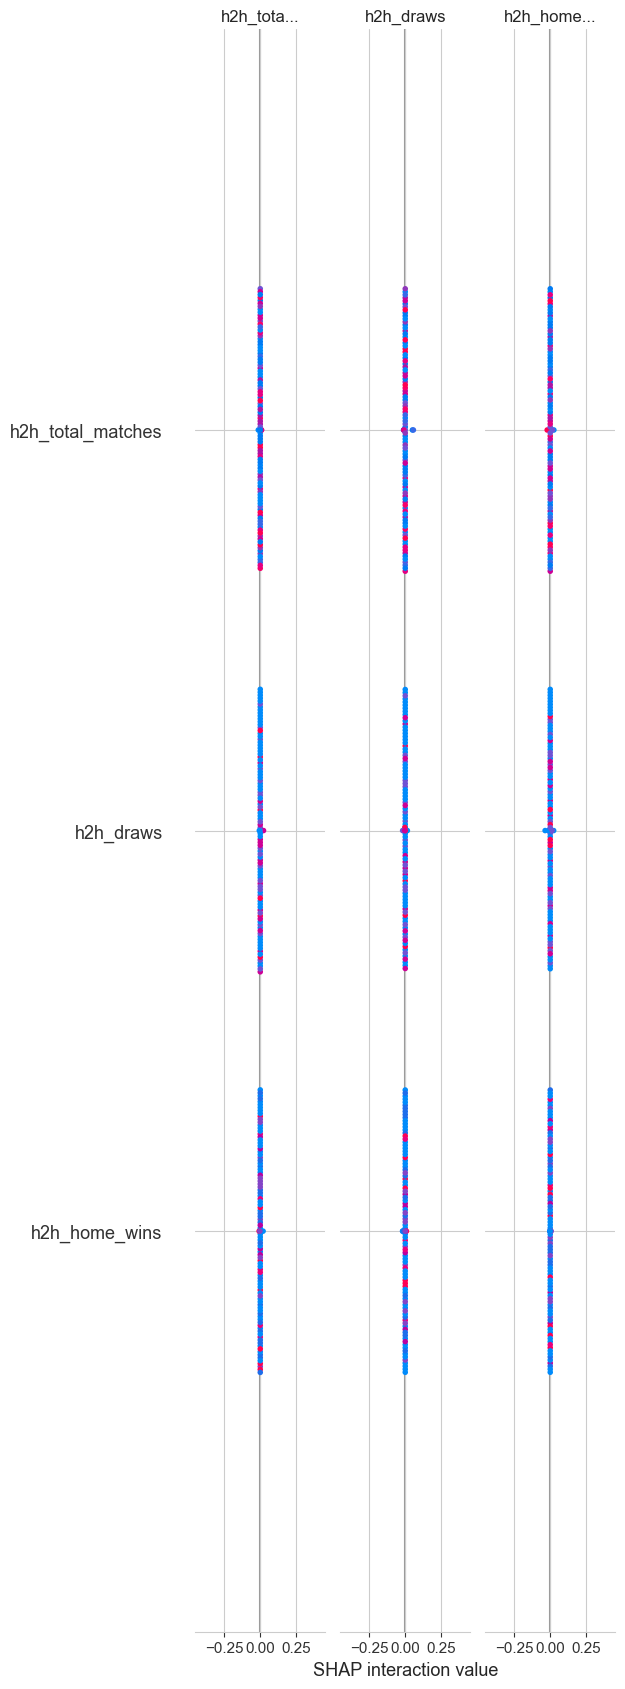

SHAP summary plot saved

Generating SHAP bar plot (mean absolute SHAP values)...
SHAP bar plot saved

Class-specific SHAP Analysis

SHAP analysis for: Home Win
  Top 5 features for Home Win:
    goal_diff_difference: 0.0722
    home_loses: 0.0657
    away_loses: 0.0482
    away_draws: 0.0456
    home_draws: 0.0143

SHAP analysis for: Draw
  Top 5 features for Draw:
    away_draws: 0.0609
    home_draws: 0.0551
    home_loses: 0.0203
    away_loses: 0.0139
    goal_diff_difference: 0.0095

SHAP analysis for: Away Win
  Top 5 features for Away Win:
    away_loses: 0.0706
    goal_diff_difference: 0.0624
    home_loses: 0.0382
    home_draws: 0.0264
    away_shot_efficiency: 0.0073

SHAP Dependence Plots for Top Features

Generating dependence plots for: goal_diff_difference, away_loses, home_loses, away_draws, home_draws, away_shot_efficiency



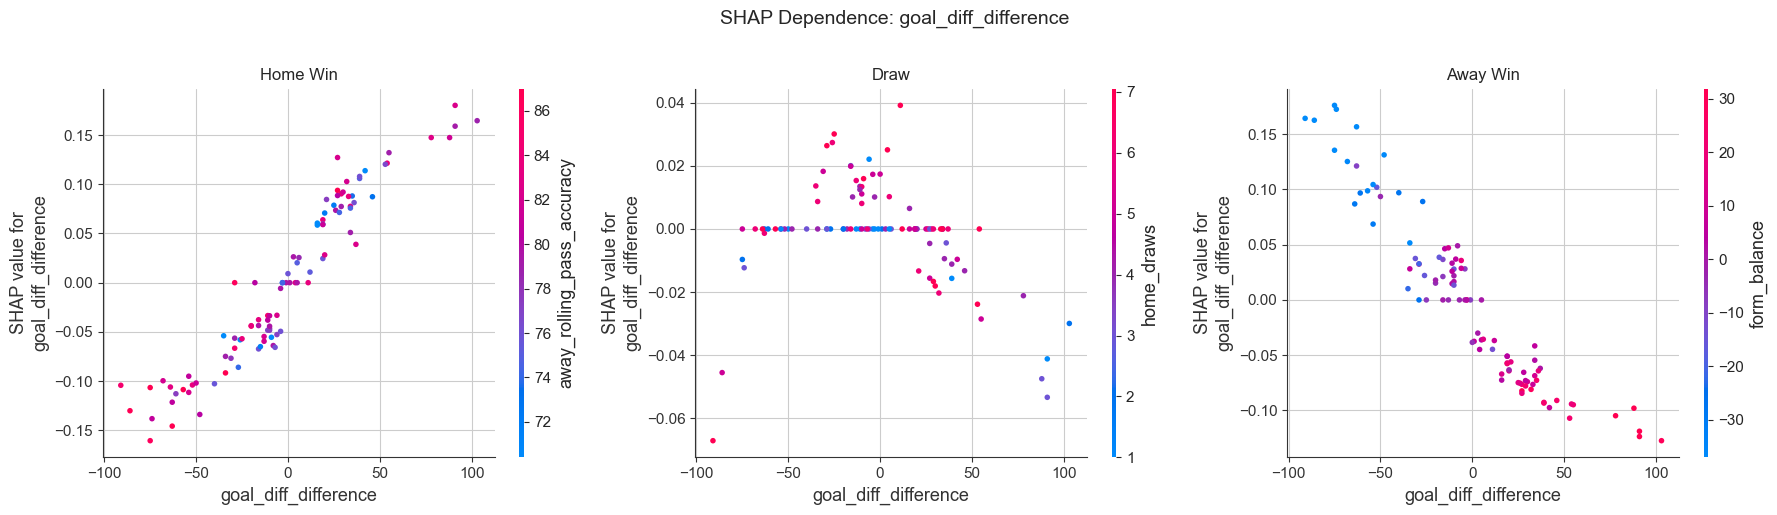

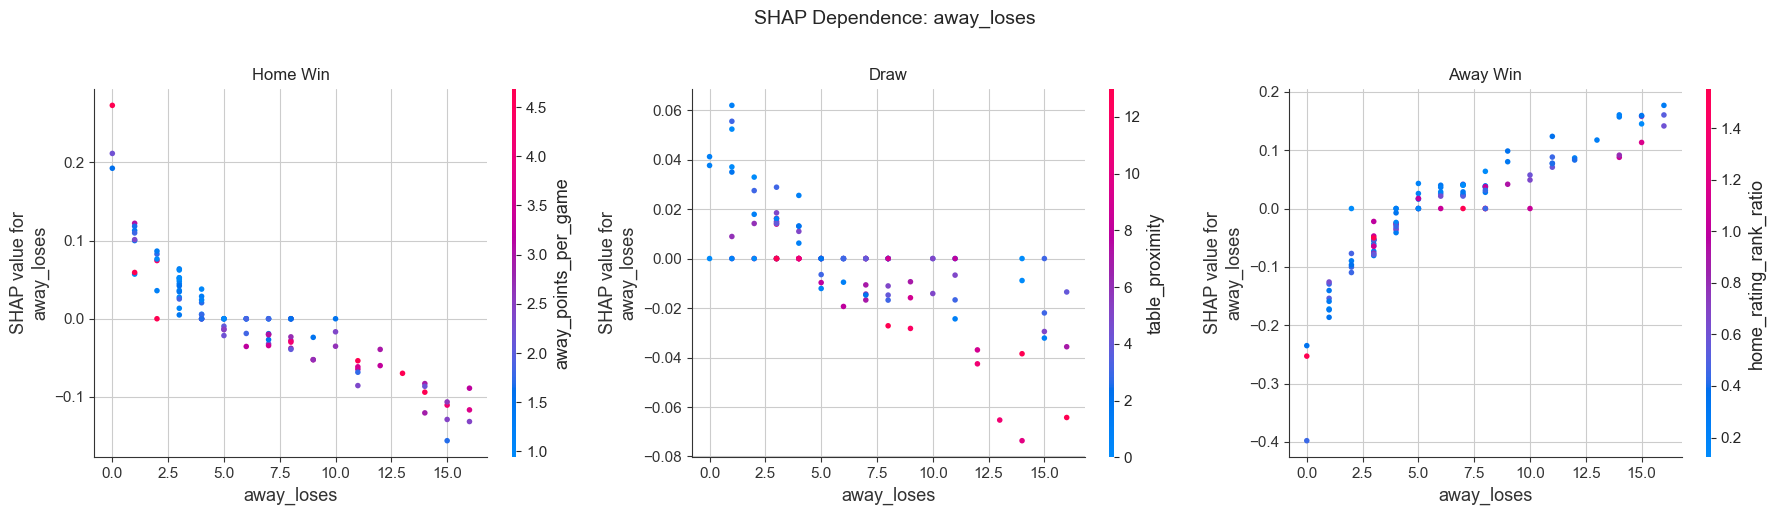

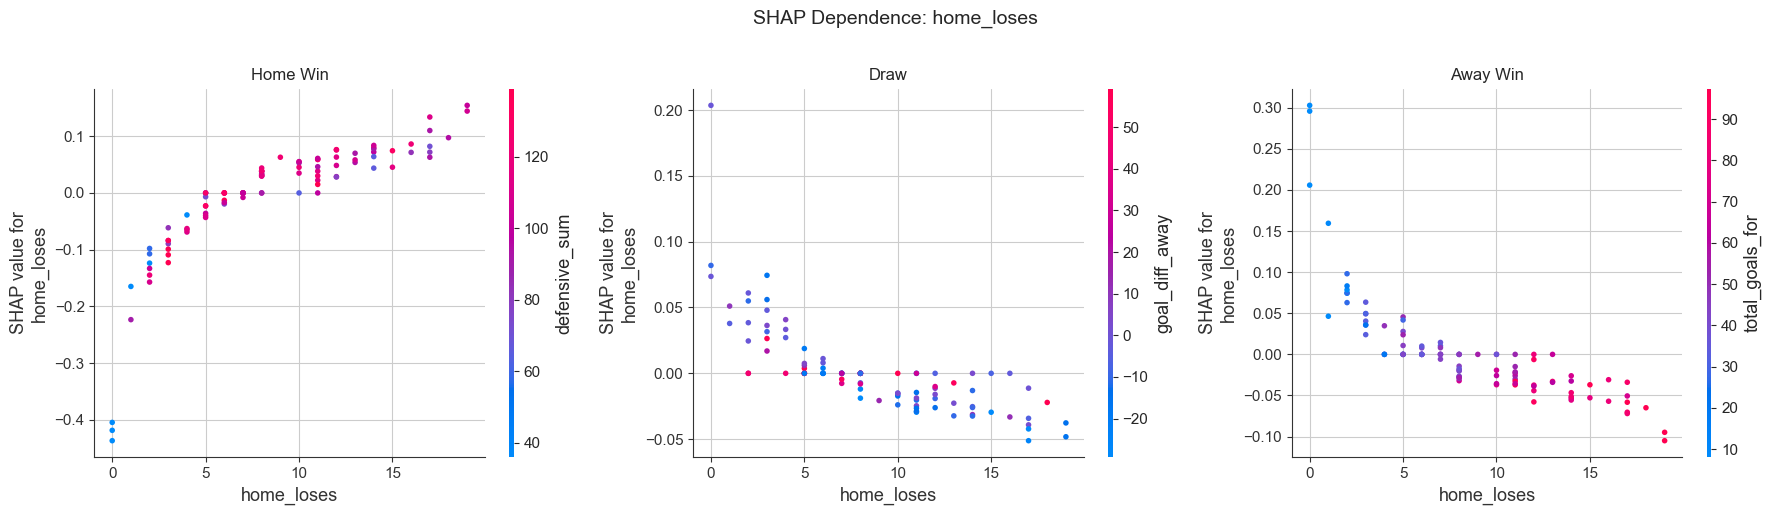

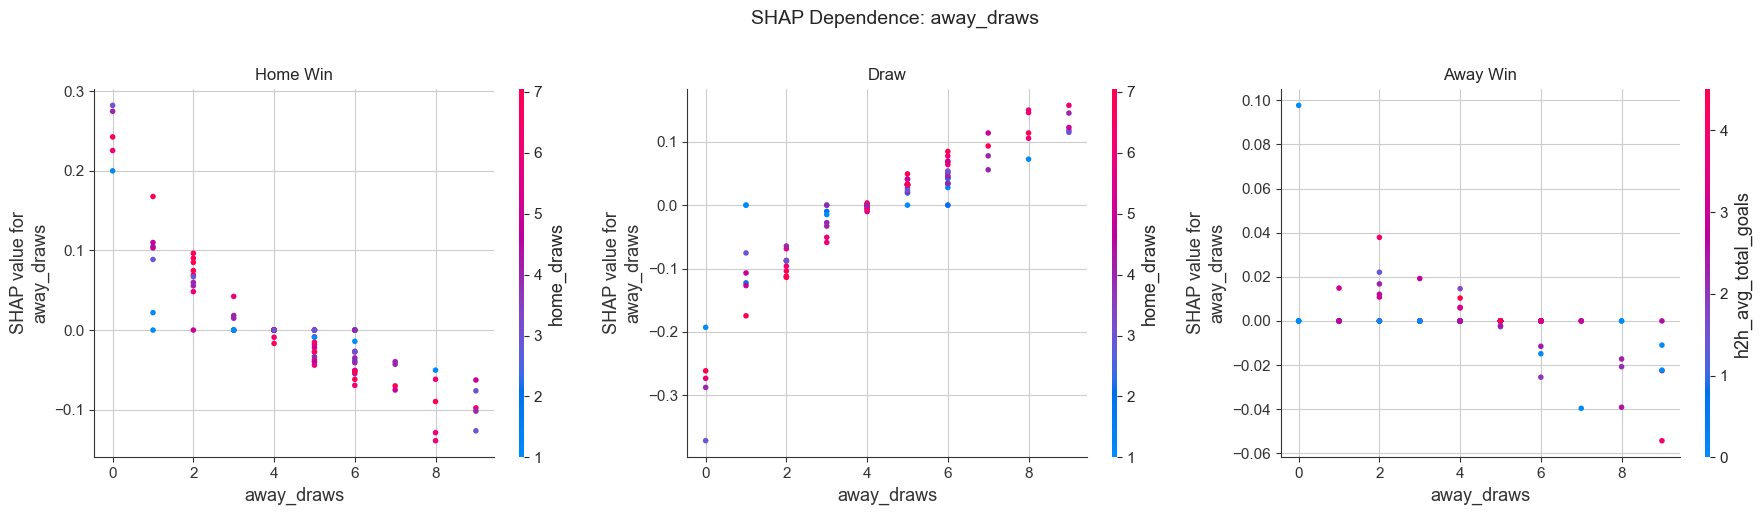

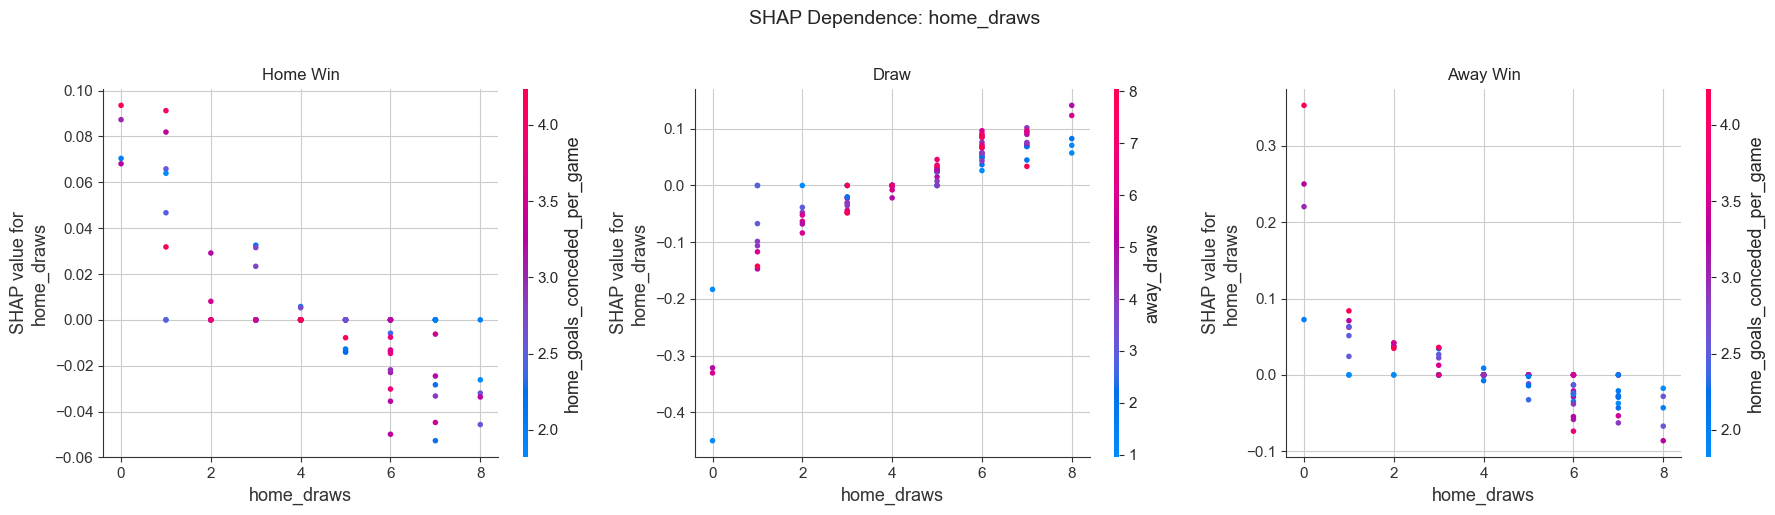

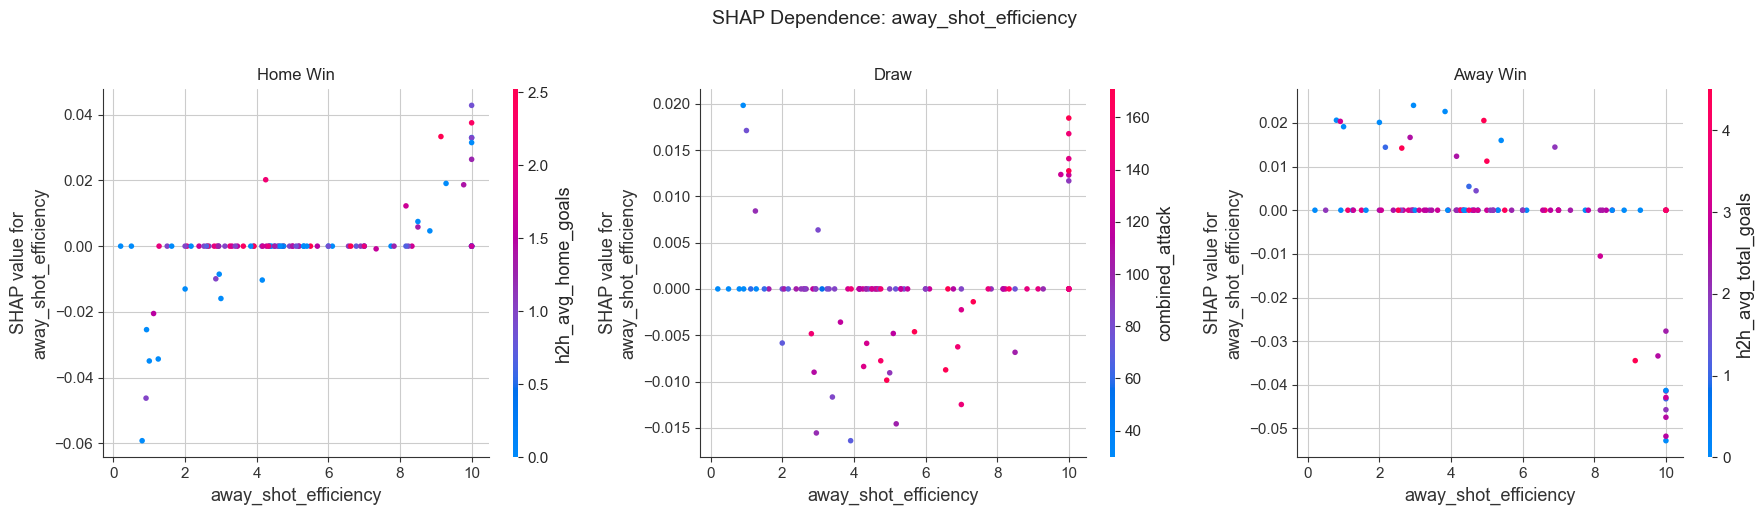

SHAP dependence plots saved

Local Explainability - Individual Predictions

Selecting interesting match scenarios...
Selected 5 interesting cases for local explainability

Generating SHAP Waterfall plots for individual predictions...
Correct High Confidence (Index: 0):
  Actual: Home Win
  Predicted: Home Win
  Probabilities - Home: 0.814, Draw: 0.091, Away: 0.095


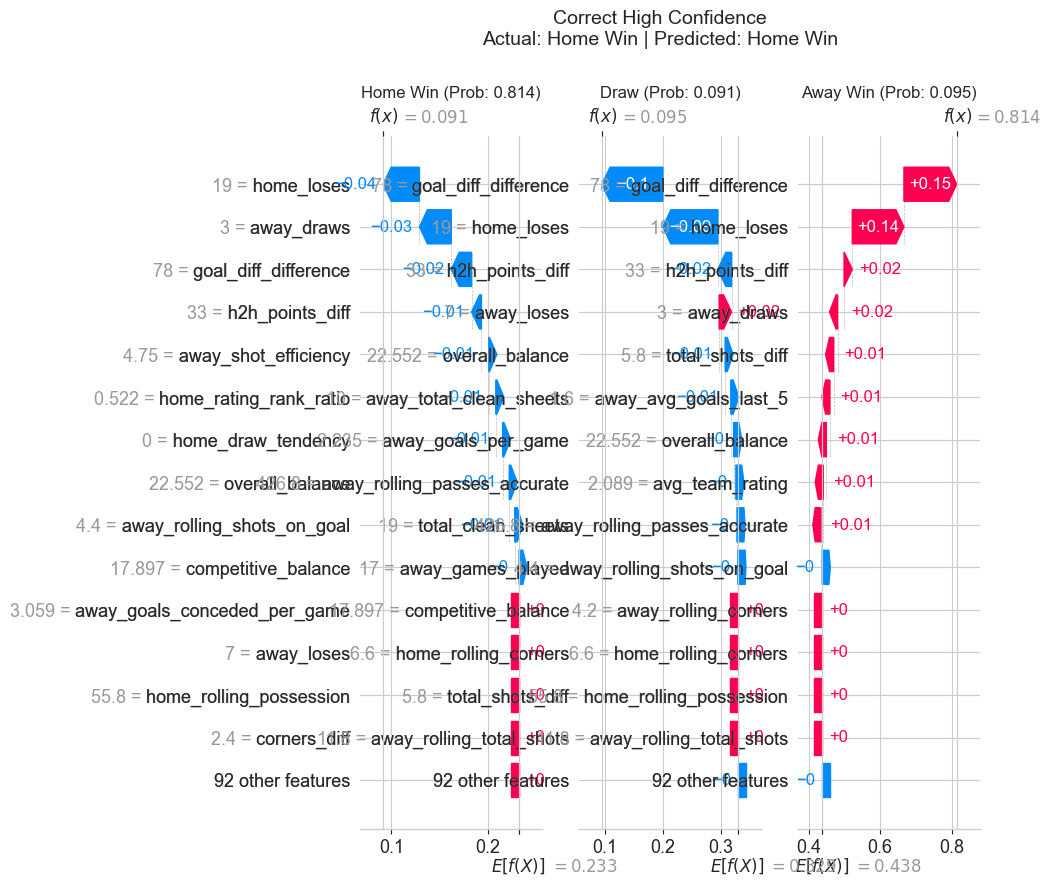


Incorrect High Confidence (Index: 83):
  Actual: Away Win
  Predicted: Home Win
  Probabilities - Home: 0.829, Draw: 0.075, Away: 0.096


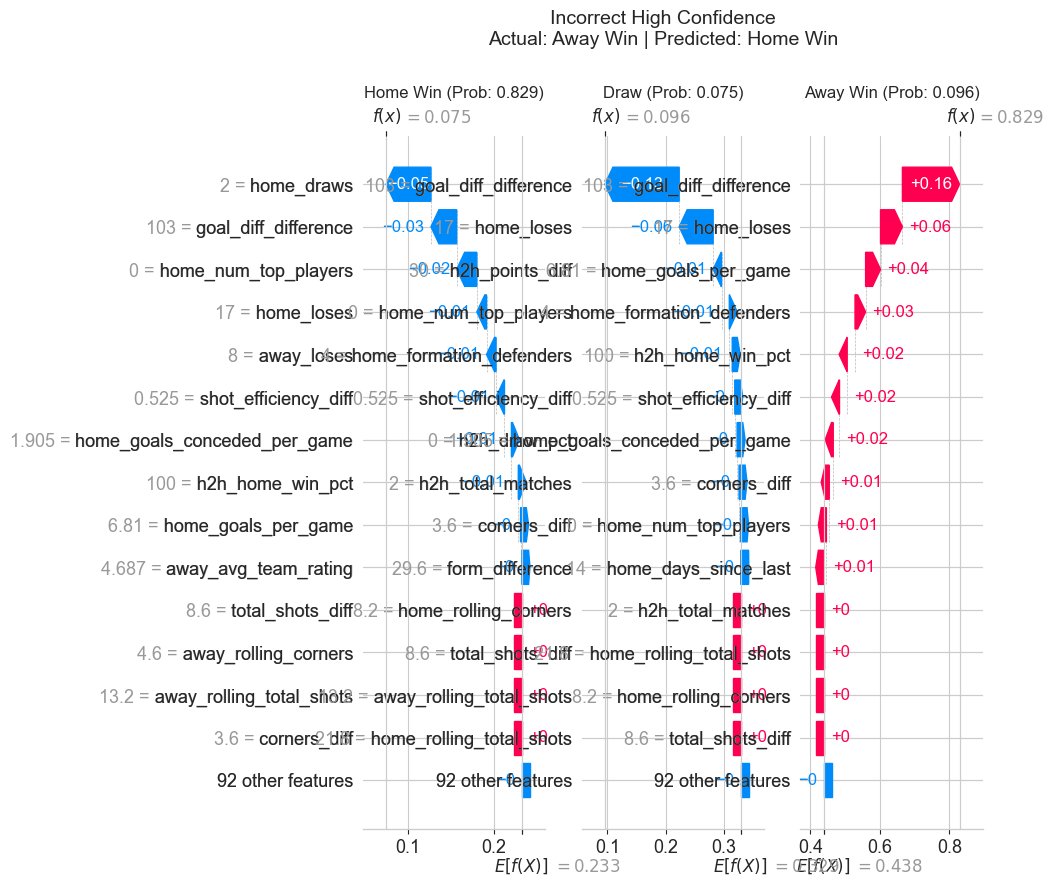


Home Win Prediction (Index: 0):
  Actual: Home Win
  Predicted: Home Win
  Probabilities - Home: 0.814, Draw: 0.091, Away: 0.095


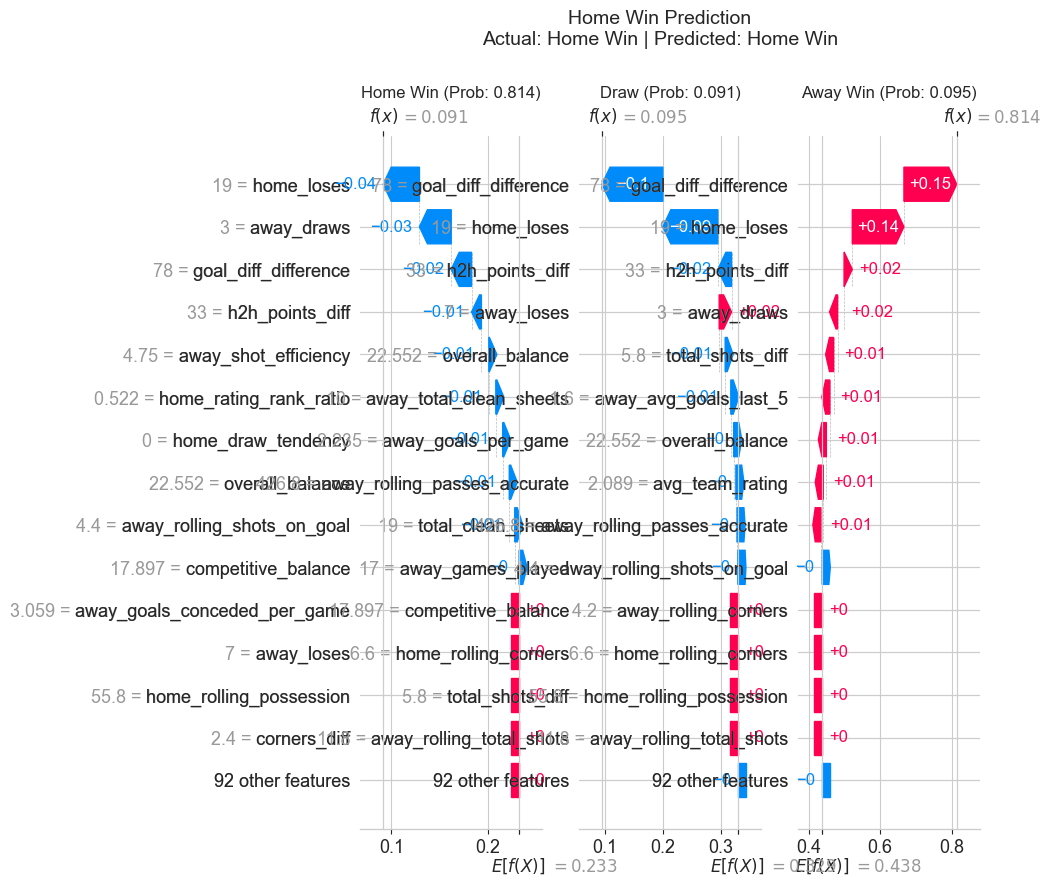


Draw Prediction (Index: 4):
  Actual: Draw
  Predicted: Draw
  Probabilities - Home: 0.237, Draw: 0.424, Away: 0.339


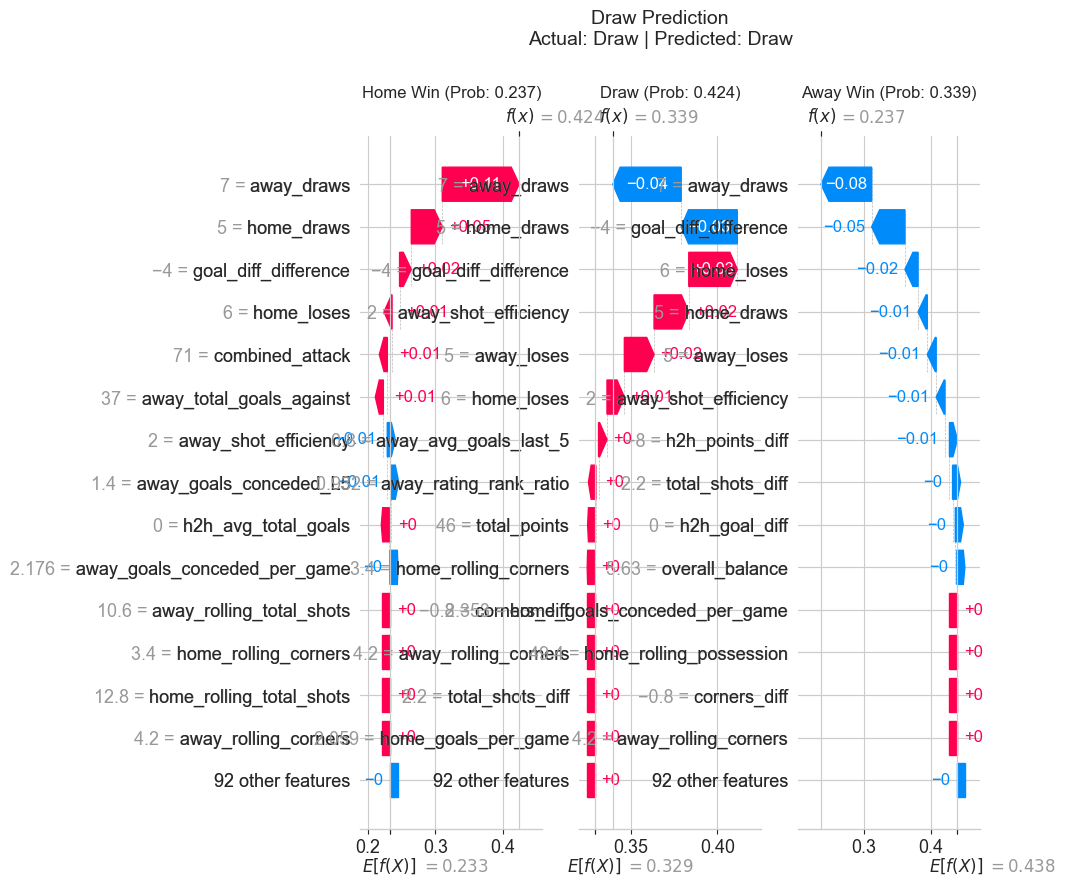


Away Win Prediction (Index: 1):
  Actual: Home Win
  Predicted: Away Win
  Probabilities - Home: 0.251, Draw: 0.287, Away: 0.462


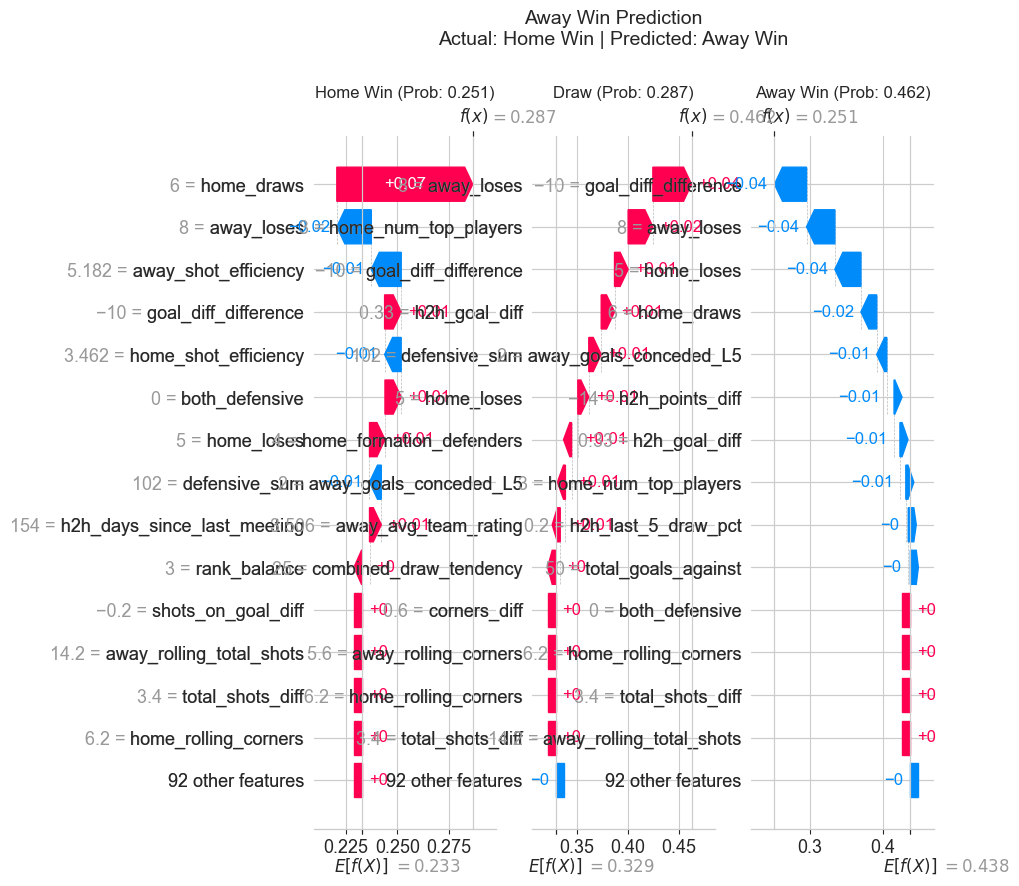


SHAP waterfall plots saved

SHAP Force Plots for Key Predictions

Generating force plot for: Correct High Confidence
Generating force plot for: Incorrect High Confidence
Generating force plot for: Home Win Prediction
SHAP force plots saved

LIME Analysis - Alternative Local Explainability

Initializing LIME explainer...
LIME explainer initialized

Generating LIME explanations for selected cases...
LIME explanation for: Correct High Confidence


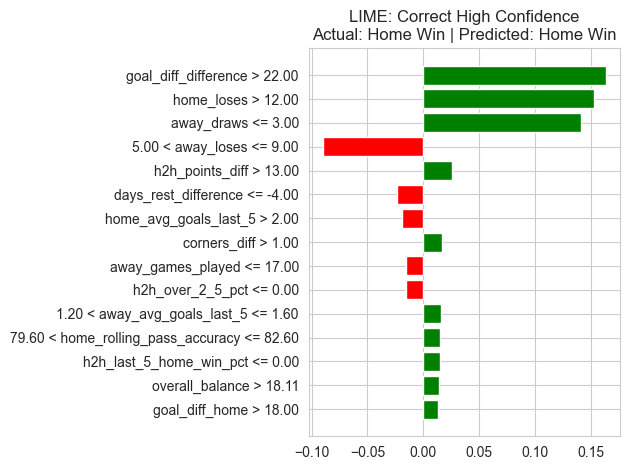

  Saved LIME plot for Correct High Confidence
LIME explanation for: Incorrect High Confidence


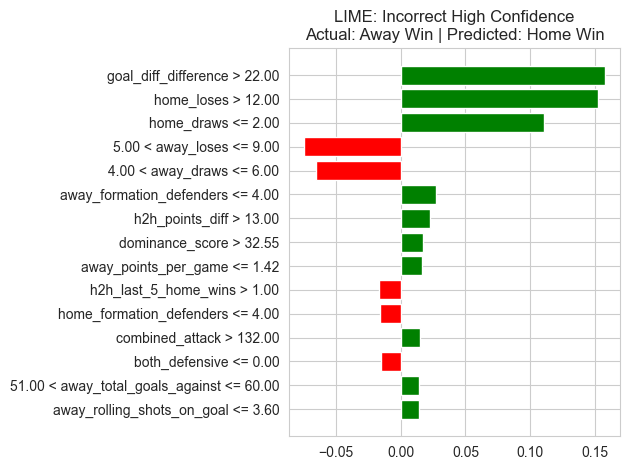

  Saved LIME plot for Incorrect High Confidence
LIME explanation for: Home Win Prediction


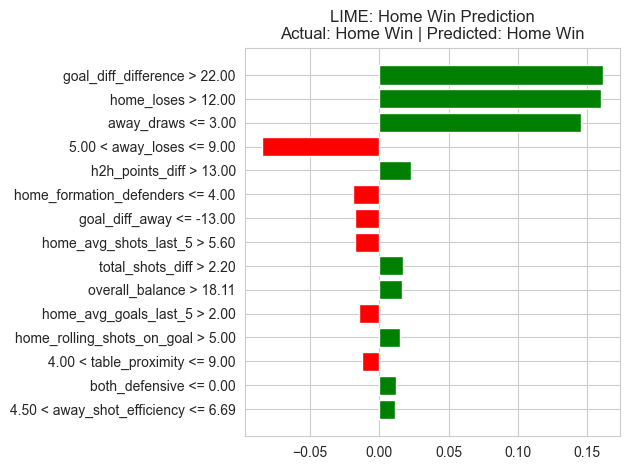

  Saved LIME plot for Home Win Prediction

LIME explanations saved



In [16]:
"""
Model Explainability and Interpretation
Football Match Outcome Prediction
Notebook 06: Explainability Analysis for XGBoost Models
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

import shap
from lime import lime_tabular


print("Model Explainability and Interpretation")
print("Analyzing XGBoost Models: Tuned vs Non-Tuned")
print()


# Define paths
DATA_RAW_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/raw')
PROCESSED_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/processed')
FEATURES_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/data/features')
RESULTS_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results')
FIGURES_PATH = RESULTS_PATH / 'figures' / 'explainability'
TABLES_PATH = RESULTS_PATH / 'tables'
MODEL_PATH = Path('/Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/models')

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
TABLES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Results will be saved to: {FIGURES_PATH}")
print()


print("Loading data and preparing features...")

df = pd.read_csv(FEATURES_PATH / 'df_merged_complete_v2.csv')

features = [
    'h2h_total_matches', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'h2h_home_win_pct',
    'h2h_draw_pct', 'h2h_away_win_pct', 'h2h_avg_home_goals', 'h2h_avg_away_goals', 'h2h_avg_total_goals',
    'h2h_btts_pct', 'h2h_over_2_5_pct', 'h2h_last_5_home_wins', 'h2h_last_5_draws', 'h2h_last_5_away_wins',
    'h2h_days_since_last_meeting', 'avg_team_rating', 'total_points', 'total_goals_for', 'total_goals_against',
    'total_clean_sheets', 'away_avg_team_rating', 'away_total_points', 'away_total_goals_for',
    'away_total_goals_against', 'away_total_clean_sheets', 'h2h_rating_diff', 'h2h_points_diff',
    'h2h_injury_diff', 'home_rating_rank_ratio', 'away_rating_rank_ratio', 'home_points_per_game',
    'away_points_per_game', 'h2h_last_5_home_win_pct', 'h2h_last_5_draw_pct', 'h2h_last_5_away_win_pct',
    'h2h_goal_diff', 'home_avg_goals_last_5', 'home_avg_shots_last_5', 'home_avg_points_last_5',
    'away_avg_goals_last_5', 'away_avg_shots_last_5', 'away_avg_points_last_5', 'home_injury_ratio',
    'away_injury_ratio', 'home_team_experience', 'away_team_experience', 'home_formation_defenders',
    'away_formation_defenders', 'home_num_top_players', 'away_num_top_players', 'home_games_played',
    'away_games_played', 'home_draws', 'away_draws', 'home_loses', 'away_loses', 'home_goals_per_game',
    'away_goals_per_game', 'home_goals_conceded_per_game', 'away_goals_conceded_per_game',
    'goal_diff_home', 'goal_diff_away', 'goal_diff_difference', 'home_goals_conceded_L5',
    'away_goals_conceded_L5', 'form_difference', 'home_rolling_shots_on_goal', 'away_rolling_shots_on_goal',
    'shots_on_goal_diff', 'home_rolling_total_shots', 'away_rolling_total_shots', 'total_shots_diff',
    'home_rolling_corners', 'away_rolling_corners', 'corners_diff', 'home_rolling_possession',
    'away_rolling_possession', 'possession_diff', 'home_rolling_passes_accurate', 'away_rolling_passes_accurate',
    'home_rolling_pass_accuracy', 'away_rolling_pass_accuracy', 'pass_accuracy_diff', 'home_shot_efficiency',
    'away_shot_efficiency', 'shot_efficiency_diff', 'home_days_since_last', 'away_days_since_last',
    'days_rest_difference', 'table_proximity', 'is_close_match', 'league_home_advantage', 'league_avg_goals',
    'competitive_balance', 'rank_balance', 'form_balance', 'overall_balance', 'both_defensive',
    'defensive_sum', 'combined_attack', 'low_scoring_likelihood', 'home_draw_tendency', 'away_draw_tendency',
    'combined_draw_tendency', 'dominance_score'
]
target = 'target'

X = df[features].select_dtypes(include=[np.number]).copy()
y = df[target].copy()

if y.isna().any():
    mask = y.notna()
    X = X.loc[mask, :]
    y = y.loc[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

feature_names = X.columns.tolist()

print(f"Data shape: {X.shape}")
print(f"Train/Test split: {X_train.shape[0]}/{X_test.shape[0]}")
print(f"Number of features: {len(feature_names)}")
print()


print("Loading models...")

# Load non-tuned models
non_tuned_models = {}
for model_name in ['LogisticRegression', 'RandomForest', 'MLPClassifier', 'XGBoost', 'LightGBM']:
    model_file = MODEL_PATH / f"{model_name}.pkl"
    try:
        with open(model_file, "rb") as f:
            non_tuned_models[model_name] = pickle.load(f)
        print(f"Non-tuned {model_name} loaded successfully.")
    except FileNotFoundError:
        print(f"Non-tuned {model_name} not found at: {model_file}.")

# Load tuned models
tuned_models = {}
for model_name in ['LogisticRegression', 'RandomForest', 'MLPClassifier', 'XGBoost', 'LightGBM']:
    model_file = MODEL_PATH / f"{model_name}_tuned.pkl"
    try:
        with open(model_file, "rb") as f:
            tuned_models[model_name] = pickle.load(f)
        print(f"Tuned {model_name} loaded successfully.")
    except FileNotFoundError:
        print(f"Tuned {model_name} not found at: {model_file}")

# Define best models
xgboost_base = non_tuned_models['XGBoost']
xgboost_tuned = tuned_models['XGBoost']

print("XGBoost Tuned model loaded")
print("XGBoost Base model loaded")
print()


print("Model Performance Comparison")
print()

models = {
    'XGBoost (Tuned)': xgboost_tuned,
    'XGBoost (Base)': xgboost_base
}

performance_results = []

for name, model in models.items():
    y_pred_train = model.predict(X_train_imputed)
    y_pred_test = model.predict(X_test_imputed)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
    
    performance_results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"{name}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print()

performance_df = pd.DataFrame(performance_results)
performance_df.to_csv(TABLES_PATH / 'explainability_model_performance_xgboost.csv', index=False)

print("Performance comparison saved")
print()


print("Detailed Classification Reports")
print()

class_names = ['Home Win', 'Draw', 'Away Win']

for name, model in models.items():
    y_pred = model.predict(X_test_imputed)
    print(f"{name}:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    print()


print("Confusion Matrices")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_imputed)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'confusion_matrices_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved")
print()


print("Feature Importance Analysis")
print()

print("Native XGBoost Feature Importance")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, (name, model) in enumerate(models.items()):
    importance = model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    top_20 = importance_df.head(20)
    
    axes[idx].barh(range(len(top_20)), top_20['Importance'])
    axes[idx].set_yticks(range(len(top_20)))
    axes[idx].set_yticklabels(top_20['Feature'])
    axes[idx].set_xlabel('Importance')
    axes[idx].set_title(f'{name} - Top 20 Features')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'feature_importance_native_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

print("Native feature importance saved")
print()

for name, model in models.items():
    importance = model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    csv_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    importance_df.to_csv(TABLES_PATH / f'feature_importance_{csv_name}.csv', index=False)
    
    print(f"{name} - Top 10 Features:")
    for i, row in importance_df.head(10).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
    print()


print("SHAP Analysis - Global Explainability")
print()

print("Computing SHAP values for tuned model (this may take a few minutes)...")

# Use a smaller sample to reduce memory usage and debug issues
sample_size = min(100, len(X_test_imputed))
X_test_sample = X_test_imputed[:sample_size]

try:
    # Create a custom predictor to handle multi-class output
    def xgboost_predict_proba(data):
        return xgboost_tuned.predict_proba(data)
    
    # Initialize SHAP Explainer with the predict_proba function
    explainer_tuned = shap.KernelExplainer(xgboost_predict_proba, X_test_sample)
    shap_values_tuned = explainer_tuned.shap_values(X_test_sample, nsamples=100)  # Limit samples for speed
except Exception as e:
    print(f"Error computing SHAP values: {e}")
    print("Falling back to an even smaller sample...")
    X_test_sample = X_test_imputed[:50]
    explainer_tuned = shap.KernelExplainer(xgboost_predict_proba, X_test_sample)
    shap_values_tuned = explainer_tuned.shap_values(X_test_sample, nsamples=50)

print("SHAP values computed for tuned model")
print()

if isinstance(shap_values_tuned, list):
    shap_values_array = np.array(shap_values_tuned)
else:
    shap_values_array = shap_values_tuned

print(f"SHAP values shape: {shap_values_array.shape}")
print()


print("Generating SHAP summary plot (global feature importance)...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_tuned, X_test_sample, feature_names=feature_names, 
                  class_names=class_names, show=False, max_display=20)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'shap_summary_plot_tuned_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

print("SHAP summary plot saved")
print()


print("Generating SHAP bar plot (mean absolute SHAP values)...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_tuned, X_test_sample, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=20, class_names=class_names)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'shap_bar_plot_tuned_xgboost.png', dpi=300, bbox_inches='tight')
plt.close()

print("SHAP bar plot saved")
print()


print("Class-specific SHAP Analysis")
print()

for class_idx, class_name in enumerate(class_names):
    print(f"SHAP analysis for: {class_name}")
    
    if isinstance(shap_values_tuned, list):
        shap_class = shap_values_tuned[class_idx]
    else:
        shap_class = shap_values_tuned[:, :, class_idx]
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_class, X_test_sample, feature_names=feature_names,
                      show=False, max_display=20)
    plt.title(f'SHAP Summary - {class_name}')
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / f'shap_summary_{class_name.lower().replace(" ", "_")}_xgboost.png', 
                dpi=300, bbox_inches='tight')
    plt.close()
    
    mean_abs_shap = np.abs(shap_class).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values('Mean_Abs_SHAP', ascending=False)
    
    shap_importance_df.to_csv(TABLES_PATH / f'shap_importance_{class_name.lower().replace(" ", "_")}_xgboost.csv', 
                              index=False)
    
    print(f"  Top 5 features for {class_name}:")
    for i, row in shap_importance_df.head(5).iterrows():
        print(f"    {row['Feature']}: {row['Mean_Abs_SHAP']:.4f}")
    print()


print("SHAP Dependence Plots for Top Features")
print()

if isinstance(shap_values_tuned, list):
    overall_importance = np.abs(np.array(shap_values_tuned)).mean(axis=(0, 1))
else:
    overall_importance = np.abs(shap_values_tuned).mean(axis=(0, 2))

top_features_idx = overall_importance.argsort()[-6:][::-1]
top_features = [feature_names[i] for i in top_features_idx]

print(f"Generating dependence plots for: {', '.join(top_features)}")
print()

for feat_idx, feat_name in zip(top_features_idx, top_features):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for class_idx, class_name in enumerate(class_names):
        if isinstance(shap_values_tuned, list):
            shap_class = shap_values_tuned[class_idx]
        else:
            shap_class = shap_values_tuned[:, :, class_idx]
        
        shap.dependence_plot(feat_idx, shap_class, X_test_sample,
                            feature_names=feature_names,
                            ax=axes[class_idx], show=False)
        axes[class_idx].set_title(f'{class_name}')
    
    fig.suptitle(f'SHAP Dependence: {feat_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / f'shap_dependence_{feat_name.lower().replace(" ", "_")}_xgboost.png',
                dpi=300, bbox_inches='tight')
    plt.show()

print("SHAP dependence plots saved")
print()


print("Local Explainability - Individual Predictions")
print()

print("Selecting interesting match scenarios...")

y_pred_test = xgboost_tuned.predict(X_test_imputed)
y_pred_proba_test = xgboost_tuned.predict_proba(X_test_imputed)

correct_predictions = np.where(y_pred_test == y_test)[0]
incorrect_predictions = np.where(y_pred_test != y_test)[0]

high_confidence_correct = []
for idx in correct_predictions:
    max_prob = y_pred_proba_test[idx].max()
    if max_prob > 0.8:
        high_confidence_correct.append((idx, max_prob))

high_confidence_incorrect = []
for idx in incorrect_predictions:
    max_prob = y_pred_proba_test[idx].max()
    if max_prob > 0.7:
        high_confidence_incorrect.append((idx, max_prob))

selected_indices = []

if high_confidence_correct:
    selected_indices.append(('Correct High Confidence', high_confidence_correct[0][0]))

if high_confidence_incorrect:
    selected_indices.append(('Incorrect High Confidence', high_confidence_incorrect[0][0]))

home_win_pred = np.where(y_pred_test == 0)[0]
if len(home_win_pred) > 0:
    selected_indices.append(('Home Win Prediction', home_win_pred[0]))

draw_pred = np.where(y_pred_test == 1)[0]
if len(draw_pred) > 0:
    selected_indices.append(('Draw Prediction', draw_pred[0]))

away_win_pred = np.where(y_pred_test == 2)[0]
if len(away_win_pred) > 0:
    selected_indices.append(('Away Win Prediction', away_win_pred[0]))

print(f"Selected {len(selected_indices)} interesting cases for local explainability")
print()


print("Generating SHAP Waterfall plots for individual predictions...")

for scenario_name, idx in selected_indices:
    actual = class_names[int(y_test.iloc[idx])]
    predicted = class_names[y_pred_test[idx]]
    probas = y_pred_proba_test[idx]
    
    print(f"{scenario_name} (Index: {idx}):")
    print(f"  Actual: {actual}")
    print(f"  Predicted: {predicted}")
    print(f"  Probabilities - Home: {probas[0]:.3f}, Draw: {probas[1]:.3f}, Away: {probas[2]:.3f}")
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for class_idx, class_name in enumerate(class_names):
        if isinstance(shap_values_tuned, list):
            shap_class = shap_values_tuned[class_idx]
        else:
            shap_class = shap_values_tuned[:, :, class_idx]
        
        # Ensure idx is within bounds of the sampled data
        sample_idx = min(idx, len(X_test_sample) - 1)
        
        explanation = shap.Explanation(
            values=shap_class[sample_idx],
            base_values=explainer_tuned.expected_value[class_idx] if isinstance(explainer_tuned.expected_value, (list, np.ndarray)) else explainer_tuned.expected_value,
            data=X_test_sample[sample_idx],
            feature_names=feature_names
        )
        
        shap.plots.waterfall(explanation, max_display=15, show=False)
        axes[class_idx].set_title(f'{class_name} (Prob: {probas[class_idx]:.3f})')
        plt.sca(axes[class_idx])
    
    fig.suptitle(f'{scenario_name}\nActual: {actual} | Predicted: {predicted}', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    
    filename = scenario_name.lower().replace(' ', '_')
    plt.savefig(FIGURES_PATH / f'shap_waterfall_{filename}_xgboost.png', dpi=300, bbox_inches='tight')
    plt.show()
    print()

print("SHAP waterfall plots saved")
print()


print("SHAP Force Plots for Key Predictions")
print()

for scenario_name, idx in selected_indices[:3]:
    actual = class_names[int(y_test.iloc[idx])]
    predicted = class_names[y_pred_test[idx]]
    
    print(f"Generating force plot for: {scenario_name}")
    
    predicted_class_idx = y_pred_test[idx]
    
    if isinstance(shap_values_tuned, list):
        shap_vals = shap_values_tuned[predicted_class_idx][min(idx, len(X_test_sample) - 1)]
        base_val = explainer_tuned.expected_value[predicted_class_idx]
    else:
        shap_vals = shap_values_tuned[min(idx, len(X_test_sample) - 1), :, predicted_class_idx]
        base_val = explainer_tuned.expected_value[predicted_class_idx] if isinstance(explainer_tuned.expected_value, (list, np.ndarray)) else explainer_tuned.expected_value
    
    fig = shap.force_plot(
        base_val,
        shap_vals,
        X_test_sample[min(idx, len(X_test_sample) - 1)],
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    
    plt.title(f'{scenario_name} - {predicted}\nActual: {actual} | Predicted: {predicted}')
    plt.tight_layout()
    
    filename = scenario_name.lower().replace(' ', '_')
    plt.savefig(FIGURES_PATH / f'shap_force_{filename}_xgboost.png', dpi=300, bbox_inches='tight')
    plt.close()

print("SHAP force plots saved")
print()


print("LIME Analysis - Alternative Local Explainability")
print()

print("Initializing LIME explainer...")

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_imputed,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42
)

print("LIME explainer initialized")
print()

print("Generating LIME explanations for selected cases...")

for scenario_name, idx in selected_indices[:3]:
    actual = class_names[int(y_test.iloc[idx])]
    predicted = class_names[y_pred_test[idx]]
    
    print(f"LIME explanation for: {scenario_name}")
    
    lime_exp = lime_explainer.explain_instance(
        data_row=X_test_imputed[idx],
        predict_fn=xgboost_tuned.predict_proba,
        num_features=15,
        top_labels=3
    )
    
    fig = lime_exp.as_pyplot_figure(label=y_pred_test[idx])
    plt.title(f'LIME: {scenario_name}\nActual: {actual} | Predicted: {predicted}')
    plt.tight_layout()
    
    filename = scenario_name.lower().replace(' ', '_')
    plt.savefig(FIGURES_PATH / f'lime_{filename}_xgboost.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  Saved LIME plot for {scenario_name}")

print()
print("LIME explanations saved")
print()



Feature Interaction Analysis

Computing SHAP interaction approximations (this may take several minutes)...


100%|██████████| 500/500 [00:03<00:00, 147.56it/s]


SHAP values computed for 500 samples

Analyzing top feature interactions...
Top interactions for: Home Win
  Top 5 feature interactions:
    home_rating_rank_ratio <-> away_goals_conceded_L5: 1.0000
    home_formation_defenders <-> away_goals_conceded_L5: 1.0000
    away_goals_conceded_L5 <-> home_rolling_total_shots: 1.0000
    home_goals_conceded_L5 <-> home_days_since_last: 1.0000
    home_formation_defenders <-> home_rolling_total_shots: 1.0000

Top interactions for: Draw
  Top 5 feature interactions:
    h2h_draws <-> h2h_home_win_pct: 1.0000
    h2h_draw_pct <-> home_goals_per_game: 0.9004
    h2h_draw_pct <-> home_rolling_corners: 0.8705
    home_goals_per_game <-> home_rolling_corners: 0.8498
    h2h_draw_pct <-> days_rest_difference: 0.8374

Top interactions for: Away Win
  Top 5 feature interactions:
    h2h_days_since_last_meeting <-> away_avg_goals_last_5: 1.0000
    h2h_goal_diff <-> away_avg_shots_last_5: 1.0000
    h2h_avg_away_goals <-> away_avg_shots_last_5: 1.0000
   

100%|██████████| 500/500 [00:03<00:00, 139.14it/s]


SHAP values computed for base model



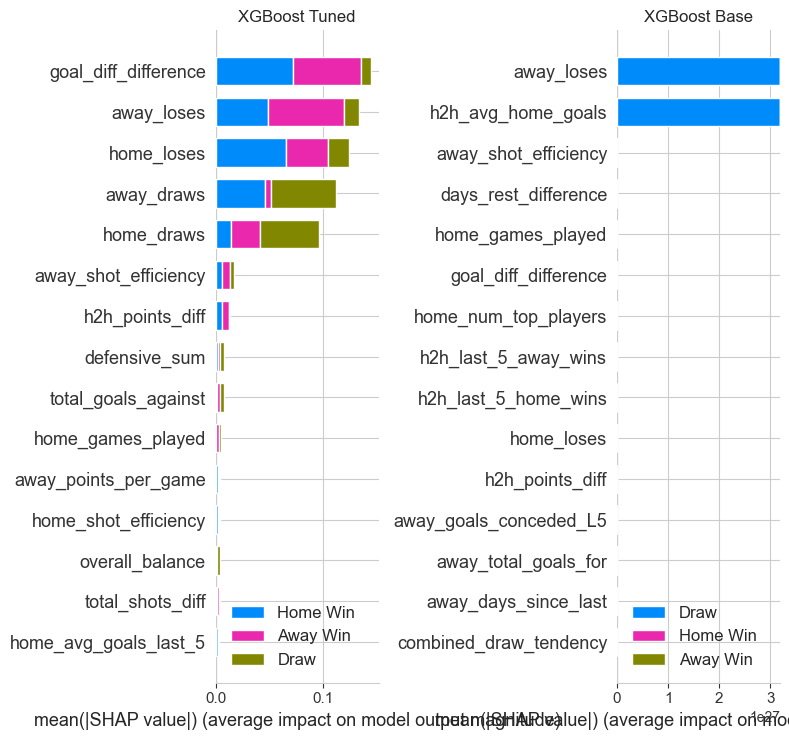

Model comparison plot saved

Key Football Insights Summary

Top 10 Most Important Features (SHAP):
  goal_diff_difference: 0.0480
  away_loses: 0.0443
  home_loses: 0.0414
  away_draws: 0.0373
  home_draws: 0.0319
  away_shot_efficiency: 0.0055
  h2h_points_diff: 0.0045
  defensive_sum: 0.0026
  total_goals_against: 0.0026
  home_games_played: 0.0016

Feature Category Distribution in Top 10:
  Home team features: 3
  Away team features: 3
  Head-to-head features: 1
  Other features: 3

Insights summary saved

Explainability Analysis Complete

Summary of Generated Outputs:

Figures saved:
  /Users/vishalchaudhary/Desktop/Football_Project_Final/DOMAIN_APPLICATIONS_PROJECT/results/figures/explainability
  - confusion_matrices_xgboost.png
  - feature_importance_native_xgboost.png
  - shap_summary_plot_tuned_xgboost.png
  - shap_bar_plot_tuned_xgboost.png
  - shap_summary_[class]_xgboost.png (3 files)
  - shap_dependence_[feature]_xgboost.png (6 files)
  - shap_waterfall_[scenario]_xgboost.

In [17]:
print("Feature Interaction Analysis")
print()

print("Computing SHAP interaction approximations (this may take several minutes)...")

# Summarize background data using k-means clustering
sample_size = min(500, len(X_test_imputed))
X_sample = X_test_imputed[:sample_size]
background_summary = shap.kmeans(X_sample, 50)  # Summarize to 50 samples

try:
    # Use KernelExplainer to compute SHAP values
    def xgboost_predict_proba(data):
        return xgboost_tuned.predict_proba(data)
    
    explainer_interaction = shap.KernelExplainer(xgboost_predict_proba, background_summary)
    shap_values_interaction = explainer_interaction.shap_values(X_sample, nsamples=50)
except Exception as e:
    print(f"Error computing SHAP values: {e}")
    print("Falling back to a smaller sample...")
    X_sample = X_test_imputed[:100]
    background_summary = shap.kmeans(X_sample, 25)
    explainer_interaction = shap.KernelExplainer(xgboost_predict_proba, background_summary)
    shap_values_interaction = explainer_interaction.shap_values(X_sample, nsamples=25)

print(f"SHAP values computed for {sample_size} samples")
print()

print("Analyzing top feature interactions...")

for class_idx, class_name in enumerate(class_names):
    print(f"Top interactions for: {class_name}")
    
    # Extract SHAP values for the current class
    if isinstance(shap_values_interaction, list):
        class_shap_values = shap_values_interaction[class_idx]
    else:
        class_shap_values = shap_values_interaction[:, :, class_idx]
    
    # Approximate interactions by computing correlation of SHAP values between features
    # Convert SHAP values to a DataFrame for correlation analysis
    shap_df = pd.DataFrame(class_shap_values, columns=feature_names)
    correlation_matrix = shap_df.corr().abs()
    
    # Ensure correlation_matrix is 2D
    if correlation_matrix.ndim != 2:
        print(f"Error: Correlation matrix for {class_name} is not 2D")
        continue
    
    # Set diagonal to zero (no self-interactions)
    np.fill_diagonal(correlation_matrix.values, 0)
    
    # Create interaction pairs
    interaction_pairs = []
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            interaction_pairs.append({
                'Feature_1': feature_names[i],
                'Feature_2': feature_names[j],
                'Interaction_Strength': correlation_matrix.iloc[i, j]
            })
    
    interaction_df = pd.DataFrame(interaction_pairs).sort_values(
        'Interaction_Strength', ascending=False
    )
    
    interaction_df.to_csv(
        TABLES_PATH / f'feature_interactions_{class_name.lower().replace(" ", "_")}_xgboost.csv',
        index=False
    )
    
    print(f"  Top 5 feature interactions:")
    for i, row in interaction_df.head(5).iterrows():
        print(f"    {row['Feature_1']} <-> {row['Feature_2']}: {row['Interaction_Strength']:.4f}")
    print()

print("Feature interaction analysis complete")
print()


print("Model Comparison: Tuned vs Base")
print()

print("Computing SHAP values for base model...")

explainer_base = shap.KernelExplainer(xgboost_base.predict_proba, background_summary)
shap_values_base = explainer_base.shap_values(X_sample, nsamples=50)

print("SHAP values computed for base model")
print()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plt.sca(axes[0])
shap.summary_plot(shap_values_tuned, X_sample, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15, class_names=class_names)
axes[0].set_title('XGBoost Tuned')

plt.sca(axes[1])
shap.summary_plot(shap_values_base, X_sample, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15, class_names=class_names)
axes[1].set_title('XGBoost Base')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'shap_comparison_tuned_vs_base_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison plot saved")
print()


print("Key Football Insights Summary")
print()

if isinstance(shap_values_tuned, list):
    overall_shap_importance = np.abs(np.array(shap_values_tuned)).mean(axis=(0, 1))
else:
    overall_shap_importance = np.abs(shap_values_tuned).mean(axis=(0, 2))

top_10_idx = overall_shap_importance.argsort()[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_idx]
top_10_importance = overall_shap_importance[top_10_idx]

print("Top 10 Most Important Features (SHAP):")
for feat, imp in zip(top_10_features, top_10_importance):
    print(f"  {feat}: {imp:.4f}")
print()

home_features = [f for f in top_10_features if 'home' in f.lower()]
away_features = [f for f in top_10_features if 'away' in f.lower()]
h2h_features = [f for f in top_10_features if 'h2h' in f.lower()]

print("Feature Category Distribution in Top 10:")
print(f"  Home team features: {len(home_features)}")
print(f"  Away team features: {len(away_features)}")
print(f"  Head-to-head features: {len(h2h_features)}")
print(f"  Other features: {10 - len(home_features) - len(away_features) - len(h2h_features)}")
print()


insights_summary = {
    'total_features': len(feature_names),
    'top_feature': top_10_features[0],
    'top_feature_importance': float(top_10_importance[0]),
    'home_features_in_top10': len(home_features),
    'away_features_in_top10': len(away_features),
    'h2h_features_in_top10': len(h2h_features),
    'tuned_test_accuracy': performance_df[performance_df['Model'] == 'XGBoost (Tuned)']['Test Accuracy'].values[0],
    'base_test_accuracy': performance_df[performance_df['Model'] == 'XGBoost (Base)']['Test Accuracy'].values[0],
    'accuracy_improvement': performance_df[performance_df['Model'] == 'XGBoost (Tuned)']['Test Accuracy'].values[0] - 
                           performance_df[performance_df['Model'] == 'XGBoost (Base)']['Test Accuracy'].values[0]
}

import json
with open(TABLES_PATH / 'explainability_insights_summary_xgboost.json', 'w') as f:
    json.dump(insights_summary, f, indent=2)

print("Insights summary saved")
print()


print("Explainability Analysis Complete")
print()
print("Summary of Generated Outputs:")
print()
print("Figures saved:")
print(f"  {FIGURES_PATH}")
print("  - confusion_matrices_xgboost.png")
print("  - feature_importance_native_xgboost.png")
print("  - shap_summary_plot_tuned_xgboost.png")
print("  - shap_bar_plot_tuned_xgboost.png")
print("  - shap_summary_[class]_xgboost.png (3 files)")
print("  - shap_dependence_[feature]_xgboost.png (6 files)")
print("  - shap_waterfall_[scenario]_xgboost.png (multiple files)")
print("  - shap_force_[scenario]_xgboost.png (multiple files)")
print("  - lime_[scenario]_xgboost.png (3 files)")
print("  - shap_comparison_tuned_vs_base_xgboost.png")
print()
print("Tables saved:")
print(f"  {TABLES_PATH}")
print("  - explainability_model_performance_xgboost.csv")
print("  - feature_importance_xgboost_tuned.csv")
print("  - feature_importance_xgboost_base.csv")
print("  - shap_importance_[class]_xgboost.csv (3 files)")
print("  - feature_interactions_[class]_xgboost.csv (3 files)")
print("  - explainability_insights_summary_xgboost.json")
print()
print("All explainability analysis complete!")

Generating SHAP Beeswarm Plot with Feature Clustering...
X_sample shape: (500, 106)
SHAP values shape: (100, 106, 3)
SHAP class Home Win shape: (100, 20)
Correlation matrix shape for Home Win: (20, 20)


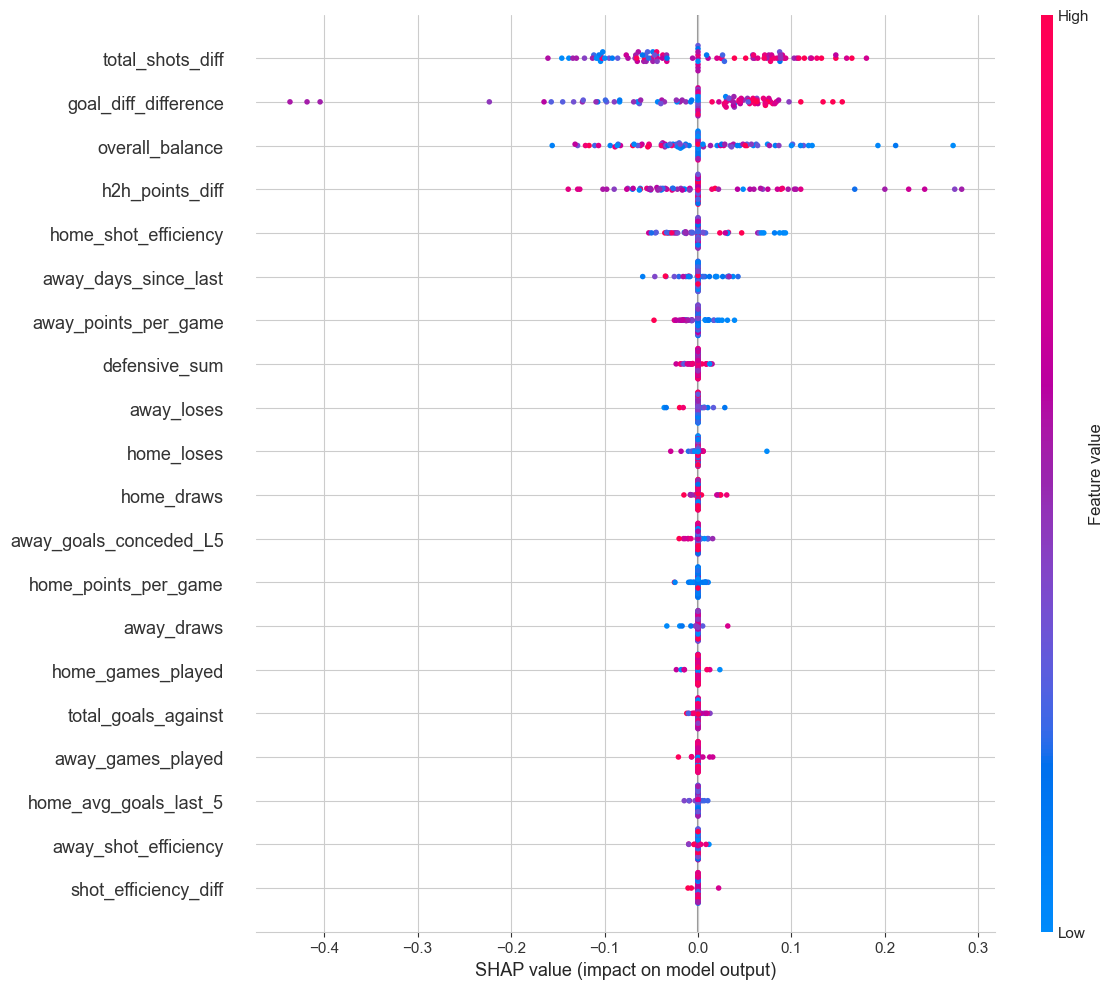

SHAP class Draw shape: (100, 20)
Correlation matrix shape for Draw: (20, 20)


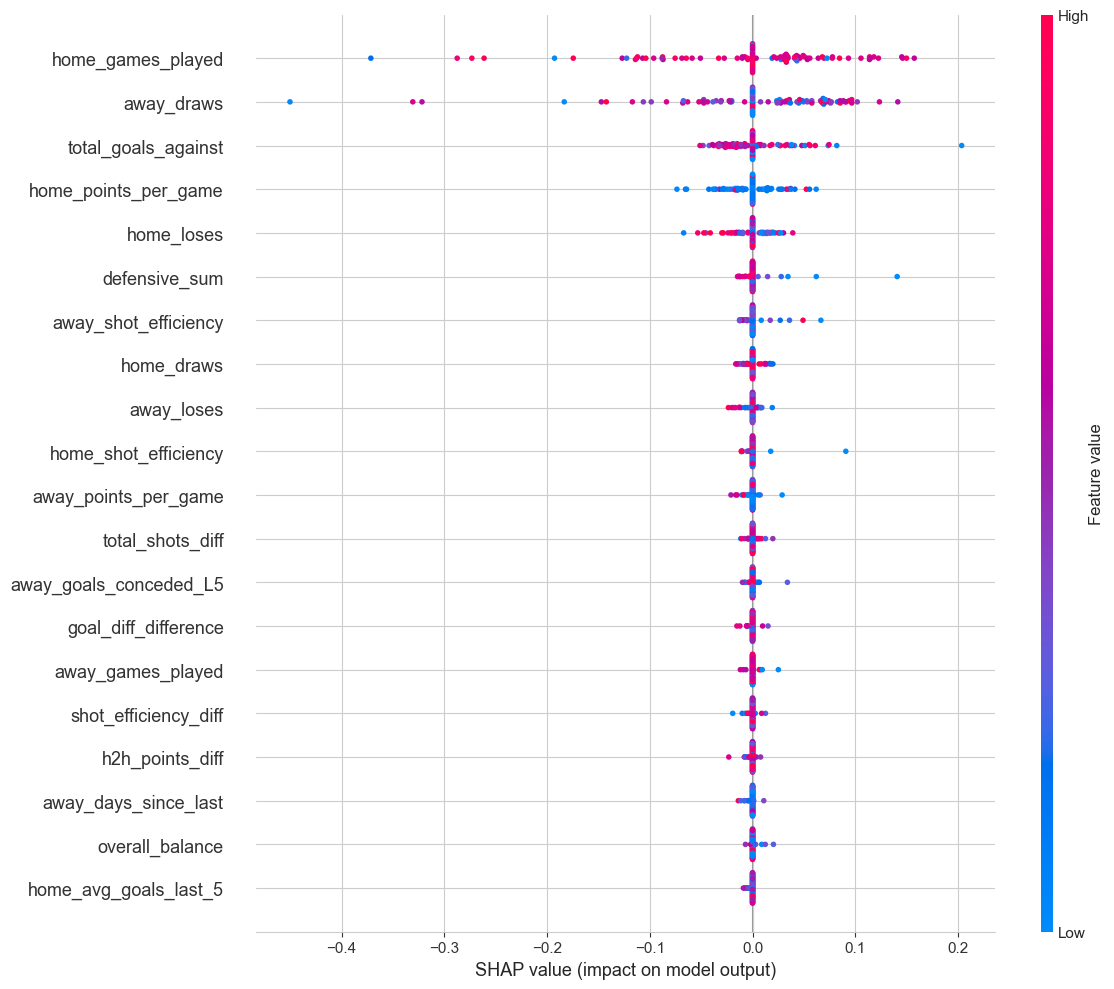

SHAP class Away Win shape: (100, 20)
Correlation matrix shape for Away Win: (20, 20)


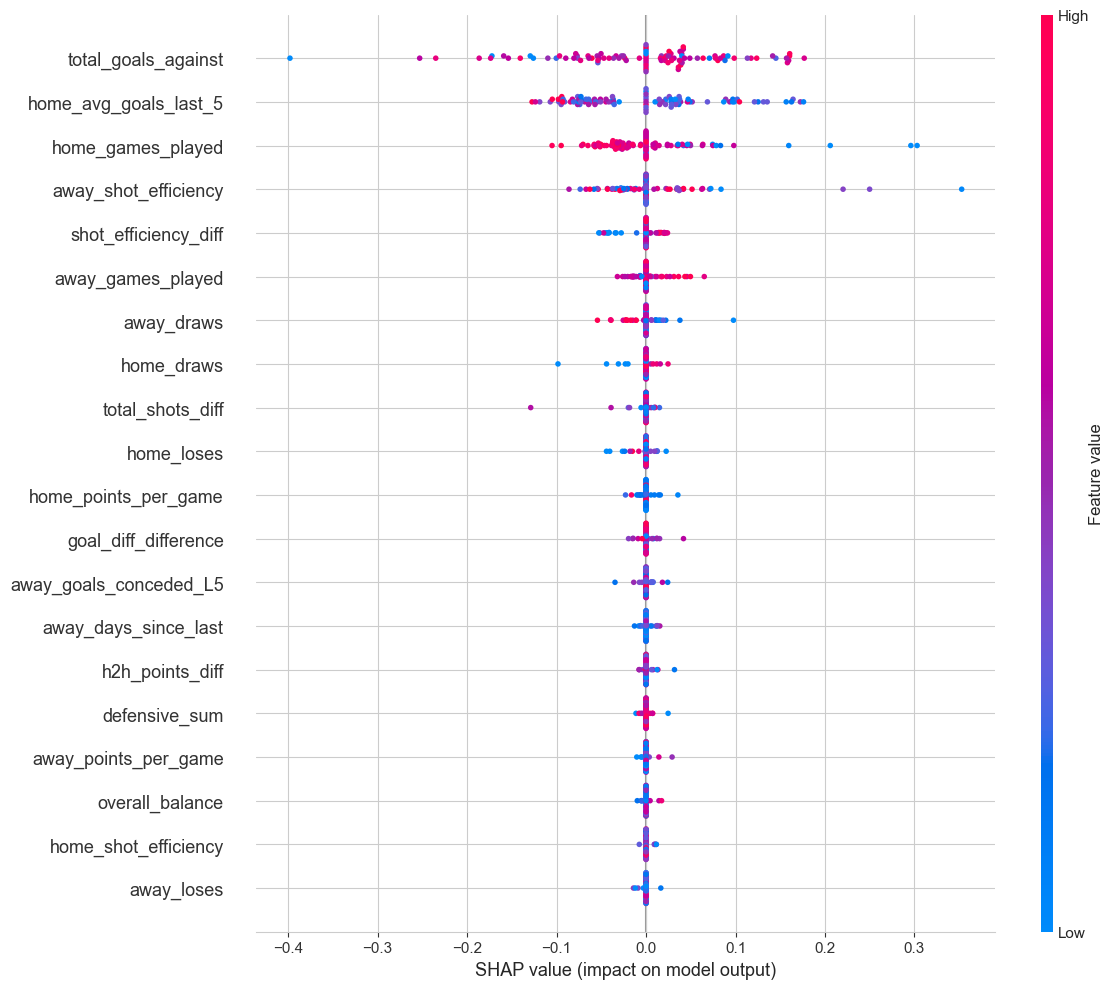

Clustered SHAP beeswarm plots saved


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
import shap

print("Generating SHAP Beeswarm Plot with Feature Clustering...")

# Compute mean absolute SHAP values for feature ranking
if isinstance(shap_values_tuned, list):
    overall_shap_importance = np.abs(np.array(shap_values_tuned)).mean(axis=(0, 1))
else:
    overall_shap_importance = np.abs(shap_values_tuned).mean(axis=(0, 2))

# Select top 20 features for clustering
top_n = 20
top_features_idx = overall_shap_importance.argsort()[-top_n:][::-1]
top_features = [feature_names[i] for i in top_features_idx]

# Validate input shapes
n_samples = X_sample.shape[0]
print(f"X_sample shape: {X_sample.shape}")
print(f"SHAP values shape: {np.array(shap_values_tuned).shape}")

# Plot beeswarm with original feature order (fallback if clustering fails)
ordered_features = top_features
ordered_shap_idx = top_features_idx

# Attempt clustering for each class separately
for class_idx, class_name in enumerate(class_names):
    # Extract SHAP values for the current class
    if isinstance(shap_values_tuned, list):
        shap_class = shap_values_tuned[class_idx][:, top_features_idx]
    else:
        shap_class = shap_values_tuned[:, top_features_idx, class_idx]
    
    print(f"SHAP class {class_name} shape: {shap_class.shape}")
    
    # Ensure SHAP class and X_sample have same number of rows
    if shap_class.shape[0] != n_samples:
        print(f"Warning: SHAP class {class_name} has {shap_class.shape[0]} rows, but X_sample has {n_samples} rows")
        min_samples = min(shap_class.shape[0], n_samples)
        shap_class = shap_class[:min_samples]
        X_subset = X_sample[:min_samples]
    else:
        X_subset = X_sample
    
    # Compute correlation matrix for clustering
    corr_matrix = np.corrcoef(shap_class.T)
    
    # Check for NaNs or invalid values
    if np.any(np.isnan(corr_matrix)) or np.any(np.isinf(corr_matrix)):
        print(f"Warning: Correlation matrix for {class_name} contains NaNs or Infs, replacing with zeros...")
        corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Verify correlation matrix shape
    print(f"Correlation matrix shape for {class_name}: {corr_matrix.shape}")
    if corr_matrix.shape[0] != top_n:
        print(f"Error: Correlation matrix size {corr_matrix.shape[0]} does not match number of features {top_n}")
        continue
    
    # Perform hierarchical clustering
    try:
        linkage = hierarchy.linkage(corr_matrix, method='average')
        dendro = hierarchy.dendrogram(linkage, no_plot=True)
        ordered_idx = dendro['leaves']
        # Validate indices
        if max(ordered_idx) >= top_n:
            print(f"Warning: Clustering indices for {class_name} exceed feature count {top_n}, using original order")
            ordered_idx = list(range(top_n))
        ordered_features = [top_features[i] for i in ordered_idx]
        ordered_shap_idx = [top_features_idx[i] for i in ordered_idx]
    except Exception as e:
        print(f"Error in clustering for {class_name}: {e}")
        print(f"Falling back to original feature order for {class_name}...")
        ordered_features = top_features
        ordered_shap_idx = top_features_idx
    
    # Plot beeswarm
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_class, X_subset[:, ordered_shap_idx], feature_names=ordered_features,
                     show=False, max_display=top_n, plot_type='dot',
                     plot_size=None, title=f'Clustered SHAP Beeswarm - {class_name}')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / f'shap_beeswarm_clustered_{class_name.lower().replace(" ", "_")}_xgboost.png',
                dpi=300, bbox_inches='tight')
    plt.show()

print("Clustered SHAP beeswarm plots saved")

Generating SHAP Partial Dependence Plots with Interaction Effects...
X_sample shape: (500, 106)
shap_values_tuned shape: (100, 106, 3)
SHAP class Home Win shape for feature goal_diff_difference: (100, 106)


<Figure size 1000x600 with 0 Axes>

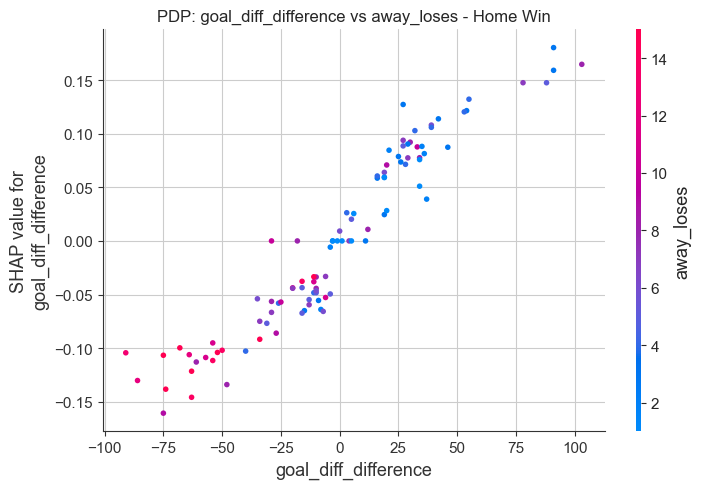

SHAP class Draw shape for feature goal_diff_difference: (100, 106)


<Figure size 1000x600 with 0 Axes>

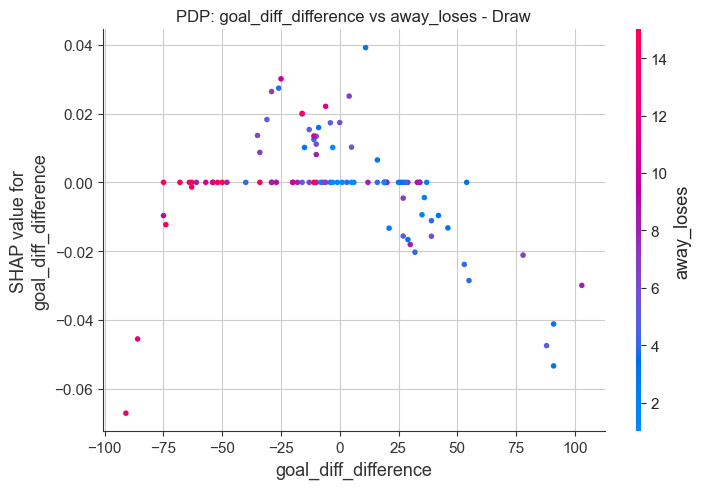

SHAP class Away Win shape for feature goal_diff_difference: (100, 106)


<Figure size 1000x600 with 0 Axes>

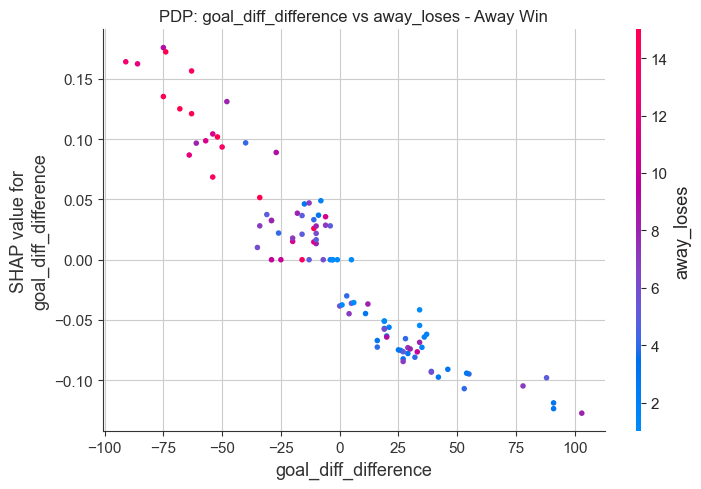

SHAP class Home Win shape for feature away_loses: (100, 106)


<Figure size 1000x600 with 0 Axes>

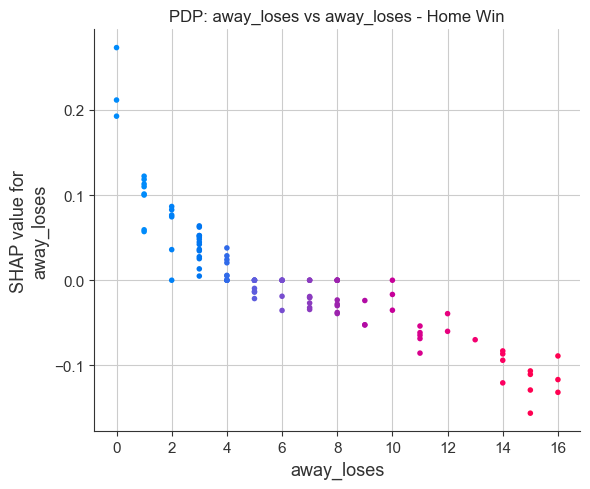

SHAP class Draw shape for feature away_loses: (100, 106)


<Figure size 1000x600 with 0 Axes>

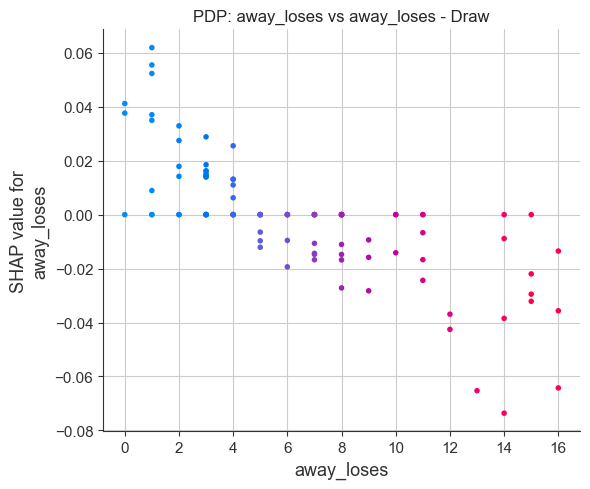

SHAP class Away Win shape for feature away_loses: (100, 106)


<Figure size 1000x600 with 0 Axes>

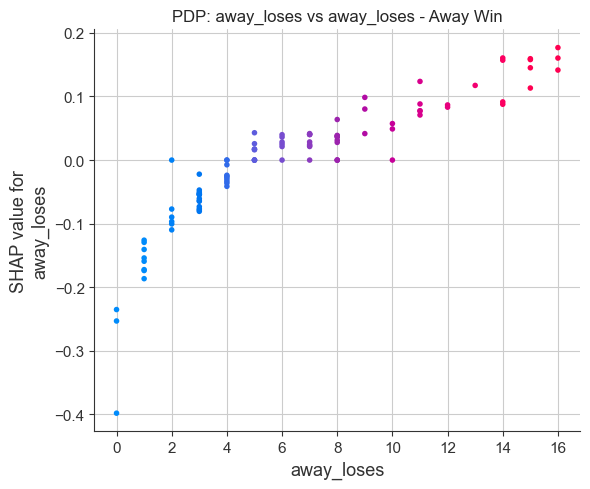

SHAP class Home Win shape for feature home_loses: (100, 106)


<Figure size 1000x600 with 0 Axes>

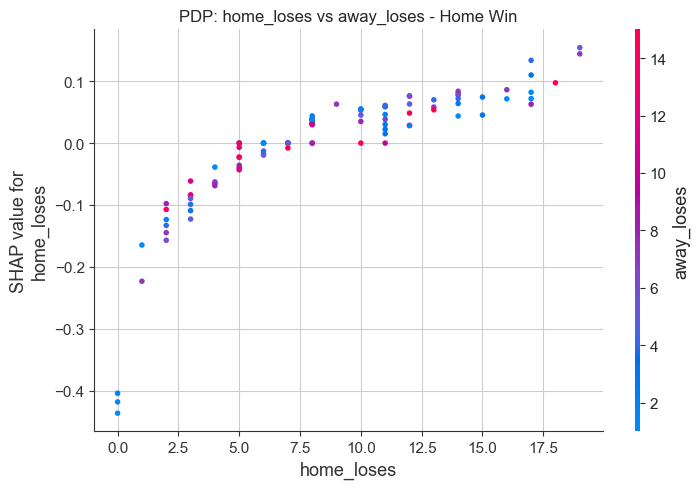

SHAP class Draw shape for feature home_loses: (100, 106)


<Figure size 1000x600 with 0 Axes>

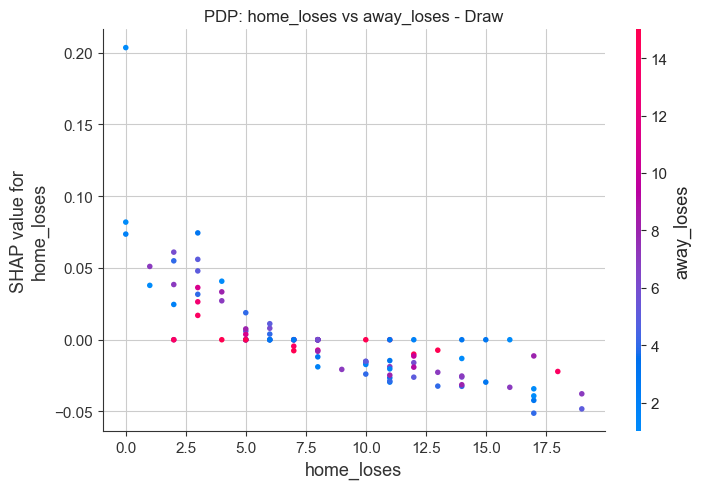

SHAP class Away Win shape for feature home_loses: (100, 106)


<Figure size 1000x600 with 0 Axes>

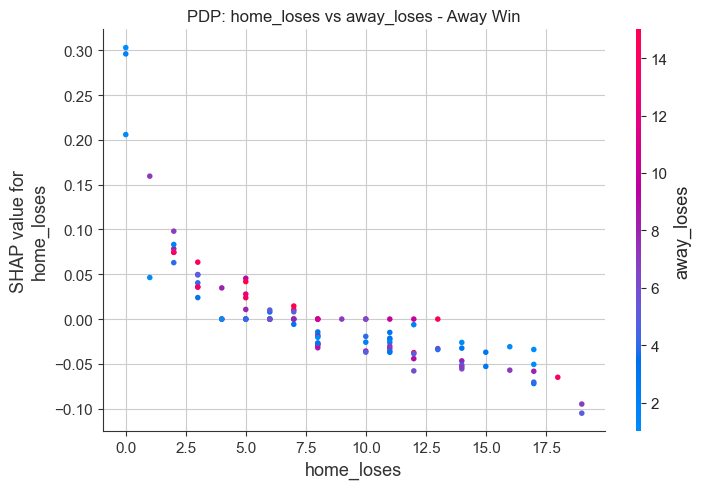

SHAP class Home Win shape for feature away_draws: (100, 106)


<Figure size 1000x600 with 0 Axes>

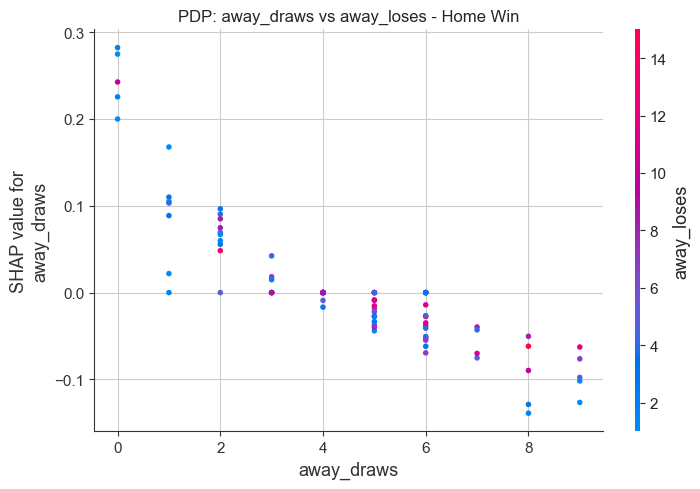

SHAP class Draw shape for feature away_draws: (100, 106)


<Figure size 1000x600 with 0 Axes>

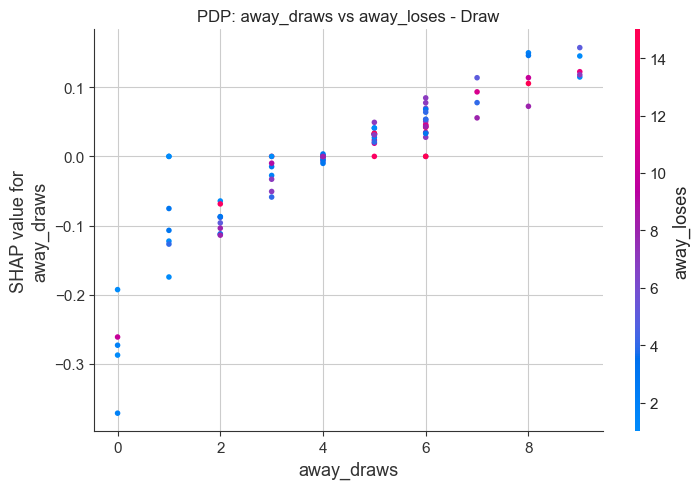

SHAP class Away Win shape for feature away_draws: (100, 106)


<Figure size 1000x600 with 0 Axes>

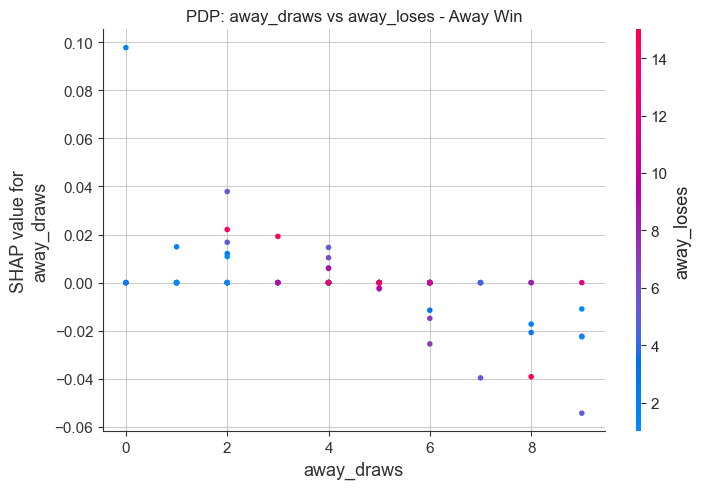

SHAP class Home Win shape for feature home_draws: (100, 106)


<Figure size 1000x600 with 0 Axes>

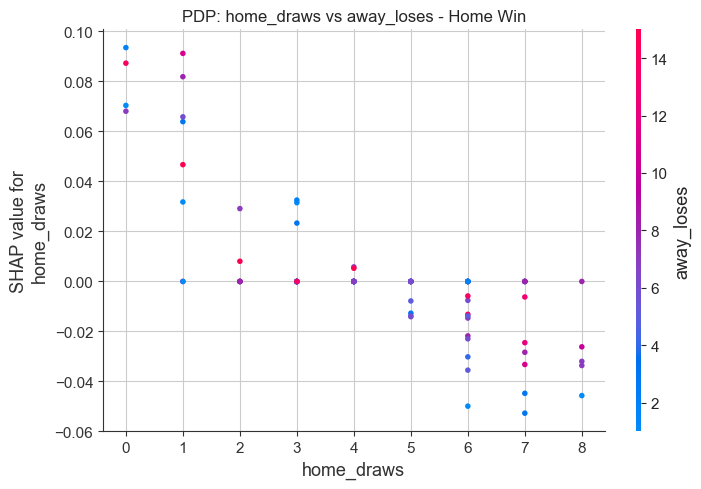

SHAP class Draw shape for feature home_draws: (100, 106)


<Figure size 1000x600 with 0 Axes>

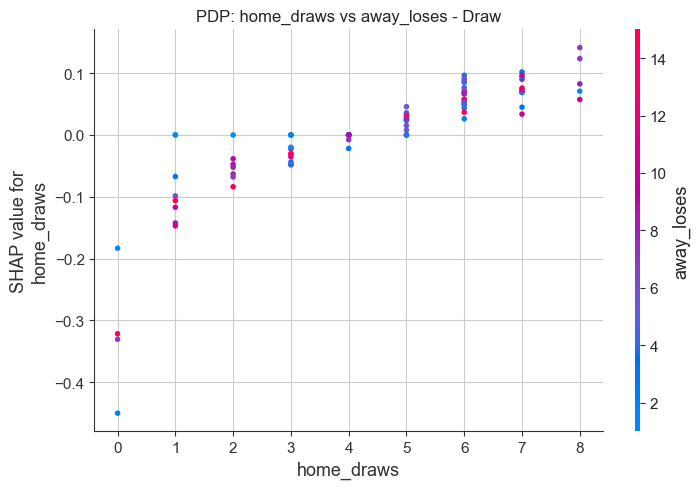

SHAP class Away Win shape for feature home_draws: (100, 106)


<Figure size 1000x600 with 0 Axes>

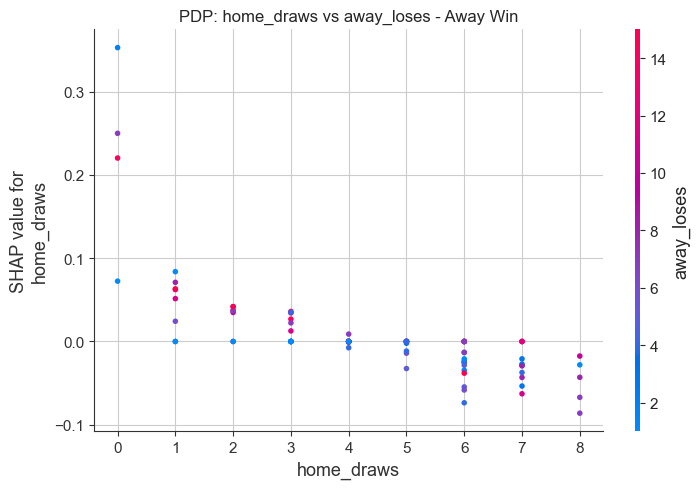

SHAP partial dependence plots saved


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import shap

print("Generating SHAP Partial Dependence Plots with Interaction Effects...")

# Compute mean absolute SHAP values for feature ranking
if isinstance(shap_values_tuned, list):
    overall_shap_importance = np.abs(np.array(shap_values_tuned)).mean(axis=(0, 1))
else:
    overall_shap_importance = np.abs(shap_values_tuned).mean(axis=(0, 2))

# Select top 5 features
top_5_idx = overall_shap_importance.argsort()[-5:][::-1]
top_5_features = [feature_names[i] for i in top_5_idx]
second_feature = top_5_features[1]  # For interaction

# Validate shapes
n_samples = X_sample.shape[0]
print(f"X_sample shape: {X_sample.shape}")
print(f"shap_values_tuned shape: {np.array(shap_values_tuned).shape}")

# Ensure SHAP values and X_sample have the same number of rows
if isinstance(shap_values_tuned, list):
    shap_samples = shap_values_tuned[0].shape[0]
else:
    shap_samples = shap_values_tuned.shape[0]

if shap_samples != n_samples:
    print(f"Warning: SHAP values have {shap_samples} rows, but X_sample has {n_samples} rows. Aligning to minimum...")
    min_samples = min(shap_samples, n_samples)
    X_subset = X_sample[:min_samples]
    if isinstance(shap_values_tuned, list):
        shap_values_tuned = [sv[:min_samples] for sv in shap_values_tuned]
    else:
        shap_values_tuned = shap_values_tuned[:min_samples]
else:
    X_subset = X_sample

for feature_idx, feature_name in zip(top_5_idx, top_5_features):
    for class_idx, class_name in enumerate(class_names):
        plt.figure(figsize=(10, 6))
        if isinstance(shap_values_tuned, list):
            shap_class = shap_values_tuned[class_idx]
        else:
            shap_class = shap_values_tuned[:, :, class_idx]
        
        print(f"SHAP class {class_name} shape for feature {feature_name}: {shap_class.shape}")
        
        # Plot dependence plot
        try:
            shap.dependence_plot(feature_idx, shap_class, X_subset, feature_names=feature_names,
                                interaction_index=feature_names.index(second_feature),
                                show=False)
            plt.title(f'PDP: {feature_name} vs {second_feature} - {class_name}')
            plt.tight_layout()
            plt.savefig(FIGURES_PATH / f'pdp_{feature_name.lower().replace(" ", "_")}_{class_name.lower().replace(" ", "_")}_xgboost.png',
                        dpi=300, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f"Error plotting PDP for {feature_name} - {class_name}: {e}")
            continue

print("SHAP partial dependence plots saved")

Generating SHAP Decision Plots for Key Predictions...
Decision plot for: Correct High Confidence


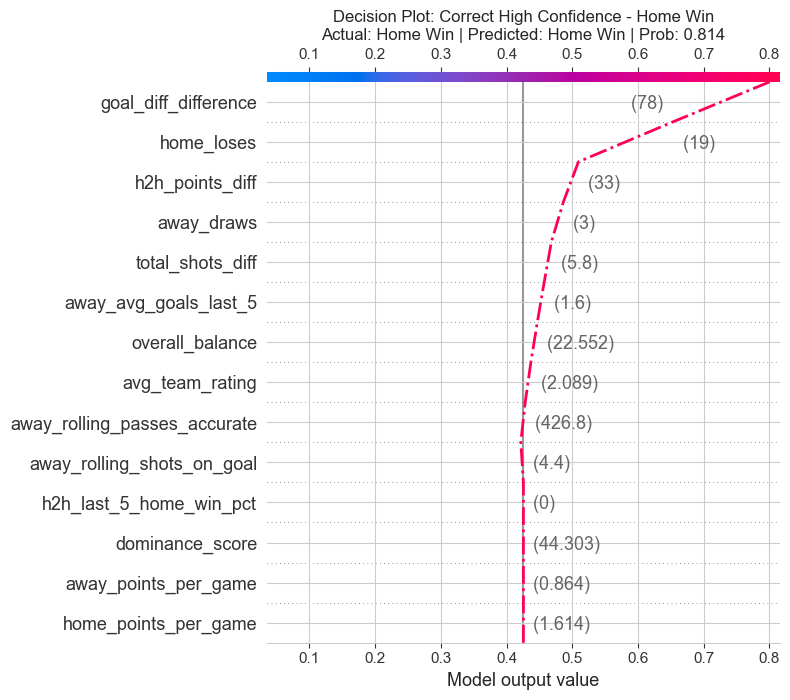

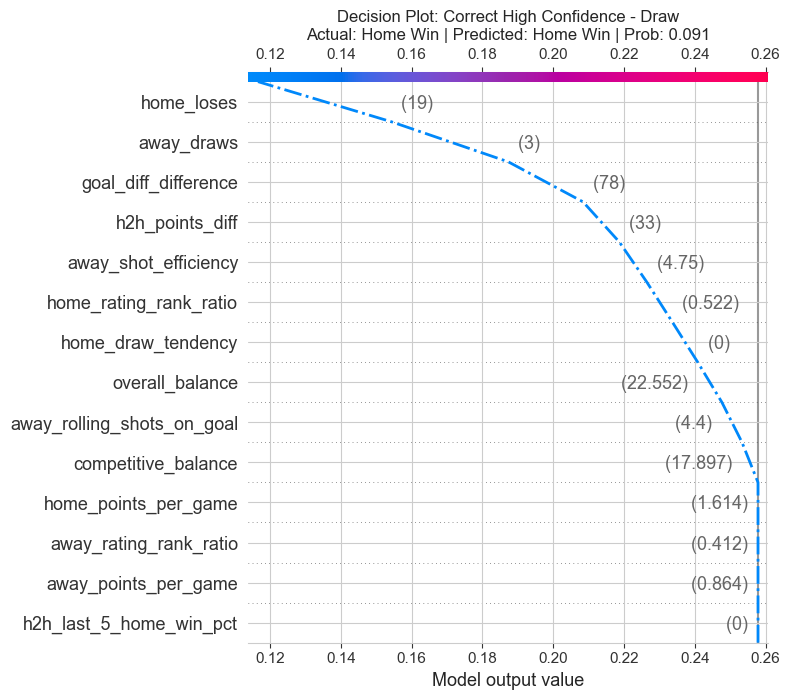

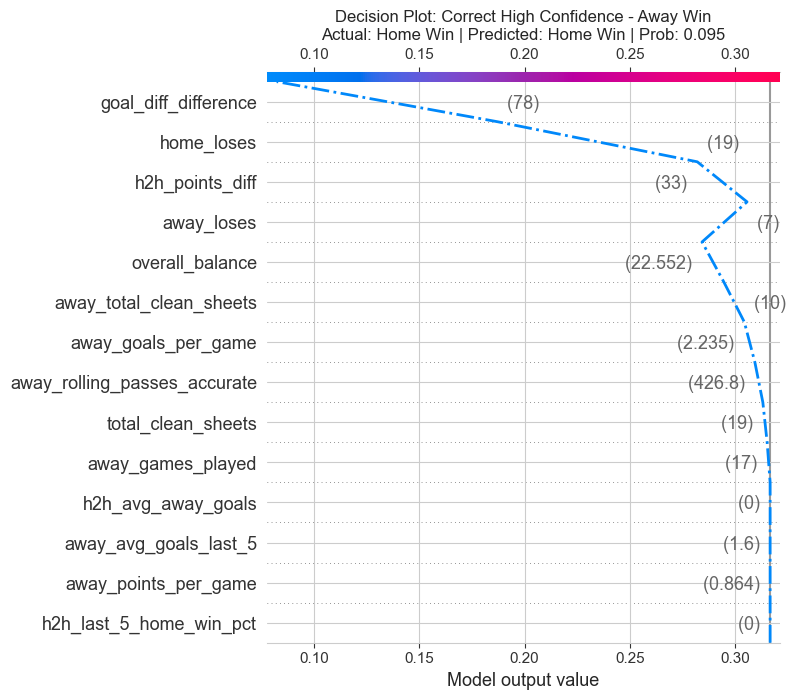

Decision plot for: Incorrect High Confidence


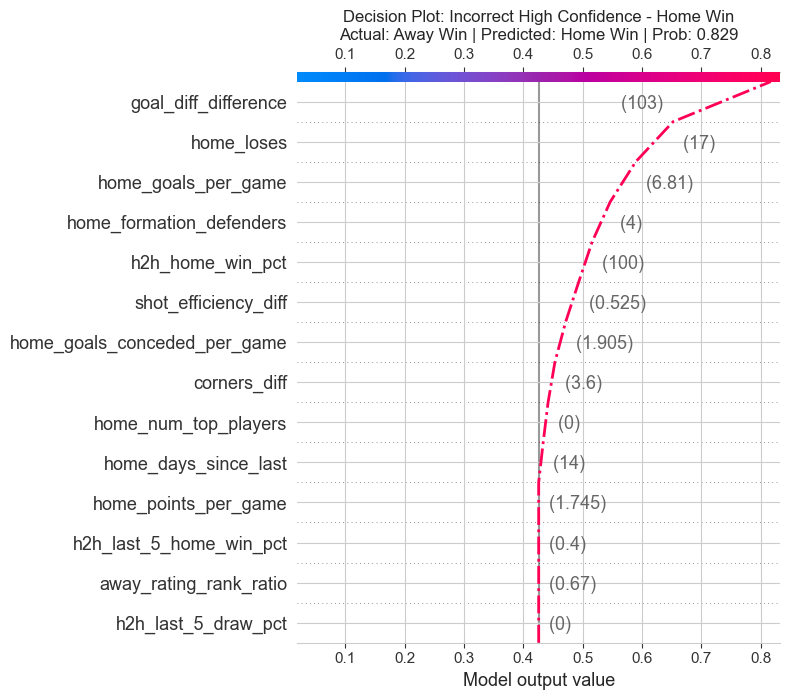

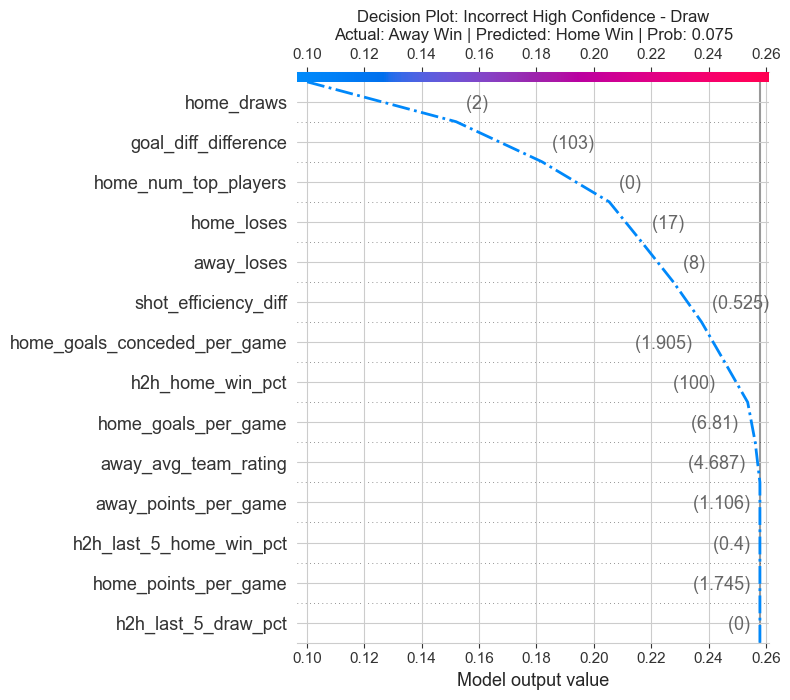

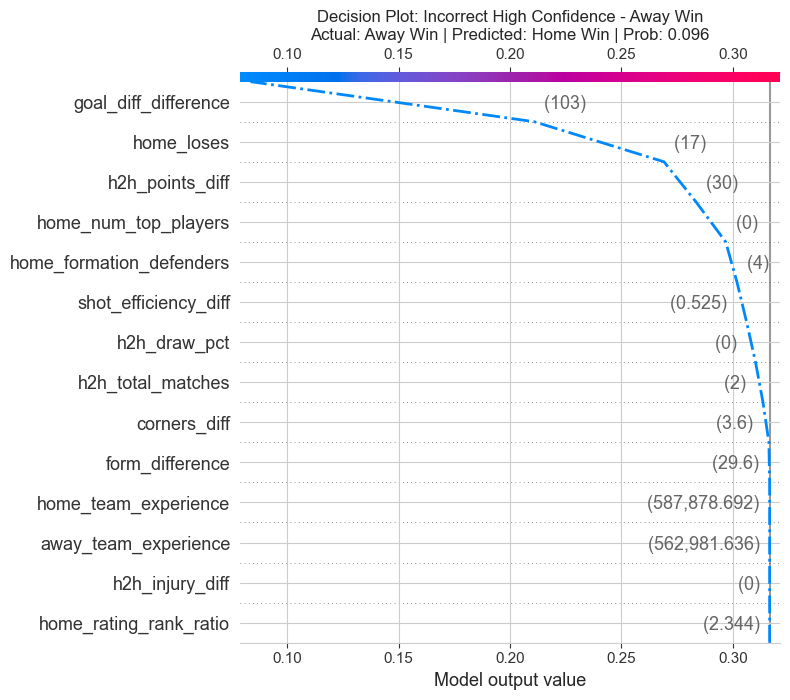

Decision plot for: Home Win Prediction


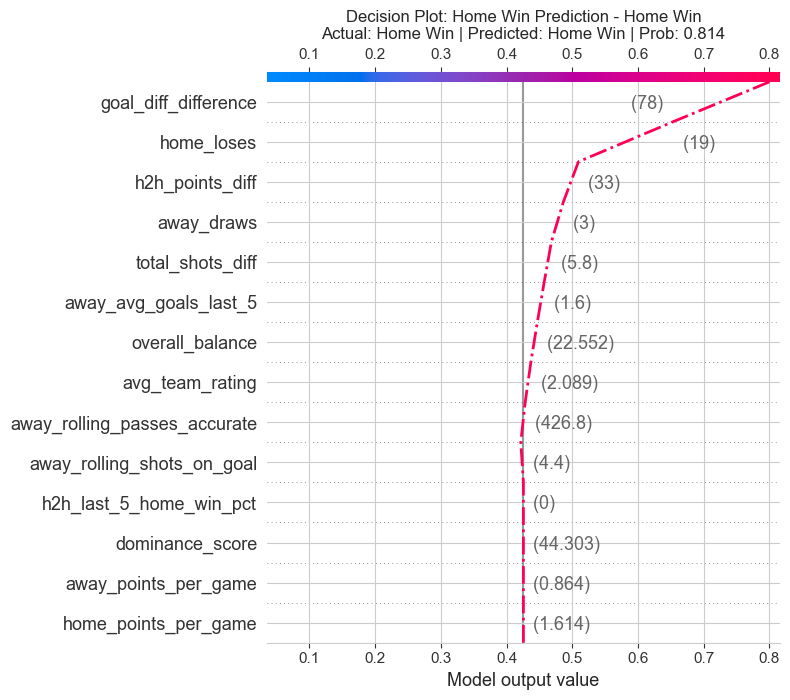

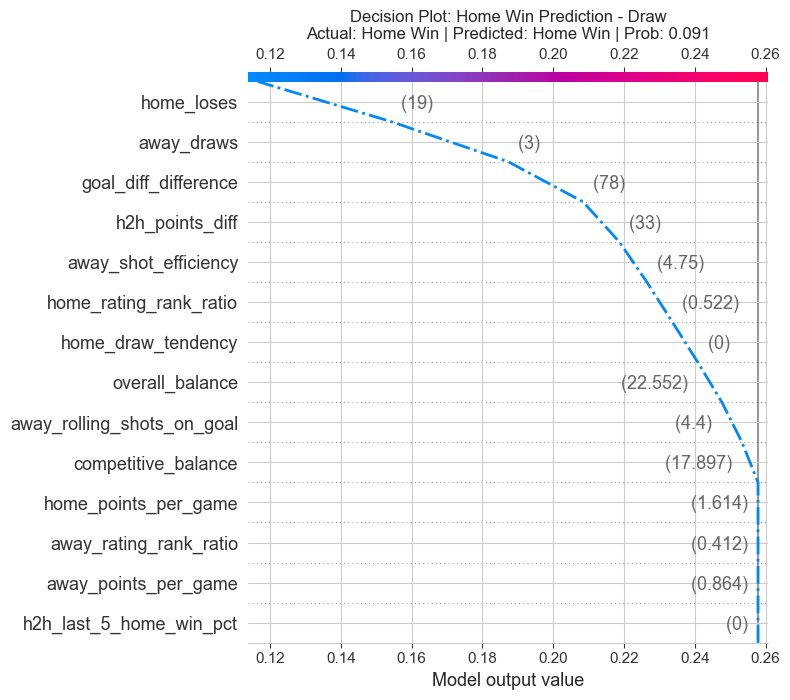

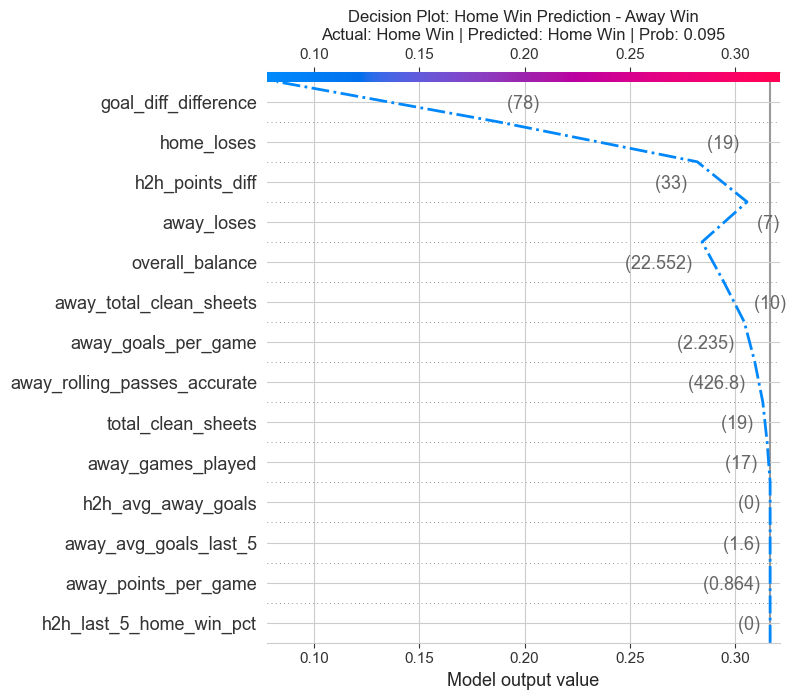

SHAP decision plots saved


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import shap

print("Generating SHAP Decision Plots for Key Predictions...")

for scenario_name, idx in selected_indices[:3]:
    actual = class_names[int(y_test.iloc[idx])]
    predicted = class_names[y_pred_test[idx]]
    probas = y_pred_proba_test[idx]
    
    print(f"Decision plot for: {scenario_name}")
    
    sample_idx = min(idx, len(X_sample) - 1)  # Ensure valid index
    
    for class_idx, class_name in enumerate(class_names):
        if isinstance(shap_values_tuned, list):
            shap_class = shap_values_tuned[class_idx][sample_idx]
            base_val = explainer_interaction.expected_value[class_idx]
        else:
            shap_class = shap_values_tuned[sample_idx, :, class_idx]
            base_val = explainer_interaction.expected_value[class_idx]
        
        plt.figure(figsize=(12, 8))
        shap.decision_plot(base_val, shap_class, X_sample[sample_idx], feature_names=feature_names,
                           show=False, highlight=0, feature_display_range=slice(None, -15, -1))
        plt.title(f'Decision Plot: {scenario_name} - {class_name}\nActual: {actual} | Predicted: {predicted} | Prob: {probas[class_idx]:.3f}')
        plt.tight_layout()
        plt.savefig(FIGURES_PATH / f'decision_plot_{scenario_name.lower().replace(" ", "_")}_{class_name.lower().replace(" ", "_")}_xgboost.png',
                    dpi=300, bbox_inches='tight')
        plt.show()

print("SHAP decision plots saved")